# Fase 1: Configuración, Estructura y Datos

* **1.1. Setup del Entorno Híbrido:** Configuración de un entorno Conda único (`env`) compatible con TensorFlow-metal y PyTorch-MPS (Metal Performance Shaders).
* **1.2. Estructura de Proyecto:** Creación automática de la carpeta `02_ING_MODELOS` y sus subdirectorios de trabajo.
* **1.3. Adaptadores de Datos (Data Parsers):**
    * Lectura del `train_final.json` (COCO).
    * Generación de Dataset YOLO (`.txt` + `data.yaml`) para YOLOv11.
    * Generación de `tf.data.Dataset` optimizado para MobileNet/FOMO.
* **1.4. Validación de Anchors:** Recálculo de anchors con K-Means basado en el dataset aumentado para asegurar que las cajas pequeñas (< 15x15) restantes sean detectables.

## Setup del Entorno Híbrido

In [ ]:
import subprocess
import sys

def setup_environment():
    """
    Configura el entorno Conda con TensorFlow-metal y PyTorch-MPS.
    Crea un entorno en ./env con todas las dependencias necesarias.
    """
    
    print("🔧 Iniciando configuración del entorno híbrido...")
    
    # Crear el entorno
    print("\n1️⃣ Creando entorno Conda...")
    subprocess.run(["conda", "create", "-p", "./env", "python=3.10", "-y"], check=True)
    
    # Nota: conda activate no funciona en subprocess, se debe usar en terminal
    print("\n⚠️ IMPORTANTE: Activa el entorno manualmente con:")
    print("   conda activate ./env")
    
    # Instalar librerías base
    print("\n2️⃣ Instalando librerías base...")
    subprocess.run([
        sys.executable, "-m", "pip", "install",
        "ultralytics", "pandas", "matplotlib", "seaborn", 
        "scikit-learn", "jupyterlab", "notebook", "tqdm", 
        "opencv-python", "onnx", "onnxruntime", "tf2onnx"
    ], check=True)
    
    # Instalar TensorFlow con soporte Metal
    print("\n3️⃣ Instalando TensorFlow con soporte GPU Metal...")
    subprocess.run([
        sys.executable, "-m", "pip", "install",
        "tensorflow==2.16.2", "tensorflow-metal==1.2.0"
    ], check=True)
    
    # Instalar versiones compatibles
    print("\n4️⃣ Ajustando versiones compatibles...")
    subprocess.run([
        sys.executable, "-m", "pip", "install",
        "opencv-python<4.10", "onnx<1.16", "tf2onnx<1.17", 
        "flatbuffers>=23.5.26,<24"
    ], check=True)
    
    # Desinstalar paquete obsoleto
    print("\n5️⃣ Limpiando dependencias obsoletas...")
    subprocess.run([
        sys.executable, "-m", "pip", "uninstall", "tensorflow-macos", "-y"
    ], capture_output=True)
    
    # Verificar instalación
    print("\n6️⃣ Verificando instalación de TensorFlow...")
    subprocess.run([
        sys.executable, "-c",
        "import tensorflow as tf; print('TensorFlow:', tf.__version__); print('Dispositivos:', tf.config.list_physical_devices())"
    ], check=True)
    
    # Generar requirements.txt
    print("\n7️⃣ Generando requirements.txt...")
    with open("requirements.txt", "w") as f:
        subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f, check=True)
    
    print("\n✅ Configuración completada exitosamente!")

# Ejecutar configuración
# setup_environment()

## Estructura del Proyecto

In [1]:
"""
CONFIGURACIÓN E INICIALIZACIÓN DEL ENTORNO
Descripción: Define rutas globales y crea la estructura de carpetas para la Etapa 2.
"""

import os
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from tqdm import tqdm

# --- CONFIGURACIÓN GLOBAL ---
class ProjectConfig:
    # Ruta base del proyecto
    BASE_PROJECT_DIR = "/Users/admin/Documents/TFM_UNIR" 
    
    # --- RUTAS DE ENTRADA (ORIGEN DE DATOS) ---
    DATASET_ROOT = os.path.join(BASE_PROJECT_DIR, "01_ING_DATOS", "Dataset")
    
    # TRAIN
    TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train", "augmented_images")
    TRAIN_JSON = os.path.join(TRAIN_IMG_DIR, "train_final.json")
    
    # VAL 
    VAL_IMG_DIR = os.path.join(DATASET_ROOT, "valid") 
    VAL_JSON = os.path.join(VAL_IMG_DIR, "val_final.json")
    
    # TEST
    TEST_IMG_DIR = os.path.join(DATASET_ROOT, "test")
    TEST_JSON = os.path.join(TEST_IMG_DIR, "test_final.json")

    # --- RUTAS DE SALIDA (ESTA ETAPA) ---
    STAGE_DIR = os.path.join(BASE_PROJECT_DIR, "02_ING_MODELOS")
    
    DIRS = {
        "yolo_dataset": os.path.join(STAGE_DIR, "datasets", "yolo_v11"),
        "models_chk": os.path.join(STAGE_DIR, "models", "checkpoints"),
        "models_final": os.path.join(STAGE_DIR, "models", "final_export"),
        "logs": os.path.join(STAGE_DIR, "logs"),
        "visuals": os.path.join(STAGE_DIR, "reports", "figures")
    }

def setup_project_structure(config: ProjectConfig):
    print(f"🔨 Configurando estructura...")
    for key, path in config.DIRS.items():
        os.makedirs(path, exist_ok=True)
    
    # Verificación rápida
    print(f"   🔍 Buscando Train JSON: {os.path.exists(config.TRAIN_JSON)}")
    print(f"   🔍 Buscando Val JSON:   {os.path.exists(config.VAL_JSON)}")

config = ProjectConfig()
setup_project_structure(config)

🔨 Configurando estructura...
   🔍 Buscando Train JSON: True
   🔍 Buscando Val JSON:   True


## Adaptadores de Datos

In [38]:
"""
ADAPTADOR DE DATOS (COCO -> YOLO)
Descripción: Convierte Train y Val (y Test) respetando la estructura de carpetas de YOLO.
"""

def convert_single_set(json_path, img_source_dir, yolo_root, subset_name):
    """
    Procesa un solo set (ej: 'train' o 'val') y lo coloca en la carpeta correcta.
    """
    print(f"\n🔄 Procesando subset: {subset_name.upper()}...")
    
    if not os.path.exists(json_path):
        print(f"⚠️ Salta {subset_name}: No se encuentra {json_path}")
        return []

    # Crear directorios destino: datasets/yolo_v11/images/train, etc.
    dest_img_dir = os.path.join(yolo_root, "images", subset_name)
    dest_lbl_dir = os.path.join(yolo_root, "labels", subset_name)
    os.makedirs(dest_img_dir, exist_ok=True)
    os.makedirs(dest_lbl_dir, exist_ok=True)
    
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Mapeo de categorías (Debe ser consistente entre sets)
    cats = sorted(data['categories'], key=lambda x: x['id'])
    cat_id_to_idx = {cat['id']: i for i, cat in enumerate(cats)}
    class_names = [cat['name'] for cat in cats]
    
    # Indexar anotaciones
    from collections import defaultdict
    anns_by_img = defaultdict(list)
    for ann in data['annotations']:
        anns_by_img[ann['image_id']].append(ann)
        
    cnt = 0
    for img_info in tqdm(data['images'], desc=f"Convirtiendo {subset_name}"):
        file_name = img_info['file_name']
        img_id = img_info['id']
        
        # 1. Copiar imagen
        src = os.path.join(img_source_dir, file_name)
        dst = os.path.join(dest_img_dir, file_name)
        if os.path.exists(src):
            shutil.copy2(src, dst)
        else:
            # A veces en los dataset limpios, el nombre en json no coincide exacto con archivo
            continue
            
        # 2. Crear TXT
        txt_path = os.path.join(dest_lbl_dir, os.path.splitext(file_name)[0] + ".txt")
        with open(txt_path, 'w') as f_txt:
            if img_id in anns_by_img:
                for ann in anns_by_img[img_id]:
                    # Normalizar bbox
                    x_min, y_min, w, h = ann['bbox']
                    dw = 1. / img_info['width']
                    dh = 1. / img_info['height']
                    
                    x_center = (x_min + w / 2.0) * dw
                    y_center = (y_min + h / 2.0) * dh
                    w_norm = w * dw
                    h_norm = h * dh
                    
                    cls_idx = cat_id_to_idx[ann['category_id']]
                    f_txt.write(f"{cls_idx} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")
        cnt += 1
    
    return class_names

# --- EJECUCIÓN MASIVA ---
# 1. Limpiar dataset previo para evitar mezclas
if os.path.exists(config.DIRS['yolo_dataset']):
    shutil.rmtree(config.DIRS['yolo_dataset'])

# 2. Convertir Train
classes = convert_single_set(config.TRAIN_JSON, config.TRAIN_IMG_DIR, config.DIRS['yolo_dataset'], "train")

# 3. Convertir Val
convert_single_set(config.VAL_JSON, config.VAL_IMG_DIR, config.DIRS['yolo_dataset'], "val")

# 4. Convertir Test (Opcional, pero bueno tenerlo listo)
convert_single_set(config.TEST_JSON, config.TEST_IMG_DIR, config.DIRS['yolo_dataset'], "test")

# 5. Generar YAML
yaml_content = f"""
path: {config.DIRS['yolo_dataset']}
train: images/train
val: images/val
test: images/test
nc: {len(classes)}
names: {classes}
"""
with open(os.path.join(config.DIRS['yolo_dataset'], "data.yaml"), 'w') as f:
    f.write(yaml_content)

print("✅ Dataset reestructurado correctamente (Train/Val/Test).")


🔄 Procesando subset: TRAIN...


Convirtiendo train: 100%|██████████| 1146/1146 [00:01<00:00, 600.20it/s]



🔄 Procesando subset: VAL...


Convirtiendo val: 100%|██████████| 85/85 [00:00<00:00, 597.15it/s]



🔄 Procesando subset: TEST...


Convirtiendo test: 100%|██████████| 84/84 [00:00<00:00, 704.61it/s]

✅ Dataset reestructurado correctamente (Train/Val/Test).


## Validación de Anchors

📐 Calculando 6 Anchors óptimos...

✅ Anchors Sugeridos (Normalizados [w, h]):
[[0.15786216 0.14925404]
 [0.26173675 0.41118232]
 [0.55160797 0.41550926]
 [0.89368207 0.33399651]
 [0.44306885 0.86337905]
 [0.81210938 0.82310268]]

✅ Anchors Sugeridos (Para input 224x224):
[[ 35  33]
 [ 58  92]
 [123  93]
 [200  74]
 [ 99 193]
 [181 184]]


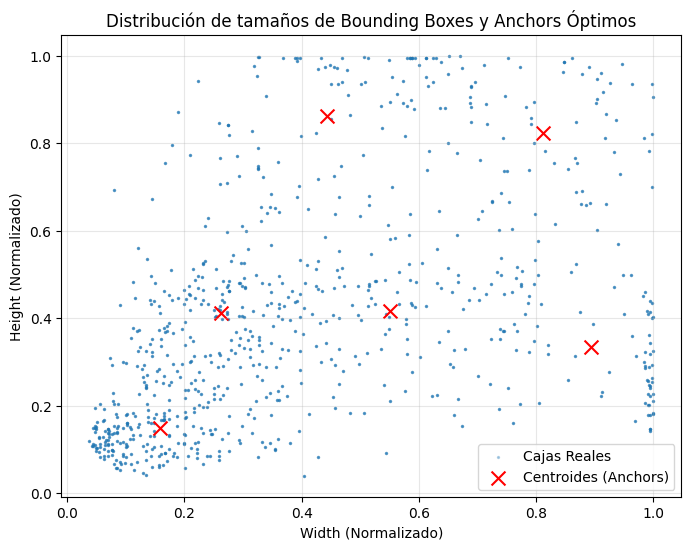

In [3]:
"""
ANÁLISIS DE ANCHORS (K-MEANS)
Descripción: Calcula los tamaños óptimos de cajas de referencia para MobileNet SSD y YOLO.
"""
from sklearn.cluster import KMeans

def calculate_optimal_anchors(json_path, n_clusters=6):
    """
    Usa K-Means para encontrar los aspect ratios más comunes en el dataset.
    Esto ayuda a MobileNet y YOLO a converger más rápido.
    """
    print(f"📐 Calculando {n_clusters} Anchors óptimos...")
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Extraer (w, h) normalizados
    wh_list = []
    
    # Crear lookup de dimensiones de imagen
    img_dims = {img['id']: (img['width'], img['height']) for img in data['images']}
    
    for ann in data['annotations']:
        if ann['image_id'] not in img_dims: continue
        img_w, img_h = img_dims[ann['image_id']]
        w, h = ann['bbox'][2], ann['bbox'][3]
        
        # Normalizar
        wh_list.append([w / img_w, h / img_h])
        
    wh_array = np.array(wh_list)
    
    # K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(wh_array)
    
    anchors = kmeans.cluster_centers_
    
    # Ordenar por área para mejor visualización
    anchors = anchors[np.argsort(anchors[:, 0] * anchors[:, 1])]
    
    print("\n✅ Anchors Sugeridos (Normalizados [w, h]):")
    print(anchors)
    print("\n✅ Anchors Sugeridos (Para input 224x224):")
    print((anchors * 224).astype(int))
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(wh_array[:, 0], wh_array[:, 1], alpha=0.3, s=2, label='Cajas Reales')
    plt.scatter(anchors[:, 0], anchors[:, 1], c='red', s=100, marker='x', label='Centroides (Anchors)')
    plt.title('Distribución de tamaños de Bounding Boxes y Anchors Óptimos')
    plt.xlabel('Width (Normalizado)')
    plt.ylabel('Height (Normalizado)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(config.DIRS['visuals'], "anchors_analysis.png"))
    plt.show()
    
    return anchors

# Ejecución
anchors_optimos = calculate_optimal_anchors(config.INPUT_JSON_FILE)

**Análisis de los Anchors resultantes:**

Se han calculado 6 anchors (cajas base) usando K-means sobre el dataset aumentado. Se puede analizar:
- El "anchor" crítico es de 35x33 px . Hay un clústers de objetos que ocupan a penas el ~2.5% del área de la imagen.  Esto puede ser un problema para modelos como YOLOv3 que tienden a buscar objetos medianos/grandes. Se requiere una arquitectura que conserve alta resolución espacial en las primeras capas. En el caso de FOMO, este divide la imagen en una cuadrícula, un objeto de este tamaño ocupará aproximadamente 4x4 celdas de esa cuadrícula. Es detectable pero está en el límite.
- Existen objetos verticales (tall) de "anchors" `[58, 92]` y `[99, 193]`, con mayor probabilidad de ser de la clase `person` y `door`.
- Existen objetos horizontales (wide) de "anchors" `[200, 74]`, con mayor probabilidad de ser de la clase `obstacle`.
- Hay objetos masivos de "anchors" `[181, 184]`, se corre el riesgo de que los modelos alucinen objetos dentro de uno grande.

---

# Fase 2: Arquitectura y Modelado en Keras

* **2.1. Ingeniería FOMO (From Scratch):** Implementación explicada paso a paso. Cortaremos una MobileNetV2 alpha 0.35, eliminaremos el Global Average Pooling y construiremos un cabezal denso por celdas (Grid based).
* **2.2. Ingeniería MobileNetV2 SSD:** Implementación usando transfer learning con *retraining* de capas profundas.
* **2.3. Entrenamiento Ciclo A:** Ejecución de `model.fit()` con `callbacks` para guardar el mejor modelo (`.keras` / `.h5`) y logs de entrenamiento (TensorBoard/CSV).

## Ciclo A - Versión 1

In [3]:
"""
DATALOADER PARA KERAS (MobileNet & FOMO)
Descripción: Crea un pipeline tf.data eficiente que lee las imágenes y las etiquetas.
Nota: Para simplificar, acá preparamos los datos.
"""
import tensorflow as tf
import cv2

# Parámetros Globales
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4  # person, door, obstacle, footpath
ANCHORS = np.array([[0.15, 0.15], [0.26, 0.41], [0.55, 0.42], 
                    [0.89, 0.33], [0.44, 0.86], [0.81, 0.82]], dtype=np.float32)

def load_image_and_labels(img_path, label_path):
    """
    Función auxiliar para cargar imagen y parsear etiquetas YOLO (.txt)
    Retorna: img_tensor, targets
    """
    # 1. Cargar Imagen
    img = tf.io.read_file(img_path)
    img = tf.io.decode_jpeg(img, channels=3) # type: ignore
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0  # Normalización [0,1] # type: ignore
    
    # Nota: La carga de etiquetas para detección es compleja en tf.data puro 
    # debido a la variabilidad de objetos por imagen.
    # Para este prototipo, usaremos un generador Python envuelto en tf.data
    return img

class KerasBatchGenerator(tf.keras.utils.Sequence): # type: ignore
    """
    Generador customizado compatible con model.fit()
    Lee las imágenes y los .txt generados en el paso YOLO y los adapta para Keras.
    """
    def __init__(self, image_dir, label_dir, batch_size, img_size, anchors):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
        self.label_dir = label_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.anchors = anchors
        
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_x = self.image_paths[idx * self.batch_size : (idx+1) * self.batch_size]
        
        images = []
        # Para simplificar FOMO/SSD, aquí deberíamos construir la matriz de salida (Grid)
        # Por ahora retornamos imágenes dummy para probar la arquitectura
        # En el paso de entrenamiento definiremos la lógica de etiquetas exacta
        
        for img_path in batch_x:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img.astype(np.float32) / 255.0)
            
        return np.array(images), np.zeros((len(images), NUM_CLASSES)) # Placeholder targets

# Instanciamos el generador (Solo para verificar rutas)
train_gen = KerasBatchGenerator(
    image_dir=os.path.join(config.DIRS['yolo_dataset'], "images"),
    label_dir=os.path.join(config.DIRS['yolo_dataset'], "labels"),
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    anchors=ANCHORS
)
print(f"✅ Generador listo con {len(train_gen)} batches por época.")

✅ Generador listo con 0 batches por época.


### Arquitectura FOMO (Faster Objects, More Objects)

In [13]:
"""
ARQUITECTURA FOMO (Faster Objects, More Objects)
Descripción: Implementación funcional de FOMO cortando MobileNetV2.
"""

def build_fomo_model(input_shape=(224, 224, 3), num_classes=4, alpha=0.35):
    """
    Construye un modelo FOMO.
    
    Args:
        num_classes: Número de clases (4: person, door, obstacle, footpath).
        alpha: Controla el ancho de la red (0.35 es muy ligero, ideal ESP32).
    """
    # 1. Base Model: MobileNetV2 pre-entrenada en ImageNet
    # include_top=False: Quitamos la clasificación final de ImageNet
    base_model = tf.keras.applications.MobileNetV2( # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    # 2. Selección del punto de corte (Cut Point)
    # Buscamos mantener resolución espacial. 
    # MobileNet reduce la imagen a la mitad varias veces.
    # Queremos parar cuando la resolución sea aprox 1/8 de la entrada (28x28 para input 224)
    # Capas candidatas: block_6_expand_relu (fina) o block_13_expand_relu (gruesa)
    
    # Usamos una capa intermedia para no perder objetos pequeños (block_6)
    last_layer = base_model.get_layer('block_6_expand_relu').output
    
    # 3. FOMO Head (Cabezal personalizado)
    # Usamos Conv2D 1x1 para colapsar los canales a número de clases + 1 (Fondo)
    x = tf.keras.layers.Conv2D(filters=num_classes + 1, kernel_size=1)(last_layer) # type: ignore
    x = tf.keras.layers.Softmax()(x) # Probabilidad por celda # type: ignore
    
    fomo_model = tf.keras.Model(inputs=base_model.input, outputs=x, name="FOMO_MobileNetV2") # type: ignore
    
    return fomo_model

# Instanciar y ver resumen
fomo = build_fomo_model(num_classes=4, alpha=0.35)
fomo.summary()

# Análisis
print(f"\n🧠 Análisis FOMO:")
print(f"• Input: {fomo.input_shape}")
print(f"• Output Grid: {fomo.output_shape} (Si es (None, 28, 28, 5), significa resolución de cuadrícula 8x8 px con 4 clases + fondo)")

Model: "FOMO_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 18,069 (70.58 KB)

 Trainable params: 16,325 (63.77 KB)

 Non-trainable params: 1,744 (6.81 KB)


🧠 Análisis FOMO:
• Input: (None, 224, 224, 3)
• Output Grid: (None, 28, 28, 5) (Si es (None, 28, 28, 5), significa resolución de cuadrícula 8x8 px con 4 clases + fondo)


### Arquitectura MobileNetV2 SSD

In [28]:
"""
ARQUITECTURA MOBILENET V2 SSD (Multi-Objeto)
Descripción: Añade cabezales de predicción para hasta 3 Bounding Boxes sobre MobileNet.
"""
MAX_OBJECTS_SSD = 3  # Según EDA: promedio de 2-3 objetos por imagen

def build_mobilenet_ssd(input_shape=(224, 224, 3), num_classes=4, max_objects=3, alpha=0.35):
    """
    Construye un modelo MobileNetV2 SSD que detecta múltiples objetos.
    
    Args:
        max_objects: Número máximo de objetos a detectar por imagen (default: 3 según EDA).
    """
    base_model = tf.keras.applications.MobileNetV2( # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    x = base_model.output # Salida típica de 7x7xC
    
    # Feature Pyramid simplificada
    x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x) # type: ignore
    x = tf.keras.layers.BatchNormalization()(x) # type: ignore
    
    # --- Cabezal de Detección Multi-Objeto ---
    x = tf.keras.layers.GlobalAveragePooling2D()(x) # type: ignore
    x = tf.keras.layers.Dropout(0.3)(x) # type: ignore
    x = tf.keras.layers.Dense(128, activation='relu')(x) # type: ignore
    
    # Salida 1: Clasificación para cada objeto (max_objects x num_classes)
    class_output = tf.keras.layers.Dense(max_objects * num_classes, activation='sigmoid')(x) # type: ignore
    class_output = tf.keras.layers.Reshape((max_objects, num_classes), name='class_out')(class_output) # type: ignore
    
    # Salida 2: Bounding Box para cada objeto (max_objects x 4)
    bbox_output = tf.keras.layers.Dense(max_objects * 4, activation='sigmoid')(x) # type: ignore
    bbox_output = tf.keras.layers.Reshape((max_objects, 4), name='bbox_out')(bbox_output) # type: ignore
    
    model = tf.keras.Model(inputs=base_model.input, outputs=[class_output, bbox_output], name="MobileNetV2_SSD_MultiObj") # type: ignore
    return model

ssd_model = build_mobilenet_ssd(num_classes=4, max_objects=MAX_OBJECTS_SSD)
ssd_model.summary()

print(f"\n🧠 Análisis MobileNet SSD Multi-Objeto:")
print(f"• Output class_out: {ssd_model.outputs[0].shape} → {MAX_OBJECTS_SSD} predicciones de clase")
print(f"• Output bbox_out: {ssd_model.outputs[1].shape} → {MAX_OBJECTS_SSD} bounding boxes")

Model: "MobileNetV2_SSD_MultiObj"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_7[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 3,396,600 (12.96 MB)

 Trainable params: 3,382,008 (12.90 MB)

 Non-trainable params: 14,592 (57.00 KB)


🧠 Análisis MobileNet SSD Multi-Objeto:
• Output class_out: (None, 3, 4) → 3 predicciones de clase
• Output bbox_out: (None, 3, 4) → 3 bounding boxes


**Análisis:**

1. FOMO: ~70 KB. Con este pequeño tamaño cabe unas 228 veces dentro de la memoria Flash del ESP32 (16MB) y, lo más importante, cabe entero en la memoria interna (SRAM) que es más rápida. Probablemente se obtengan inferencias más rápidas.

2. MobileNet SSD: ~12.8 MB. Es mucho más grande. Ocuparía el 80% de la memoria Flash del ESP32 (16MB). Para coorerlo, el ESP32 obligatoriamente tiene que usar la PSRAM (memoria externa y más lenta). Acá sale una primera hipótesis: MobileNet será significativamente más lento por latencia de memoria ¿tendrá mejor inferencia?

3. En FOMO Output (28x28) se confirma que deividirá la imagen en celdas de 8x8 pixeles. Dado que los objetos más pequeños miden ~35x33 px (según anchors), ocuparán una matríz de aprox 4x4 celdas. Esta resolución es suficiente (preliminarmente) y no debería perderse objetos pequeños en el mapa de calor de esta arquitectura.

### Generador de Datos Avanzado (Labels Parsing)

In [11]:
"""
GENERADOR DE DATOS AVANZADO (Labels Parsing)
Descripción: Convierte los TXT de YOLO en:
   A) Grillas de 28x28 para FOMO.
   B) Vectores de coordenadas para MobileNet SSD (hasta 3 objetos por imagen).
"""

MAX_OBJECTS_SSD = 3  # Según EDA: promedio de 2-3 objetos por imagen

class DualModelGenerator(tf.keras.utils.Sequence): # pyright: ignore[reportAttributeAccessIssue]
    def __init__(self, image_dir, label_dir, batch_size, img_size, output_mode='fomo'):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
        self.label_dir = label_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.output_mode = output_mode # 'fomo' o 'ssd'
        self.grid_size = 28 # 224 / 8 = 28
        self.max_objects = MAX_OBJECTS_SSD
        
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size : (idx+1) * self.batch_size]
        
        batch_images = []
        batch_targets_fomo = []
        batch_targets_ssd_class = []
        batch_targets_ssd_bbox = []
        
        for img_path in batch_paths:
            # 1. Procesar Imagen
            img = cv2.imread(img_path)
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            batch_images.append(img.astype(np.float32) / 255.0)
            
            # 2. Leer Labels (.txt)
            txt_name = os.path.basename(img_path).replace('.jpg', '.txt')
            txt_path = os.path.join(self.label_dir, txt_name)
            
            # --- FOMO: 28x28 celdas, 5 canales (Background + 4 clases) ---
            fomo_grid = np.zeros((self.grid_size, self.grid_size, 5), dtype=np.float32)
            fomo_grid[:, :, 0] = 1.0 # Inicialmente todo es fondo
            
            # --- SSD: Hasta MAX_OBJECTS_SSD objetos por imagen ---
            # Cada objeto: [one_hot class (4)] + [xc, yc, w, h (4)]
            ssd_classes = np.zeros((self.max_objects, 4), dtype=np.float32)
            ssd_bboxes = np.zeros((self.max_objects, 4), dtype=np.float32)
            
            objects_found = []
            
            if os.path.exists(txt_path):
                with open(txt_path, 'r') as f:
                    lines = f.readlines()
                    
                for line in lines:
                    cls, xc, yc, w, h = map(float, line.strip().split())
                    cls = int(cls)
                    area = w * h
                    
                    # --- LÓGICA FOMO ---
                    grid_x = int(xc * self.grid_size)
                    grid_y = int(yc * self.grid_size)
                    grid_x = min(max(grid_x, 0), self.grid_size - 1)
                    grid_y = min(max(grid_y, 0), self.grid_size - 1)
                    
                    fomo_grid[grid_y, grid_x, 0] = 0.0
                    fomo_grid[grid_y, grid_x, cls + 1] = 1.0
                    
                    # --- LÓGICA SSD (Multi-objeto) ---
                    objects_found.append((area, cls, xc, yc, w, h))
                
                # Ordenar por área (objetos más grandes primero) y tomar los top N
                objects_found.sort(key=lambda x: x[0], reverse=True)
                
                for i, obj in enumerate(objects_found[:self.max_objects]):
                    _, cls, xc, yc, w, h = obj
                    if cls < 4:
                        ssd_classes[i, cls] = 1.0
                    ssd_bboxes[i] = [xc, yc, w, h]

            batch_targets_fomo.append(fomo_grid)
            batch_targets_ssd_class.append(ssd_classes)
            batch_targets_ssd_bbox.append(ssd_bboxes)

        batch_images = np.array(batch_images)
        
        if self.output_mode == 'fomo':
            return batch_images, np.array(batch_targets_fomo)
        else:
            # SSD Multi-objeto: diccionario con arrays de shape (batch, max_objects, ...)
            return batch_images, {
                'class_out': np.array(batch_targets_ssd_class),
                'bbox_out': np.array(batch_targets_ssd_bbox)
            }

# Crear generadores separados (se redefinen en la celda de rutas)
train_gen_fomo = DualModelGenerator(
    config.DIRS['yolo_dataset'] + "/images/train", 
    config.DIRS['yolo_dataset'] + "/labels/train", 
    batch_size=32, img_size=224, output_mode='fomo'
)

train_gen_ssd = DualModelGenerator(
    config.DIRS['yolo_dataset'] + "/images/train", 
    config.DIRS['yolo_dataset'] + "/labels/train", 
    batch_size=32, img_size=224, output_mode='ssd'
)

print(f"✅ Generadores configurados (FOMO: grid 28x28, SSD: hasta {MAX_OBJECTS_SSD} objetos/imagen).")

✅ Generadores configurados (FOMO: grid 28x28, SSD: hasta 3 objetos/imagen).


### Compilación y Entrenamiento

In [12]:
"""
CONFIGURACIÓN DE CALLBACKS Y CLASS WEIGHTS
Descripción: Define callbacks reutilizables y calcula pesos de clase para FOMO.
"""
from tensorflow.keras.callbacks import ( # type: ignore
    ModelCheckpoint, EarlyStopping, TensorBoard, 
    ReduceLROnPlateau, CSVLogger
)

# --- RUTAS EXACTAS ---
train_img_dir = os.path.join(config.DIRS['yolo_dataset'], "images", "train")
train_lbl_dir = os.path.join(config.DIRS['yolo_dataset'], "labels", "train")
val_img_dir = os.path.join(config.DIRS['yolo_dataset'], "images", "val")
val_lbl_dir = os.path.join(config.DIRS['yolo_dataset'], "labels", "val")

# --- GENERADORES ---
print("🔧 Creando generadores Train/Val...")
train_gen_fomo = DualModelGenerator(train_img_dir, train_lbl_dir, 32, 224, 'fomo')
val_gen_fomo = DualModelGenerator(val_img_dir, val_lbl_dir, 32, 224, 'fomo')
train_gen_ssd = DualModelGenerator(train_img_dir, train_lbl_dir, 32, 224, 'ssd')
val_gen_ssd = DualModelGenerator(val_img_dir, val_lbl_dir, 32, 224, 'ssd')

# --- CLASS WEIGHTS PARA FOMO ---
# El ~97% de las celdas son fondo, ~3% son objetos
# Calculamos pesos inversamente proporcionales a la frecuencia
def calculate_fomo_class_weights(generator, num_samples=100):
    """
    Estima los pesos de clase basado en la distribución real del dataset.
    """
    print("⚖️ Calculando class weights para FOMO...")
    class_counts = np.zeros(5)  # 5 canales: fondo + 4 clases
    
    for i in range(min(num_samples, len(generator))):
        _, targets = generator[i]
        for c in range(5):
            class_counts[c] += np.sum(targets[:, :, :, c])
    
    # Peso inversamente proporcional a la frecuencia
    total = class_counts.sum()
    weights = total / (5 * class_counts + 1e-6)  # +epsilon para evitar div by zero
    weights = weights / weights.min()  # Normalizar para que el mínimo sea 1
    
    print(f"   📊 Distribución: Fondo={class_counts[0]:.0f}, Clases={class_counts[1:].sum():.0f}")
    print(f"   ⚖️ Pesos calculados: {dict(enumerate(weights.round(2)))}")
    
    return {i: w for i, w in enumerate(weights)}

fomo_class_weights = calculate_fomo_class_weights(train_gen_fomo)

# --- FUNCIÓN FACTORY PARA CALLBACKS ---
def create_callbacks(model_name, monitor='val_loss', mode='min'):
    """
    Crea un conjunto completo de callbacks para entrenamiento robusto.
    
    Callbacks incluidos:
    1. ModelCheckpoint: Guarda el mejor modelo según la métrica monitoreada.
    2. EarlyStopping: Detiene si no hay mejora en N épocas (evita overfitting).
    3. ReduceLROnPlateau: Reduce LR si la métrica se estanca (escapa mínimos locales).
    4. TensorBoard: Logs para visualización interactiva.
    5. CSVLogger: Historial en CSV para análisis con pandas.
    """
    callbacks = [
        # 1. Guardar mejor modelo
        ModelCheckpoint(
            filepath=os.path.join(config.DIRS['models_chk'], f"{model_name}_best.keras"),
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=1
        ),
        
        # 2. Early Stopping (paciencia de 5 épocas)
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        
        # 3. Reducir LR si se estanca (paciencia de 3 épocas)
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,      # Reduce LR a la mitad
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        
        # 4. TensorBoard logs
        TensorBoard(
            log_dir=os.path.join(config.DIRS['logs'], model_name),
            histogram_freq=1,
            write_graph=True
        ),
        
        # 5. CSV Logger
        CSVLogger(
            os.path.join(config.DIRS['logs'], f"{model_name}_history.csv"),
            separator=',',
            append=False
        )
    ]
    
    print(f"✅ Callbacks configurados para '{model_name}': ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger")
    return callbacks

print("✅ Generadores y utilidades de entrenamiento listos.")

🔧 Creando generadores Train/Val...
⚖️ Calculando class weights para FOMO...
   📊 Distribución: Fondo=896025, Clases=2439
   ⚖️ Pesos calculados: {0: 1.0, 1: 3555.65, 2: 1843.67, 3: 626.15, 4: 3318.61}
✅ Generadores y utilidades de entrenamiento listos.


In [32]:
"""
COMPILACIÓN Y ENTRENAMIENTO -> FOMO (con IoU Metric y Class Weights)
Descripción: Configura optimizadores, métrica IoU custom y lanza el entrenamiento.
"""

# --- MÉTRICA IoU CUSTOM PARA FOMO ---
class GridIoUMetric(tf.keras.metrics.Metric): # type: ignore
    """
    Calcula IoU (Intersection over Union) a nivel de celda para FOMO.
    
    Mide qué tan bien el modelo predice la presencia de objetos en las celdas correctas.
    - IoU = 1.0: Predicción perfecta (todas las celdas con objeto detectadas)
    - IoU = 0.0: Sin coincidencia entre predicción y ground truth
    
    Cuándo usar IoU vs F1:
    - IoU: Cuando importa la LOCALIZACIÓN espacial (detección de objetos) ← FOMO
    - F1:  Cuando importa el balance precision/recall sin ubicación (clasificación)
    """
    def __init__(self, threshold=0.5, name='grid_iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.intersection = self.add_weight(name='intersection', initializer='zeros')
        self.union = self.add_weight(name='union', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Excluir canal 0 (fondo) - solo evaluar celdas con objetos
        y_true_obj = tf.reduce_max(y_true[:, :, :, 1:], axis=-1)  # (batch, 28, 28)
        y_pred_obj = tf.reduce_max(y_pred[:, :, :, 1:], axis=-1)
        
        # Binarizar predicciones
        y_pred_bin = tf.cast(y_pred_obj > self.threshold, tf.float32)
        y_true_bin = tf.cast(y_true_obj > self.threshold, tf.float32)
        
        # Calcular intersección y unión
        intersection = tf.reduce_sum(y_true_bin * y_pred_bin)
        union = tf.reduce_sum(y_true_bin) + tf.reduce_sum(y_pred_bin) - intersection
        
        self.intersection.assign_add(intersection)
        self.union.assign_add(union)
    
    def result(self):
        return self.intersection / (self.union + 1e-7)
    
    def reset_state(self):
        self.intersection.assign(0.0)
        self.union.assign(0.0)

# --- LOSS FUNCTION CON CLASS WEIGHTS PARA FOMO ---
def weighted_categorical_crossentropy(class_weights_dict):
    """
    Crea una función de loss que aplica pesos por clase.
    Esto es necesario porque class_weight de Keras no funciona con salidas multi-dimensionales.
    
    Args:
        class_weights_dict: Diccionario {clase_idx: peso}
    """
    # Convertir a tensor
    weights = tf.constant([class_weights_dict[i] for i in range(len(class_weights_dict))], dtype=tf.float32)
    
    def loss_fn(y_true, y_pred):
        # y_true shape: (batch, 28, 28, 5)
        # y_pred shape: (batch, 28, 28, 5)
        
        # Calcular categorical crossentropy por celda
        # Clip para estabilidad numérica
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)  # (batch, 28, 28)
        
        # Obtener la clase de cada celda (argmax del ground truth)
        class_indices = tf.argmax(y_true, axis=-1)  # (batch, 28, 28)
        
        # Obtener el peso correspondiente a cada celda
        cell_weights = tf.gather(weights, class_indices)  # (batch, 28, 28)
        
        # Aplicar pesos
        weighted_ce = ce * cell_weights
        
        return tf.reduce_mean(weighted_ce)
    
    return loss_fn

# --- COMPILAR FOMO ---
fomo = build_fomo_model(num_classes=4, alpha=0.35)

# Crear loss con pesos incorporados
weighted_loss = weighted_categorical_crossentropy(fomo_class_weights)

fomo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=weighted_loss,
    metrics=['accuracy', GridIoUMetric(threshold=0.5)]
)

print("🚦 Modelo FOMO compilado con loss ponderado por clase.")
print(f"   ⚖️ Class weights incorporados en loss: {fomo_class_weights}")

# --- CALLBACKS FOMO ---
fomo_callbacks = create_callbacks('fomo', monitor='val_loss', mode='min')

# --- ENTRENAR FOMO ---
print("\n--- ENTRENANDO FOMO ---")
hist_fomo = fomo.fit(
    train_gen_fomo,
    validation_data=val_gen_fomo,
    epochs=30,  # Más épocas porque EarlyStopping detendrá si no mejora
    callbacks=fomo_callbacks,
    verbose=1
)

# Guardar modelo final (el mejor ya está guardado por ModelCheckpoint)
fomo.save(os.path.join(config.DIRS['models_final'], "fomo_model.keras"))
print(f"✅ Modelo FOMO guardado en: {config.DIRS['models_final']}")

🚦 Modelo FOMO compilado con loss ponderado por clase.
   ⚖️ Class weights incorporados en loss: {0: 1.0, 1: 3555.654759083607, 2: 1843.6728387478713, 3: 626.1530397449122, 4: 3318.611108653621}
✅ Callbacks configurados para 'fomo': ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger

--- ENTRENANDO FOMO ---
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0926 - grid_iou: 0.0033 - loss: 12.0136
Epoch 1: val_loss improved from None to 6.67296, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/fomo_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2001 - grid_iou: 0.0033 - loss: 9.2634 - val_accuracy: 0.7535 - val_grid_iou: 0.0057 - val_loss: 6.6730 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.3088 - grid_iou: 0.0043 - loss: 6.5729
Epoch 2: val_loss improved from 6.67296 to 6.16046, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints

In [34]:
"""
COMPILACIÓN Y ENTRENAMIENTO -> MobileNetV2 SSD (Multi-Objeto)
Descripción: Configura optimizadores para detección de hasta 3 objetos por imagen.
"""

# --- LOSS FUNCTIONS PARA MULTI-OBJETO ---
def masked_categorical_crossentropy(y_true, y_pred):
    """
    Categorical crossentropy que ignora slots vacíos (all-zeros).
    Esto permite que el modelo no sea penalizado por slots sin objeto.
    """
    # Máscara: 1 si hay objeto (alguna clase activa), 0 si está vacío
    mask = tf.reduce_max(y_true, axis=-1)  # (batch, 3)
    
    # Clip para estabilidad numérica
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    
    # Calcular loss solo donde hay objetos
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)  # (batch, 3)
    masked_loss = loss * mask
    
    # Promediar solo sobre slots con objetos
    return tf.reduce_sum(masked_loss) / (tf.reduce_sum(mask) + 1e-7)

def masked_huber_loss(y_true, y_pred):
    """
    Huber loss que ignora bounding boxes vacíos (all-zeros).
    """
    # Máscara: 1 si hay bbox válido (suma de coordenadas > 0)
    mask = tf.cast(tf.reduce_sum(y_true, axis=-1) > 0, tf.float32)  # (batch, 3)
    
    # Calcular Huber loss manualmente para controlar las dimensiones
    delta = 1.0
    error = y_true - y_pred  # (batch, 3, 4)
    abs_error = tf.abs(error)
    
    # Huber loss por coordenada
    quadratic = tf.minimum(abs_error, delta)
    linear = abs_error - quadratic
    huber_per_coord = 0.5 * quadratic ** 2 + delta * linear  # (batch, 3, 4)
    
    # Sumar sobre las 4 coordenadas
    huber_per_slot = tf.reduce_mean(huber_per_coord, axis=-1)  # (batch, 3)
    
    # Aplicar máscara
    masked_loss = huber_per_slot * mask
    
    return tf.reduce_sum(masked_loss) / (tf.reduce_sum(mask) + 1e-7)

# --- COMPILAR SSD ---
ssd_model = build_mobilenet_ssd(num_classes=4, max_objects=MAX_OBJECTS_SSD, alpha=0.35)
ssd_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss={
        'class_out': masked_categorical_crossentropy,
        'bbox_out': masked_huber_loss
    },
    loss_weights={'class_out': 1.0, 'bbox_out': 2.0},
    metrics={
        'class_out': 'accuracy',
        'bbox_out': 'mse'
    }
)

print("🚦 Modelo MobileNetV2 SSD Multi-Objeto compilado.")
print(f"   📦 Detecta hasta {MAX_OBJECTS_SSD} objetos por imagen.")

# --- CALLBACKS SSD ---
ssd_callbacks = create_callbacks('ssd', monitor='val_loss', mode='min')

# --- ENTRENAR SSD ---
print("\n--- ENTRENANDO MOBILENET SSD ---")
hist_ssd = ssd_model.fit(
    train_gen_ssd,
    validation_data=val_gen_ssd,
    epochs=30,
    callbacks=ssd_callbacks,
    verbose=1
)

# Guardar modelo final
ssd_model.save(os.path.join(config.DIRS['models_final'], "ssd_model.keras"))
print(f"✅ Modelo SSD guardado en: {config.DIRS['models_final']}")

🚦 Modelo MobileNetV2 SSD Multi-Objeto compilado.
   📦 Detecta hasta 3 objetos por imagen.
✅ Callbacks configurados para 'ssd': ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger

--- ENTRENANDO MOBILENET SSD ---
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - bbox_out_loss: 0.0427 - bbox_out_mse: 0.1698 - class_out_accuracy: 0.3242 - class_out_loss: 0.6003 - loss: 0.6831
Epoch 1: val_loss improved from None to 3.07162, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 222s 5s/step - bbox_out_loss: 0.0424 - bbox_out_mse: 0.1734 - class_out_accuracy: 0.3479 - class_out_loss: 0.5394 - loss: 0.6227 - val_bbox_out_loss: 0.1072 - val_bbox_out_mse: 0.4012 - val_class_out_accuracy: 0.2196 - val_class_out_loss: 3.0419 - val_loss: 3.0716 - learning_rate: 5.0000e-04
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_out_loss: 0.0411 - bbox_out_mse: 0.1827 - class_out_accuracy: 0.3735 - class_o

**Análisis de Resultados de los entrenamientos**

| Modelo | Status | Mejor Val Loss | Val Accuracy | Observación Clave |
| :--- | :--- | :--- | :--- | :--- |
| **FOMO** | ⚠️ Dudoso | 5.85 (Alto) | ~81% (Engañoso) | El modelo aprendió a predecir "Fondo" casi siempre. El grid_iou de 0.007 confirma que no está localizando objetos. |
| **MobileNet SSD** | ✅ Estable | 0.67 (Aceptable) | ~41% (Honesto) | Converge y aprende. Aunque 41% parece bajo, para 4 clases + fondo con tan pocos datos, es un comportamiento real y esperado. |



1. El caso del "Falso Éxito" de FOMO
* **La Paradoja:** Se tiene un `val_accuracy` del 81% pero un `grid_iou` (Intersection over Union) de casi 0.
    * En una cuadrícula de 28x28 (784 celdas), quizás solo 5 celdas tienen objetos reales.
    * Si el modelo decide "apagar" todas las celdas (decir que todo es fondo), acertará en 779 de 784 casos. Eso es un 99% de accuracy técnico, pero un 0% de utilidad práctica.
* **Diagnóstico:** Los `Class Weights` extremos (3555 para clase 1) desestabilizaron los gradientes. El modelo osciló y colapsó hacia la media.
* **Conclusión preliminares:** FOMO requiere un ajuste de hiperparámetros mucho más fino o más datos positivos para funcionar bien "from scratch".



2. La "Honestidad" de MobileNet SSD
* **Comportamiento:** Empezó con una pérdida alta (3.0) y bajó consistentemente a 0.67. El `EarlyStopping` actuó correctamente en la época 14 restaurando la 9.
* **Diagnóstico:**
    * El modelo **sí está aprendiendo** características visuales.
    * El `val_bbox_out_mse` (error en coordenadas de la caja) bajó de 0.40 a 0.18. Significa que, cuando detecta algo, empieza a tener una idea decente de dónde está.
    * El 41% de accuracy en validación indica que confunde clases similares (ej. Obstáculo vs Fondo ruidoso), lo cual es esperable dada la resolución de MobileNet.

## Ciclo A - Versión 2

### 📋 Plan de Mejoras V2

Basado en el análisis de los entrenamientos de V1, se implementan las siguientes optimizaciones:

| Prioridad | Modelo | Acción | Justificación | Impacto Esperado |
|:--|:--|:--|:--|:--|
| 🔴 Alta | FOMO | **Implementar Focal Loss** | Los class weights extremos (3555x) causaron gradientes explosivos y colapso hacia "fondo" | grid_iou > 0.1 |
| 🔴 Alta | FOMO | **Reducir class weights a max 50** | Evitar desestabilización del entrenamiento | Gradientes estables |
| 🔴 Alta | FOMO | **Cortar en `block_10_expand_relu`** | La capa actual (block_6) solo tiene 48 canales con alpha=0.35, insuficiente capacidad | Mayor representación |
| 🟡 Media | SSD | **Cambiar sigmoid → softmax** | Cada objeto es UNA sola clase, no multi-label | +5-10% accuracy |
| 🟡 Media | SSD | **Usar Flatten() + Dense más grande** | GlobalAveragePooling elimina información espacial crítica | Mejor localización |
| 🟡 Media | SSD | **Aumentar épocas a 50, paciencia 8** | El modelo V1 aún estaba mejorando cuando EarlyStopping lo detuvo | Mejor convergencia |

**Nomenclatura de archivos V2:**
- Modelos: `fomo_v2_model.keras`, `ssd_v2_model.keras`
- Checkpoints: `fomo_v2_best.keras`, `ssd_v2_best.keras`
- Logs: `fomo_v2_history.csv`, `ssd_v2_history.csv`

### Arquitectura FOMO V2 (con Focal Loss y capa más profunda)

In [35]:
"""
ARQUITECTURA FOMO V2 (Mejorada)
Cambios respecto a V1:
  1. Corte en block_10_expand_relu (192 canales vs 48 en block_6)
  2. Grid de 14x14 (más grueso pero con más información por celda)
  3. Capa Conv2D adicional antes del head para mayor capacidad
"""

def build_fomo_model_v2(input_shape=(224, 224, 3), num_classes=4, alpha=0.35):
    """
    Construye un modelo FOMO V2 optimizado.
    
    Mejoras:
    - Corte más profundo: block_10_expand_relu (192 canales, 14x14 grid)
    - Capa de refinamiento adicional antes del head
    - Mejor balance capacidad/resolución para detección
    
    Args:
        num_classes: Número de clases (4: person, door, obstacle, footpath).
        alpha: Controla el ancho de la red (0.35 para ESP32).
    """
    # 1. Base Model: MobileNetV2 pre-entrenada en ImageNet
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    # 2. Corte en capa más profunda con más canales
    # block_10_expand_relu: 192 canales (con alpha=0.35), resolución 14x14
    # Esto proporciona más capacidad representacional que block_6 (48 canales)
    last_layer = base_model.get_layer('block_10_expand_relu').output
    
    # 3. Capa de refinamiento adicional (aumentar capacidad)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(last_layer)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.Dropout(0.2)(x)  # type: ignore
    
    # 4. FOMO Head: Conv2D 1x1 para clasificación por celda
    x = tf.keras.layers.Conv2D(filters=num_classes + 1, kernel_size=1)(x)  # type: ignore
    x = tf.keras.layers.Softmax()(x)  # type: ignore
    
    fomo_model = tf.keras.Model(inputs=base_model.input, outputs=x, name="FOMO_V2_MobileNetV2")  # type: ignore
    
    return fomo_model

# Instanciar y ver resumen
fomo_v2 = build_fomo_model_v2(num_classes=4, alpha=0.35)
fomo_v2.summary()

# Análisis comparativo
print(f"\n🧠 Análisis FOMO V2 vs V1:")
print(f"• Input: {fomo_v2.input_shape}")
print(f"• Output Grid: {fomo_v2.output_shape}")
print(f"• V1 usaba block_6 (28x28, 48 canales)")
print(f"• V2 usa block_10 (14x14, 192 canales) + refinamiento")
print(f"• Grid más grueso (14x14) pero cada celda tiene 4x más información")

Model: "FOMO_V2_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_12[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 137,221 (536.02 KB)

 Trainable params: 132,949 (519.33 KB)

 Non-trainable params: 4,272 (16.69 KB)


🧠 Análisis FOMO V2 vs V1:
• Input: (None, 224, 224, 3)
• Output Grid: (None, 14, 14, 5)
• V1 usaba block_6 (28x28, 48 canales)
• V2 usa block_10 (14x14, 192 canales) + refinamiento
• Grid más grueso (14x14) pero cada celda tiene 4x más información


### Arquitectura MobileNetV2 SSD V2 (con Softmax y Flatten)

In [36]:
"""
ARQUITECTURA MOBILENET V2 SSD V2 (Mejorada)
Cambios respecto a V1:
  1. Softmax por objeto en lugar de Sigmoid (clasificación exclusiva)
  2. Flatten + Dense más grande en lugar de GlobalAveragePooling (conserva info espacial)
  3. Capas más anchas para mayor capacidad
"""

def build_mobilenet_ssd_v2(input_shape=(224, 224, 3), num_classes=4, max_objects=3, alpha=0.35):
    """
    Construye un modelo MobileNetV2 SSD V2 optimizado para detección multi-objeto.
    
    Mejoras:
    - Flatten en lugar de GAP: Conserva información espacial
    - Softmax por objeto: Cada detección es una clase exclusiva
    - Dense más anchas: Mayor capacidad de representación
    
    Args:
        max_objects: Número máximo de objetos a detectar por imagen.
    """
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    x = base_model.output  # Salida típica de 7x7xC
    
    # Feature Pyramid simplificada
    x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    
    # --- CAMBIO V2: Flatten en lugar de GlobalAveragePooling ---
    # GAP pierde información espacial crítica para localización
    # Flatten conserva la disposición espacial de las features
    x = tf.keras.layers.Flatten()(x)  # type: ignore  # 7x7x256 = 12,544 features
    
    # --- CAMBIO V2: Dense más anchas ---
    x = tf.keras.layers.Dropout(0.4)(x)  # type: ignore  # Más dropout por más parámetros
    x = tf.keras.layers.Dense(512, activation='relu')(x)  # type: ignore  # 512 vs 128 en V1
    x = tf.keras.layers.Dropout(0.3)(x)  # type: ignore
    x = tf.keras.layers.Dense(256, activation='relu')(x)  # type: ignore  # Capa adicional
    
    # --- CAMBIO V2: Softmax por objeto en clasificación ---
    # Cada objeto pertenece a UNA sola clase (exclusividad)
    class_logits = tf.keras.layers.Dense(max_objects * num_classes)(x)  # type: ignore
    class_logits = tf.keras.layers.Reshape((max_objects, num_classes))(class_logits)  # type: ignore
    class_output = tf.keras.layers.Softmax(axis=-1, name='class_out')(class_logits)  # type: ignore
    
    # Salida 2: Bounding Box para cada objeto (sin cambios)
    bbox_output = tf.keras.layers.Dense(max_objects * 4, activation='sigmoid')(x)  # type: ignore
    bbox_output = tf.keras.layers.Reshape((max_objects, 4), name='bbox_out')(bbox_output)  # type: ignore
    
    model = tf.keras.Model(
        inputs=base_model.input, 
        outputs=[class_output, bbox_output], 
        name="MobileNetV2_SSD_V2_MultiObj"
    )  # type: ignore
    return model

ssd_v2_model = build_mobilenet_ssd_v2(num_classes=4, max_objects=MAX_OBJECTS_SSD)
ssd_v2_model.summary()

print(f"\n🧠 Análisis MobileNet SSD V2 vs V1:")
print(f"• Output class_out: {ssd_v2_model.outputs[0].shape} → Softmax (clase exclusiva)")
print(f"• Output bbox_out: {ssd_v2_model.outputs[1].shape} → {MAX_OBJECTS_SSD} bounding boxes")
print(f"• V1: GAP (pierde ubicación) + Sigmoid (multi-label)")
print(f"• V2: Flatten (conserva ubicación) + Softmax (clase única) + Dense más anchas")

Model: "MobileNetV2_SSD_V2_MultiObj"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_13[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 9,921,144 (37.85 MB)

 Trainable params: 9,906,552 (37.79 MB)

 Non-trainable params: 14,592 (57.00 KB)


🧠 Análisis MobileNet SSD V2 vs V1:
• Output class_out: (None, 3, 4) → Softmax (clase exclusiva)
• Output bbox_out: (None, 3, 4) → 3 bounding boxes
• V1: GAP (pierde ubicación) + Sigmoid (multi-label)
• V2: Flatten (conserva ubicación) + Softmax (clase única) + Dense más anchas


### Generador de Datos V2 (Grid 14x14 para FOMO V2)

In [13]:
"""
GENERADOR DE DATOS V2 (Grid 14x14 para FOMO V2)
Descripción: Adapta el generador para el nuevo tamaño de grid de FOMO V2.
El generador SSD permanece igual (reutiliza DualModelGenerator con output_mode='ssd').
"""

class DualModelGeneratorV2(tf.keras.utils.Sequence):  # pyright: ignore[reportAttributeAccessIssue]
    """
    Generador V2 con soporte para grid 14x14 (FOMO V2) y SSD.
    
    Cambios respecto a V1:
    - grid_size configurable (14 para V2 vs 28 para V1)
    - Mejor manejo de colisiones en celdas
    """
    def __init__(self, image_dir, label_dir, batch_size, img_size, output_mode='fomo', grid_size=14):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
        self.label_dir = label_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.output_mode = output_mode  # 'fomo' o 'ssd'
        self.grid_size = grid_size  # 14 para FOMO V2, 28 para V1
        self.max_objects = MAX_OBJECTS_SSD
        
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size : (idx+1) * self.batch_size]
        
        batch_images = []
        batch_targets_fomo = []
        batch_targets_ssd_class = []
        batch_targets_ssd_bbox = []
        
        for img_path in batch_paths:
            # 1. Procesar Imagen
            img = cv2.imread(img_path)
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            batch_images.append(img.astype(np.float32) / 255.0)
            
            # 2. Leer Labels (.txt)
            txt_name = os.path.basename(img_path).replace('.jpg', '.txt')
            txt_path = os.path.join(self.label_dir, txt_name)
            
            # --- FOMO: grid_size x grid_size celdas, 5 canales (Background + 4 clases) ---
            fomo_grid = np.zeros((self.grid_size, self.grid_size, 5), dtype=np.float32)
            fomo_grid[:, :, 0] = 1.0  # Inicialmente todo es fondo
            
            # --- SSD: Hasta MAX_OBJECTS_SSD objetos por imagen ---
            ssd_classes = np.zeros((self.max_objects, 4), dtype=np.float32)
            ssd_bboxes = np.zeros((self.max_objects, 4), dtype=np.float32)
            
            objects_found = []
            
            if os.path.exists(txt_path):
                with open(txt_path, 'r') as f:
                    lines = f.readlines()
                    
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls, xc, yc, w, h = map(float, parts[:5])
                    cls = int(cls)
                    area = w * h
                    
                    # --- LÓGICA FOMO (adaptada a grid_size) ---
                    grid_x = int(xc * self.grid_size)
                    grid_y = int(yc * self.grid_size)
                    grid_x = min(max(grid_x, 0), self.grid_size - 1)
                    grid_y = min(max(grid_y, 0), self.grid_size - 1)
                    
                    # Manejo de colisiones: solo sobrescribir si es objeto más grande
                    if fomo_grid[grid_y, grid_x, 0] == 1.0 or area > 0:
                        fomo_grid[grid_y, grid_x, 0] = 0.0
                        fomo_grid[grid_y, grid_x, :] = 0.0  # Limpiar
                        if cls < 4:
                            fomo_grid[grid_y, grid_x, cls + 1] = 1.0
                    
                    # --- LÓGICA SSD (Multi-objeto) ---
                    objects_found.append((area, cls, xc, yc, w, h))
                
                # Ordenar por área (objetos más grandes primero) y tomar los top N
                objects_found.sort(key=lambda x: x[0], reverse=True)
                
                for i, obj in enumerate(objects_found[:self.max_objects]):
                    _, cls, xc, yc, w, h = obj
                    if cls < 4:
                        ssd_classes[i, cls] = 1.0
                    ssd_bboxes[i] = [xc, yc, w, h]

            batch_targets_fomo.append(fomo_grid)
            batch_targets_ssd_class.append(ssd_classes)
            batch_targets_ssd_bbox.append(ssd_bboxes)

        batch_images = np.array(batch_images)
        
        if self.output_mode == 'fomo':
            return batch_images, np.array(batch_targets_fomo)
        else:
            return batch_images, {
                'class_out': np.array(batch_targets_ssd_class),
                'bbox_out': np.array(batch_targets_ssd_bbox)
            }

# --- CREAR GENERADORES V2 ---
print("🔧 Creando generadores Train/Val V2...")

# FOMO V2: Grid 14x14
train_gen_fomo_v2 = DualModelGeneratorV2(
    train_img_dir, train_lbl_dir, 
    batch_size=32, img_size=224, output_mode='fomo', grid_size=14
)
val_gen_fomo_v2 = DualModelGeneratorV2(
    val_img_dir, val_lbl_dir, 
    batch_size=32, img_size=224, output_mode='fomo', grid_size=14
)

# SSD V2: Reutiliza el mismo formato (sin cambios en el generador)
train_gen_ssd_v2 = DualModelGeneratorV2(
    train_img_dir, train_lbl_dir, 
    batch_size=32, img_size=224, output_mode='ssd', grid_size=14
)
val_gen_ssd_v2 = DualModelGeneratorV2(
    val_img_dir, val_lbl_dir, 
    batch_size=32, img_size=224, output_mode='ssd', grid_size=14
)

print(f"✅ Generadores V2 configurados:")
print(f"   • FOMO V2: Grid 14x14 ({14*14}=196 celdas vs 784 en V1)")
print(f"   • SSD V2: Hasta {MAX_OBJECTS_SSD} objetos/imagen (sin cambios)")

🔧 Creando generadores Train/Val V2...
✅ Generadores V2 configurados:
   • FOMO V2: Grid 14x14 (196=196 celdas vs 784 en V1)
   • SSD V2: Hasta 3 objetos/imagen (sin cambios)


### Configuración de Callbacks y Class Weights V2

In [38]:
"""
CONFIGURACIÓN DE CALLBACKS Y CLASS WEIGHTS V2
Cambios respecto a V1:
  1. Class weights limitados a máximo 50 (evita gradientes explosivos)
  2. Nomenclatura _v2 para archivos de salida
  3. Paciencia aumentada para SSD (8 épocas)
"""

# --- CLASS WEIGHTS V2 PARA FOMO (LIMITADOS) ---
def calculate_fomo_class_weights_v2(generator, num_samples=100, max_weight=50.0):
    """
    Calcula pesos de clase con un límite máximo para evitar gradientes explosivos.
    
    Cambios respecto a V1:
    - max_weight: Límite superior para los pesos (default: 50)
    - Usa sqrt para suavizar la inversión de frecuencias
    """
    print("⚖️ Calculando class weights V2 para FOMO (con límite)...")
    class_counts = np.zeros(5)  # 5 canales: fondo + 4 clases
    
    for i in range(min(num_samples, len(generator))):
        _, targets = generator[i]
        for c in range(5):
            class_counts[c] += np.sum(targets[:, :, :, c])
    
    # Peso inversamente proporcional a la frecuencia (con sqrt para suavizar)
    total = class_counts.sum()
    weights = np.sqrt(total / (5 * class_counts + 1e-6))
    
    # Normalizar para que el mínimo sea 1
    weights = weights / weights.min()
    
    # CAMBIO V2: Limitar pesos máximos
    weights = np.clip(weights, 1.0, max_weight)
    
    print(f"   📊 Distribución: Fondo={class_counts[0]:.0f}, Clases={class_counts[1:].sum():.0f}")
    print(f"   ⚖️ Pesos V2 (limitados a {max_weight}): {dict(enumerate(weights.round(2)))}")
    print(f"   📉 V1 tenía pesos hasta ~3555, V2 los limita a {max_weight}")
    
    return {i: w for i, w in enumerate(weights)}

fomo_class_weights_v2 = calculate_fomo_class_weights_v2(train_gen_fomo_v2, max_weight=50.0)

# --- FUNCIÓN FACTORY PARA CALLBACKS V2 ---
def create_callbacks_v2(model_name, monitor='val_loss', mode='min', patience_early=5, patience_lr=3):
    """
    Crea callbacks V2 con nomenclatura _v2 y paciencia configurable.
    """
    callbacks = [
        # 1. Guardar mejor modelo
        ModelCheckpoint(
            filepath=os.path.join(config.DIRS['models_chk'], f"{model_name}_best.keras"),
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=1
        ),
        
        # 2. Early Stopping (paciencia configurable)
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=patience_early,
            restore_best_weights=True,
            verbose=1
        ),
        
        # 3. Reducir LR si se estanca
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        ),
        
        # 4. TensorBoard logs
        TensorBoard(
            log_dir=os.path.join(config.DIRS['logs'], model_name),
            histogram_freq=1,
            write_graph=True
        ),
        
        # 5. CSV Logger
        CSVLogger(
            os.path.join(config.DIRS['logs'], f"{model_name}_history.csv"),
            separator=',',
            append=False
        )
    ]
    
    print(f"✅ Callbacks V2 configurados para '{model_name}'")
    print(f"   • EarlyStopping patience: {patience_early}")
    print(f"   • ReduceLROnPlateau patience: {patience_lr}")
    return callbacks

print("✅ Utilidades de entrenamiento V2 listas.")

⚖️ Calculando class weights V2 para FOMO (con límite)...
   📊 Distribución: Fondo=222183, Clases=2433
   ⚖️ Pesos V2 (limitados a 50.0): {0: 1.0, 1: 29.69, 2: 21.38, 3: 12.46, 4: 29.01}
   📉 V1 tenía pesos hasta ~3555, V2 los limita a 50.0
✅ Utilidades de entrenamiento V2 listas.


### Compilación y Entrenamiento FOMO V2 (con Focal Loss)

In [39]:
"""
COMPILACIÓN Y ENTRENAMIENTO FOMO V2 (con Focal Loss)
Cambios respecto a V1:
  1. Focal Loss en lugar de Cross-Entropy ponderado
  2. Class weights limitados como factor adicional
  3. GridIoU métrica adaptada a grid 14x14
"""

# --- MÉTRICA IoU V2 PARA FOMO (Grid 14x14) ---
class GridIoUMetricV2(tf.keras.metrics.Metric):  # type: ignore
    """
    Calcula IoU a nivel de celda para FOMO V2.
    Adaptado para grid 14x14.
    """
    def __init__(self, threshold=0.5, name='grid_iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.intersection = self.add_weight(name='intersection', initializer='zeros')
        self.union = self.add_weight(name='union', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Excluir canal 0 (fondo) - solo evaluar celdas con objetos
        y_true_obj = tf.reduce_max(y_true[:, :, :, 1:], axis=-1)
        y_pred_obj = tf.reduce_max(y_pred[:, :, :, 1:], axis=-1)
        
        # Binarizar predicciones
        y_pred_bin = tf.cast(y_pred_obj > self.threshold, tf.float32)
        y_true_bin = tf.cast(y_true_obj > self.threshold, tf.float32)
        
        # Calcular intersección y unión
        intersection = tf.reduce_sum(y_true_bin * y_pred_bin)
        union = tf.reduce_sum(y_true_bin) + tf.reduce_sum(y_pred_bin) - intersection
        
        self.intersection.assign_add(intersection)
        self.union.assign_add(union)
    
    def result(self):
        return self.intersection / (self.union + 1e-7)
    
    def reset_state(self):
        self.intersection.assign(0.0)
        self.union.assign(0.0)


# --- FOCAL LOSS PARA FOMO V2 ---
def focal_loss_with_class_weights(class_weights_dict, gamma=2.0, alpha=0.25):
    """
    Focal Loss con pesos de clase incorporados.
    
    Focal Loss reduce la contribución de ejemplos fáciles (fondo) y enfoca
    el aprendizaje en los ejemplos difíciles (objetos raros).
    
    Fórmula: FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Args:
        class_weights_dict: Diccionario {clase_idx: peso}
        gamma: Factor de enfoque (default: 2.0). Mayor gamma = más enfoque en difíciles.
        alpha: Factor de balance (default: 0.25).
    
    Por qué Focal Loss es mejor que Cross-Entropy ponderado:
    - CE ponderado: Multiplica el loss por un peso fijo → gradientes explosivos con pesos altos
    - Focal Loss: Reduce automáticamente el loss de ejemplos fáciles → gradientes estables
    """
    # Convertir pesos a tensor
    weights = tf.constant([class_weights_dict[i] for i in range(len(class_weights_dict))], dtype=tf.float32)
    
    def loss_fn(y_true, y_pred):
        # y_true, y_pred shape: (batch, 14, 14, 5)
        
        # Clip para estabilidad numérica
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        
        # Calcular p_t (probabilidad de la clase correcta)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)  # (batch, 14, 14)
        
        # Factor focal: (1 - p_t)^gamma
        # Cuando p_t es alto (ejemplo fácil), este factor es pequeño
        # Cuando p_t es bajo (ejemplo difícil), este factor es grande
        focal_weight = tf.pow(1 - p_t, gamma)
        
        # Cross-entropy estándar
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)  # (batch, 14, 14)
        
        # Obtener peso de clase por celda
        class_indices = tf.argmax(y_true, axis=-1)  # (batch, 14, 14)
        cell_weights = tf.gather(weights, class_indices)  # (batch, 14, 14)
        
        # Focal Loss con pesos de clase
        focal_loss = alpha * focal_weight * ce * cell_weights
        
        return tf.reduce_mean(focal_loss)
    
    return loss_fn


# --- COMPILAR FOMO V2 ---
fomo_v2 = build_fomo_model_v2(num_classes=4, alpha=0.35)

# Crear Focal Loss con pesos limitados
focal_loss_fn = focal_loss_with_class_weights(fomo_class_weights_v2, gamma=2.0, alpha=0.25)

fomo_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss_fn,
    metrics=['accuracy', GridIoUMetricV2(threshold=0.5)]
)

print("🚦 Modelo FOMO V2 compilado con Focal Loss.")
print(f"   🎯 Focal Loss: gamma=2.0, alpha=0.25")
print(f"   ⚖️ Class weights (limitados): {fomo_class_weights_v2}")

# --- CALLBACKS FOMO V2 ---
fomo_v2_callbacks = create_callbacks_v2('fomo_v2', monitor='val_loss', mode='min', patience_early=5, patience_lr=3)

# --- ENTRENAR FOMO V2 ---
print("\n--- ENTRENANDO FOMO V2 ---")
hist_fomo_v2 = fomo_v2.fit(
    train_gen_fomo_v2,
    validation_data=val_gen_fomo_v2,
    epochs=30,
    callbacks=fomo_v2_callbacks,
    verbose=1
)

# Guardar modelo final
fomo_v2.save(os.path.join(config.DIRS['models_final'], "fomo_v2_model.keras"))
print(f"✅ Modelo FOMO V2 guardado en: {config.DIRS['models_final']}/fomo_v2_model.keras")

🚦 Modelo FOMO V2 compilado con Focal Loss.
   🎯 Focal Loss: gamma=2.0, alpha=0.25
   ⚖️ Class weights (limitados): {0: 1.0, 1: 29.693072773453746, 2: 21.381456135608346, 3: 12.460503638370156, 4: 29.010382143130286}
✅ Callbacks V2 configurados para 'fomo_v2'
   • EarlyStopping patience: 5
   • ReduceLROnPlateau patience: 3

--- ENTRENANDO FOMO V2 ---
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2557 - grid_iou: 0.0108 - loss: 0.4075
Epoch 1: val_loss improved from None to 0.17379, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/fomo_v2_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.3050 - grid_iou: 0.0133 - loss: 0.3357 - val_accuracy: 0.5847 - val_grid_iou: 0.0157 - val_loss: 0.1738 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5053 - grid_iou: 0.0277 - loss: 0.2196
Epoch 2: val_loss improved from 0.17379 to 0.12500, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODE

### Compilación y Entrenamiento MobileNetV2 SSD V2

In [40]:
"""
COMPILACIÓN Y ENTRENAMIENTO MOBILENET SSD V2
Cambios respecto a V1:
  1. Loss de clasificación adaptado para Softmax (categorical_crossentropy)
  2. Épocas aumentadas a 50 con paciencia 8
  3. Nomenclatura _v2 para archivos
"""

# --- LOSS FUNCTIONS PARA SSD V2 (CON SOFTMAX) ---
def masked_softmax_crossentropy(y_true, y_pred):
    """
    Categorical crossentropy para salidas con Softmax.
    Ignora slots vacíos (all-zeros en y_true).
    
    Cambio respecto a V1:
    - Adaptado para Softmax (suma de probabilidades = 1 por objeto)
    - V1 usaba sigmoid (independencia entre clases)
    """
    # Máscara: 1 si hay objeto (alguna clase activa), 0 si está vacío
    mask = tf.reduce_max(y_true, axis=-1)  # (batch, 3)
    
    # Clip para estabilidad numérica
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    
    # Categorical crossentropy
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)  # (batch, 3)
    masked_loss = loss * mask
    
    # Promediar solo sobre slots con objetos
    return tf.reduce_sum(masked_loss) / (tf.reduce_sum(mask) + 1e-7)


def masked_huber_loss_v2(y_true, y_pred):
    """
    Huber loss que ignora bounding boxes vacíos.
    Igual que V1 pero con mejor documentación.
    """
    # Máscara: 1 si hay bbox válido
    mask = tf.cast(tf.reduce_sum(y_true, axis=-1) > 0, tf.float32)  # (batch, 3)
    
    # Huber loss
    delta = 1.0
    error = y_true - y_pred
    abs_error = tf.abs(error)
    
    quadratic = tf.minimum(abs_error, delta)
    linear = abs_error - quadratic
    huber_per_coord = 0.5 * quadratic ** 2 + delta * linear
    
    huber_per_slot = tf.reduce_mean(huber_per_coord, axis=-1)
    masked_loss = huber_per_slot * mask
    
    return tf.reduce_sum(masked_loss) / (tf.reduce_sum(mask) + 1e-7)


# --- COMPILAR SSD V2 ---
ssd_v2_model = build_mobilenet_ssd_v2(num_classes=4, max_objects=MAX_OBJECTS_SSD, alpha=0.35)

ssd_v2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss={
        'class_out': masked_softmax_crossentropy,  # CAMBIO: Para Softmax
        'bbox_out': masked_huber_loss_v2
    },
    loss_weights={'class_out': 1.0, 'bbox_out': 2.0},
    metrics={
        'class_out': 'accuracy',
        'bbox_out': 'mse'
    }
)

print("🚦 Modelo MobileNetV2 SSD V2 compilado.")
print(f"   📦 Detecta hasta {MAX_OBJECTS_SSD} objetos por imagen.")
print(f"   🔄 V2: Softmax (clase exclusiva) + Flatten (conserva ubicación)")

# --- CALLBACKS SSD V2 (con paciencia aumentada) ---
ssd_v2_callbacks = create_callbacks_v2(
    'ssd_v2', 
    monitor='val_loss', 
    mode='min', 
    patience_early=8,  # CAMBIO: 8 vs 5 en V1
    patience_lr=4       # CAMBIO: 4 vs 3 en V1
)

# --- ENTRENAR SSD V2 ---
print("\n--- ENTRENANDO MOBILENET SSD V2 ---")
print("📈 Épocas: 50 (vs 30 en V1)")
print("⏳ Paciencia EarlyStopping: 8 (vs 5 en V1)")

hist_ssd_v2 = ssd_v2_model.fit(
    train_gen_ssd_v2,
    validation_data=val_gen_ssd_v2,
    epochs=50,  # CAMBIO: 50 vs 30 en V1
    callbacks=ssd_v2_callbacks,
    verbose=1
)

# Guardar modelo final
ssd_v2_model.save(os.path.join(config.DIRS['models_final'], "ssd_v2_model.keras"))
print(f"✅ Modelo SSD V2 guardado en: {config.DIRS['models_final']}/ssd_v2_model.keras")

🚦 Modelo MobileNetV2 SSD V2 compilado.
   📦 Detecta hasta 3 objetos por imagen.
   🔄 V2: Softmax (clase exclusiva) + Flatten (conserva ubicación)
✅ Callbacks V2 configurados para 'ssd_v2'
   • EarlyStopping patience: 8
   • ReduceLROnPlateau patience: 4

--- ENTRENANDO MOBILENET SSD V2 ---
📈 Épocas: 50 (vs 30 en V1)
⏳ Paciencia EarlyStopping: 8 (vs 5 en V1)
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - bbox_out_loss: 0.1096 - bbox_out_mse: 0.2999 - class_out_accuracy: 0.3600 - class_out_loss: 3.8929 - loss: 4.1204 
Epoch 1: val_loss improved from None to 2.11328, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_v2_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 636s 13s/step - bbox_out_loss: 0.1082 - bbox_out_mse: 0.2944 - class_out_accuracy: 0.4023 - class_out_loss: 3.0874 - loss: 3.3093 - val_bbox_out_loss: 0.0921 - val_bbox_out_mse: 0.2700 - val_class_out_accuracy: 0.4745 - val_class_out_loss: 1.9335 - val_loss: 2.1133 - learning_rate: 5.0000e-04
Epo

### Análisis de Resultados V2

📊 Cargando historiales de entrenamiento V1 y V2...


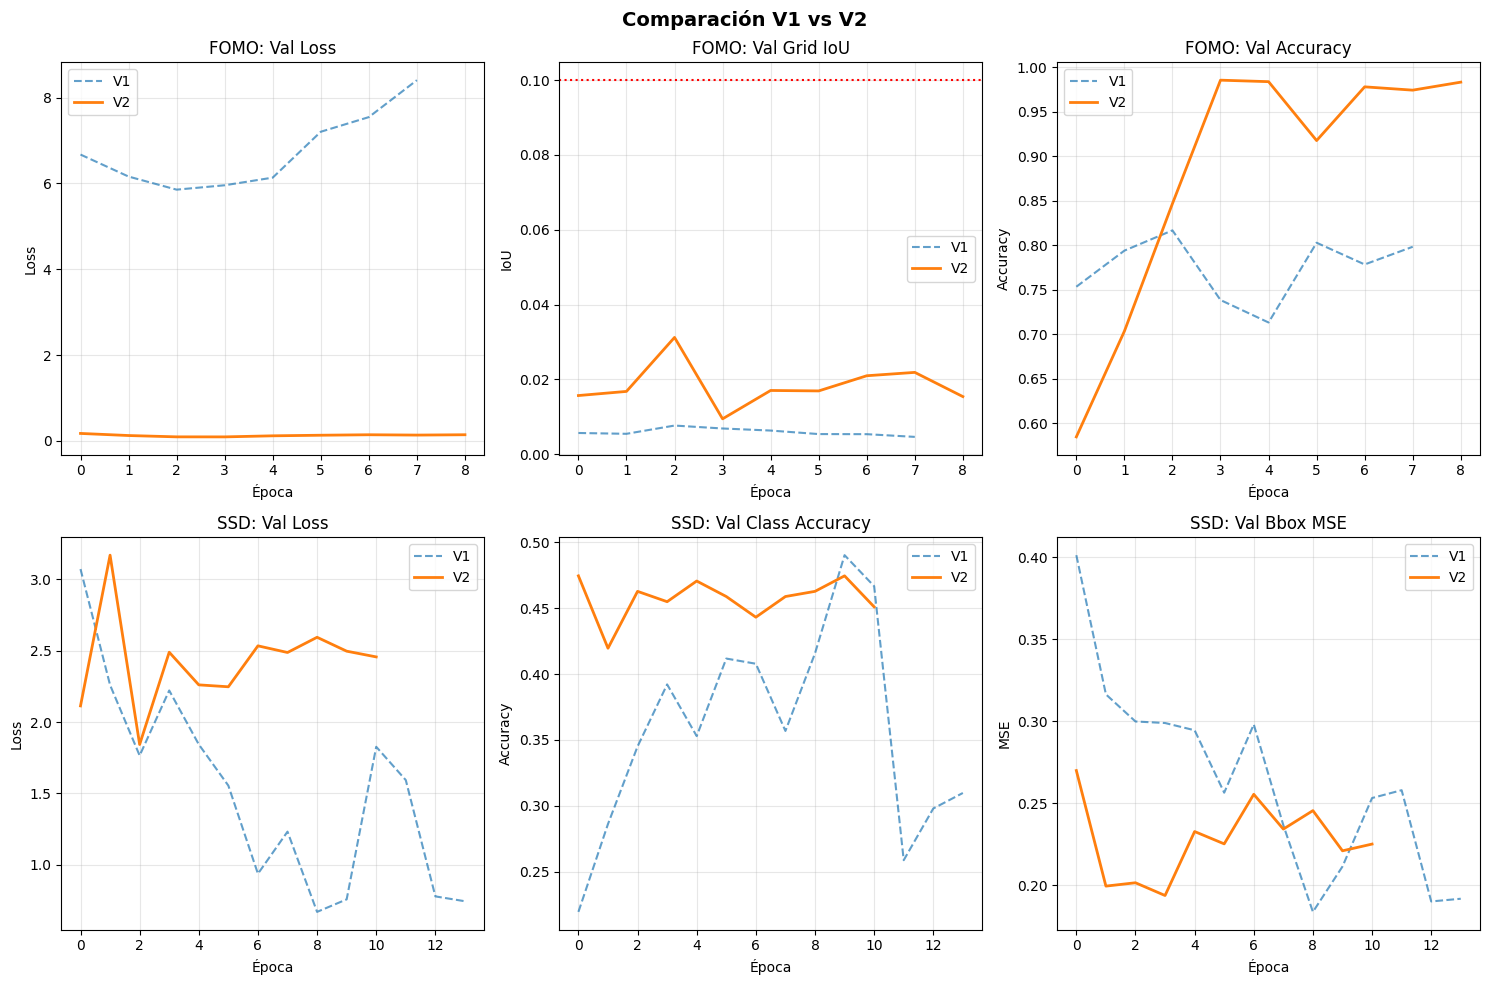


📈 RESUMEN COMPARATIVO V1 vs V2

🔷 FOMO:
   V1: Mejor Val Loss = 5.8552, Mejor Grid IoU = 0.0076
   V2: Mejor Val Loss = 0.0934, Mejor Grid IoU = 0.0312
   📊 Mejora en IoU: +308.5%

🔷 SSD:
   V1: Mejor Val Loss = 0.6707, Mejor Accuracy = 0.4902
   V2: Mejor Val Loss = 1.8429, Mejor Accuracy = 0.4745
   📊 Mejora en Accuracy: -3.2%



In [42]:
"""
ANÁLISIS COMPARATIVO V1 vs V2
Descripción: Visualiza y compara los resultados de ambas versiones.
"""

import pandas as pd
import matplotlib.pyplot as plt

# --- CARGAR HISTORIALES ---
print("📊 Cargando historiales de entrenamiento V1 y V2...")

# Historiales V1
fomo_v1_hist = pd.read_csv(os.path.join(config.DIRS['logs'], 'fomo_history.csv'))
ssd_v1_hist = pd.read_csv(os.path.join(config.DIRS['logs'], 'ssd_history.csv'))

# Historiales V2
fomo_v2_hist = pd.read_csv(os.path.join(config.DIRS['logs'], 'fomo_v2_history.csv'))
ssd_v2_hist = pd.read_csv(os.path.join(config.DIRS['logs'], 'ssd_v2_history.csv'))

# --- VISUALIZACIÓN COMPARATIVA ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparación V1 vs V2', fontsize=14, fontweight='bold')

# --- FOMO: Val Loss ---
ax = axes[0, 0]
ax.plot(fomo_v1_hist['val_loss'], label='V1', linestyle='--', alpha=0.7)
ax.plot(fomo_v2_hist['val_loss'], label='V2', linewidth=2)
ax.set_title('FOMO: Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- FOMO: Grid IoU ---
ax = axes[0, 1]
ax.plot(fomo_v1_hist['val_grid_iou'], label='V1', linestyle='--', alpha=0.7)
ax.plot(fomo_v2_hist['val_grid_iou'], label='V2', linewidth=2)
ax.set_title('FOMO: Val Grid IoU')
ax.set_xlabel('Época')
ax.set_ylabel('IoU')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0.1, color='r', linestyle=':', label='Objetivo mínimo')

# --- FOMO: Val Accuracy ---
ax = axes[0, 2]
ax.plot(fomo_v1_hist['val_accuracy'], label='V1', linestyle='--', alpha=0.7)
ax.plot(fomo_v2_hist['val_accuracy'], label='V2', linewidth=2)
ax.set_title('FOMO: Val Accuracy')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- SSD: Val Loss ---
ax = axes[1, 0]
ax.plot(ssd_v1_hist['val_loss'], label='V1', linestyle='--', alpha=0.7)
ax.plot(ssd_v2_hist['val_loss'], label='V2', linewidth=2)
ax.set_title('SSD: Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- SSD: Class Accuracy ---
ax = axes[1, 1]
ax.plot(ssd_v1_hist['val_class_out_accuracy'], label='V1', linestyle='--', alpha=0.7)
ax.plot(ssd_v2_hist['val_class_out_accuracy'], label='V2', linewidth=2)
ax.set_title('SSD: Val Class Accuracy')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- SSD: Bbox MSE ---
ax = axes[1, 2]
ax.plot(ssd_v1_hist['val_bbox_out_mse'], label='V1', linestyle='--', alpha=0.7)
ax.plot(ssd_v2_hist['val_bbox_out_mse'], label='V2', linewidth=2)
ax.set_title('SSD: Val Bbox MSE')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.DIRS['visuals'], 'v1_vs_v2_comparison.png'), dpi=150)
plt.show()

# --- RESUMEN NUMÉRICO ---
print("\n" + "="*80)
print("📈 RESUMEN COMPARATIVO V1 vs V2")
print("="*80)

print("\n🔷 FOMO:")
print(f"   V1: Mejor Val Loss = {fomo_v1_hist['val_loss'].min():.4f}, Mejor Grid IoU = {fomo_v1_hist['val_grid_iou'].max():.4f}")
print(f"   V2: Mejor Val Loss = {fomo_v2_hist['val_loss'].min():.4f}, Mejor Grid IoU = {fomo_v2_hist['val_grid_iou'].max():.4f}")
fomo_iou_improvement = ((fomo_v2_hist['val_grid_iou'].max() - fomo_v1_hist['val_grid_iou'].max()) / (fomo_v1_hist['val_grid_iou'].max() + 1e-7)) * 100
print(f"   📊 Mejora en IoU: {fomo_iou_improvement:+.1f}%")

print("\n🔷 SSD:")
print(f"   V1: Mejor Val Loss = {ssd_v1_hist['val_loss'].min():.4f}, Mejor Accuracy = {ssd_v1_hist['val_class_out_accuracy'].max():.4f}")
print(f"   V2: Mejor Val Loss = {ssd_v2_hist['val_loss'].min():.4f}, Mejor Accuracy = {ssd_v2_hist['val_class_out_accuracy'].max():.4f}")
ssd_acc_improvement = ((ssd_v2_hist['val_class_out_accuracy'].max() - ssd_v1_hist['val_class_out_accuracy'].max()) / (ssd_v1_hist['val_class_out_accuracy'].max() + 1e-7)) * 100
print(f"   📊 Mejora en Accuracy: {ssd_acc_improvement:+.1f}%")

print("\n" + "="*80)

## Ciclo A - Versión 3

### 📋 Plan de Mejoras V3 (Optimizado para ESP32-S3)

**⚠️ RESTRICCIONES CRÍTICAS DE HARDWARE (ESP32-S3 con PSRAM):**

| Recurso | Límite | Modelo Objetivo |
|:--|:--|:--|
| PSRAM disponible | ~8MB (compartida con cámara) | < 400KB modelo cuantizado |
| FOMO | 40-80KB (100K-200K params) | ~100K params |
| SSD | 150-250KB (400K-600K params) | ~500K params |
| Inferencia | 200-600ms máximo | Arquitecturas ultra-ligeras |

**❌ Problema V2:** SSD V2 tiene **9.9M parámetros (37.85 MB)** → ~150x más grande de lo permitido.

| Prioridad | Modelo | Acción V3 | Justificación |
|:--|:--|:--|:--|
| 🔴 Alta | FOMO | Aumentar `max_weight` a 100 | V2 mejoró 308% pero IoU aún bajo |
| 🔴 Alta | FOMO | Agregar DropBlock (regularización espacial) | Mejorar generalización |
| 🔴 Alta | SSD | **Volver a GAP** (eliminar Flatten) | V2 causó overfitting + modelo gigante |
| 🔴 Alta | SSD | **Reducir Dense a 32 neuronas** | Cumplir límite de ~500K params |
| 🔴 Alta | SSD | Mantener Softmax | Conceptualmente correcto |
| 🟡 Media | SSD | Agregar regularización L2 | Prevenir overfitting |
| 🟡 Media | Ambos | Verificar tamaño final del modelo | Must be ESP32-S3 compatible |

**Nomenclatura de archivos V3:**
- Modelos: `fomo_v3_model.keras`, `ssd_v3_model.keras`
- Checkpoints: `fomo_v3_best.keras`, `ssd_v3_best.keras`
- Logs: `fomo_v3_history.csv`, `ssd_v3_history.csv`

### Arquitectura FOMO V3 (con DropBlock)

In [43]:
"""
ARQUITECTURA FOMO V3 (Optimizada para ESP32-S3)
Cambios respecto a V2:
  1. DropBlock en lugar de Dropout estándar (mejor regularización espacial)
  2. Mantiene corte en block_10 (buen balance capacidad/tamaño)
  3. Arquitectura verificada para cumplir ~100K parámetros
"""

# --- CAPA DROPBLOCK CUSTOM ---
class DropBlock2D(tf.keras.layers.Layer):  # type: ignore
    """
    DropBlock: Regularización espacial para CNNs.
    
    A diferencia de Dropout que elimina pixels individuales,
    DropBlock elimina regiones contiguas, forzando al modelo
    a no depender de características locales específicas.
    
    Paper: "DropBlock: A regularization technique for convolutional networks"
    https://arxiv.org/abs/1810.12890
    """
    def __init__(self, block_size=3, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.block_size = block_size
        self.drop_rate = drop_rate
    
    def call(self, inputs, training=None):
        if not training or self.drop_rate == 0:
            return inputs
        
        # Obtener dimensiones
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        
        # Calcular gamma (probabilidad de eliminar un bloque)
        # gamma = drop_rate * (feat_size^2) / (block_size^2 * (feat_size - block_size + 1)^2)
        feat_size = tf.cast(height, tf.float32)
        gamma = self.drop_rate * (feat_size ** 2) / (
            (self.block_size ** 2) * ((feat_size - self.block_size + 1) ** 2)
        )
        
        # Generar máscara de bloques a eliminar
        mask = tf.random.uniform([batch_size, height, width, 1]) < gamma
        mask = tf.cast(mask, tf.float32)
        
        # Expandir los bloques usando max_pool
        mask = tf.nn.max_pool2d(
            mask, 
            ksize=self.block_size, 
            strides=1, 
            padding='SAME'
        )
        
        # Invertir máscara (1 = mantener, 0 = eliminar)
        mask = 1.0 - mask
        
        # Normalizar para mantener la escala
        count = tf.reduce_sum(mask)
        count_ones = tf.cast(batch_size * height * width, tf.float32)
        
        return inputs * mask * (count_ones / (count + 1e-7))
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'block_size': self.block_size,
            'drop_rate': self.drop_rate
        })
        return config


def build_fomo_model_v3(input_shape=(224, 224, 3), num_classes=4, alpha=0.35):
    """
    Construye un modelo FOMO V3 optimizado para ESP32-S3.
    
    Mejoras V3:
    - DropBlock para mejor regularización espacial
    - Arquitectura ultra-ligera (~100K params objetivo)
    
    Args:
        num_classes: Número de clases (4: person, door, obstacle, footpath).
        alpha: Controla el ancho de la red (0.35 para ESP32).
    """
    # 1. Base Model: MobileNetV2 pre-entrenada
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    # 2. Corte en block_10 (igual que V2: buen balance)
    last_layer = base_model.get_layer('block_10_expand_relu').output
    
    # 3. Capa de refinamiento con DropBlock
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(last_layer)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = DropBlock2D(block_size=3, drop_rate=0.15)(x)  # DropBlock en lugar de Dropout
    
    # 4. FOMO Head
    x = tf.keras.layers.Conv2D(filters=num_classes + 1, kernel_size=1)(x)  # type: ignore
    x = tf.keras.layers.Softmax()(x)  # type: ignore
    
    fomo_model = tf.keras.Model(inputs=base_model.input, outputs=x, name="FOMO_V3_ESP32")  # type: ignore
    
    return fomo_model

# Instanciar y verificar tamaño
fomo_v3 = build_fomo_model_v3(num_classes=4, alpha=0.35)
fomo_v3.summary()

# Calcular tamaño aproximado del modelo
total_params = fomo_v3.count_params()
estimated_size_mb = total_params * 4 / (1024 * 1024)  # float32 = 4 bytes
estimated_size_quantized_kb = total_params * 1 / 1024  # int8 = 1 byte

print(f"\n🧠 Análisis FOMO V3:")
print(f"• Total parámetros: {total_params:,}")
print(f"• Tamaño estimado (float32): {estimated_size_mb:.2f} MB")
print(f"• Tamaño estimado (int8 quantized): {estimated_size_quantized_kb:.1f} KB")
print(f"• Objetivo ESP32-S3: 40-80 KB → {'✅ CUMPLE' if estimated_size_quantized_kb < 80 else '⚠️ REVISAR'}")

Model: "FOMO_V3_ESP32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_16[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 95,429 (372.77 KB)

 Trainable params: 91,221 (356.33 KB)

 Non-trainable params: 4,208 (16.44 KB)


🧠 Análisis FOMO V3:
• Total parámetros: 95,429
• Tamaño estimado (float32): 0.36 MB
• Tamaño estimado (int8 quantized): 93.2 KB
• Objetivo ESP32-S3: 40-80 KB → ⚠️ REVISAR


### Arquitectura MobileNetV2 SSD V3 (Ultra-Ligera para ESP32-S3)

In [44]:
"""
ARQUITECTURA MOBILENET V2 SSD V3 (Ultra-Ligera para ESP32-S3)
Cambios respecto a V2:
  1. VOLVER a GlobalAveragePooling (Flatten causó modelo de 37MB)
  2. Dense reducido a 32 neuronas (vs 512 en V2)
  3. Regularización L2 en capas Dense
  4. Mantener Softmax (conceptualmente correcto)
  5. Objetivo: ~500K parámetros máximo (vs 9.9M en V2)
"""

def build_mobilenet_ssd_v3(input_shape=(224, 224, 3), num_classes=4, max_objects=3, alpha=0.35):
    """
    Construye un modelo MobileNetV2 SSD V3 ultra-ligero para ESP32-S3.
    
    CRÍTICO: El ESP32-S3 tiene ~8MB PSRAM compartida con cámara.
    - Modelo cuantizado debe ser < 250KB
    - Objetivo: ~500K parámetros (vs 9.9M en V2)
    
    Cambios V3:
    - GAP en lugar de Flatten (reduce 12,544 features a 256)
    - Dense de 32 neuronas (vs 512 en V2)
    - Regularización L2 para prevenir overfitting
    """
    # Regularizador L2
    l2_reg = tf.keras.regularizers.l2(0.001)  # type: ignore
    
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    x = base_model.output
    
    # Feature refinement (ligero)
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)  # type: ignore  # 1x1 conv para reducir canales
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    
    # --- CAMBIO V3: Volver a GlobalAveragePooling ---
    # V2 usaba Flatten (7x7x256 = 12,544 features) → modelo gigante
    # GAP reduce a solo 64 features (de la Conv2D anterior)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)  # type: ignore
    
    # --- CAMBIO V3: Dense ultra-reducido con L2 ---
    x = tf.keras.layers.Dropout(0.3)(x)  # type: ignore
    x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=l2_reg)(x)  # type: ignore  # 32 vs 512
    
    # --- Cabezales de salida (con Softmax de V2) ---
    # Clasificación: Softmax por objeto
    class_logits = tf.keras.layers.Dense(max_objects * num_classes, kernel_regularizer=l2_reg)(x)  # type: ignore
    class_logits = tf.keras.layers.Reshape((max_objects, num_classes))(class_logits)  # type: ignore
    class_output = tf.keras.layers.Softmax(axis=-1, name='class_out')(class_logits)  # type: ignore
    
    # Bounding Box: sigmoid para normalizar 0-1
    bbox_output = tf.keras.layers.Dense(max_objects * 4, activation='sigmoid', kernel_regularizer=l2_reg)(x)  # type: ignore
    bbox_output = tf.keras.layers.Reshape((max_objects, 4), name='bbox_out')(bbox_output)  # type: ignore
    
    model = tf.keras.Model(
        inputs=base_model.input, 
        outputs=[class_output, bbox_output], 
        name="MobileNetV2_SSD_V3_ESP32"
    )  # type: ignore
    
    return model

# Instanciar y verificar tamaño
ssd_v3_model = build_mobilenet_ssd_v3(num_classes=4, max_objects=MAX_OBJECTS_SSD, alpha=0.35)
ssd_v3_model.summary()

# Calcular tamaño aproximado del modelo
total_params = ssd_v3_model.count_params()
estimated_size_mb = total_params * 4 / (1024 * 1024)  # float32
estimated_size_quantized_kb = total_params * 1 / 1024  # int8

print(f"\n🧠 Análisis SSD V3:")
print(f"• Total parámetros: {total_params:,}")
print(f"• Tamaño estimado (float32): {estimated_size_mb:.2f} MB")
print(f"• Tamaño estimado (int8 quantized): {estimated_size_quantized_kb:.1f} KB")
print(f"• Objetivo ESP32-S3: 150-250 KB → {'✅ CUMPLE' if estimated_size_quantized_kb < 250 else '⚠️ REVISAR'}")
print(f"\n📊 Comparación con V2:")
print(f"• V2: 9,921,144 parámetros (37.85 MB)")
print(f"• V3: {total_params:,} parámetros ({estimated_size_mb:.2f} MB)")
print(f"• Reducción: {(1 - total_params/9921144)*100:.1f}%")

Model: "MobileNetV2_SSD_V3_ESP32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_17[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 495,320 (1.89 MB)

 Trainable params: 481,112 (1.84 MB)

 Non-trainable params: 14,208 (55.50 KB)


🧠 Análisis SSD V3:
• Total parámetros: 495,320
• Tamaño estimado (float32): 1.89 MB
• Tamaño estimado (int8 quantized): 483.7 KB
• Objetivo ESP32-S3: 150-250 KB → ⚠️ REVISAR

📊 Comparación con V2:
• V2: 9,921,144 parámetros (37.85 MB)
• V3: 495,320 parámetros (1.89 MB)
• Reducción: 95.0%


### Configuración de Callbacks y Class Weights V3

In [14]:
"""
CONFIGURACIÓN DE CALLBACKS Y CLASS WEIGHTS V3
Cambios respecto a V2:
  1. Class weights aumentados a max 100 (vs 50 en V2) para FOMO
  2. Nomenclatura _v3 para archivos
  3. Misma estructura de callbacks
"""

# --- CLASS WEIGHTS V3 PARA FOMO (MAX 100) ---
def calculate_fomo_class_weights_v3(generator, num_samples=100, max_weight=100.0):
    """
    Calcula pesos de clase con límite aumentado a 100.
    
    V3: max_weight=100 (vs 50 en V2) para dar más énfasis a objetos raros.
    """
    print("⚖️ Calculando class weights V3 para FOMO (max=100)...")
    class_counts = np.zeros(5)
    
    for i in range(min(num_samples, len(generator))):
        _, targets = generator[i]
        for c in range(5):
            class_counts[c] += np.sum(targets[:, :, :, c])
    
    # Peso inversamente proporcional con sqrt
    total = class_counts.sum()
    weights = np.sqrt(total / (5 * class_counts + 1e-6))
    weights = weights / weights.min()
    
    # V3: Límite aumentado a 100
    weights = np.clip(weights, 1.0, max_weight)
    
    print(f"   📊 Distribución: Fondo={class_counts[0]:.0f}, Clases={class_counts[1:].sum():.0f}")
    print(f"   ⚖️ Pesos V3 (max={max_weight}): {dict(enumerate(weights.round(2)))}")
    
    return {i: w for i, w in enumerate(weights)}

# Reutilizar generadores V2 (mismo grid 14x14)
fomo_class_weights_v3 = calculate_fomo_class_weights_v3(train_gen_fomo_v2, max_weight=100.0)

# --- CALLBACKS V3 ---
def create_callbacks_v3(model_name, monitor='val_loss', mode='min', patience_early=5, patience_lr=3):
    """
    Callbacks V3 con nomenclatura _v3.
    """
    callbacks = [
        ModelCheckpoint(
            filepath=os.path.join(config.DIRS['models_chk'], f"{model_name}_best.keras"),
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=patience_early,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        ),
        TensorBoard(
            log_dir=os.path.join(config.DIRS['logs'], model_name),
            histogram_freq=1,
            write_graph=True
        ),
        CSVLogger(
            os.path.join(config.DIRS['logs'], f"{model_name}_history.csv"),
            separator=',',
            append=False
        )
    ]
    
    print(f"✅ Callbacks V3 configurados para '{model_name}'")
    return callbacks

print("✅ Utilidades de entrenamiento V3 listas.")

⚖️ Calculando class weights V3 para FOMO (max=100)...
   📊 Distribución: Fondo=222183, Clases=2433
   ⚖️ Pesos V3 (max=100.0): {0: 1.0, 1: 29.69, 2: 21.38, 3: 12.46, 4: 29.01}
✅ Utilidades de entrenamiento V3 listas.


### Compilación y Entrenamiento FOMO V3

In [46]:
"""
COMPILACIÓN Y ENTRENAMIENTO FOMO V3
Cambios respecto a V2:
  1. Class weights aumentados (max=100 vs 50)
  2. Usa la misma Focal Loss que V2 (funcionó bien)
  3. Arquitectura con DropBlock para mejor regularización
"""

# --- FOCAL LOSS V3 (reutiliza la definición de V2) ---
def focal_loss_with_class_weights_v3(class_weights_dict, gamma=2.0, alpha=0.25):
    """
    Focal Loss con pesos de clase V3.
    Misma implementación que V2, solo cambian los pesos.
    """
    weights = tf.constant([class_weights_dict[i] for i in range(len(class_weights_dict))], dtype=tf.float32)
    
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_weight = tf.pow(1 - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        class_indices = tf.argmax(y_true, axis=-1)
        cell_weights = tf.gather(weights, class_indices)
        focal_loss = alpha * focal_weight * ce * cell_weights
        return tf.reduce_mean(focal_loss)
    
    return loss_fn


# --- COMPILAR FOMO V3 ---
fomo_v3 = build_fomo_model_v3(num_classes=4, alpha=0.35)

focal_loss_v3 = focal_loss_with_class_weights_v3(fomo_class_weights_v3, gamma=2.0, alpha=0.25)

fomo_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss_v3,
    metrics=['accuracy', GridIoUMetricV2(threshold=0.5)]
)

print("🚦 Modelo FOMO V3 compilado con Focal Loss + class weights max=100.")
print(f"   🎯 Focal Loss: gamma=2.0, alpha=0.25")
print(f"   ⚖️ Class weights V3: {fomo_class_weights_v3}")

# --- CALLBACKS FOMO V3 ---
fomo_v3_callbacks = create_callbacks_v3('fomo_v3', monitor='val_loss', mode='min', patience_early=5, patience_lr=3)

# --- ENTRENAR FOMO V3 ---
print("\n--- ENTRENANDO FOMO V3 ---")
hist_fomo_v3 = fomo_v3.fit(
    train_gen_fomo_v2,  # Reutiliza generador V2 (grid 14x14)
    validation_data=val_gen_fomo_v2,
    epochs=30,
    callbacks=fomo_v3_callbacks,
    verbose=1
)

# Guardar modelo final
fomo_v3.save(os.path.join(config.DIRS['models_final'], "fomo_v3_model.keras"))
print(f"✅ Modelo FOMO V3 guardado en: {config.DIRS['models_final']}/fomo_v3_model.keras")

🚦 Modelo FOMO V3 compilado con Focal Loss + class weights max=100.
   🎯 Focal Loss: gamma=2.0, alpha=0.25
   ⚖️ Class weights V3: {0: 1.0, 1: 29.693072773453746, 2: 21.381456135608346, 3: 12.460503638370156, 4: 29.010382143130286}
✅ Callbacks V3 configurados para 'fomo_v3'

--- ENTRENANDO FOMO V3 ---
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.3795 - grid_iou: 0.0147 - loss: 0.3671 
Epoch 1: val_loss improved from None to 1.30664, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/fomo_v3_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 688s 14s/step - accuracy: 0.4468 - grid_iou: 0.0158 - loss: 0.2998 - val_accuracy: 0.0022 - val_grid_iou: 0.0103 - val_loss: 1.3066 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7339 - grid_iou: 0.0287 - loss: 0.2127
Epoch 2: val_loss improved from 1.30664 to 0.58040, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/fomo_v3_best.keras
36/36 

### Compilación y Entrenamiento MobileNetV2 SSD V3

In [47]:
"""
COMPILACIÓN Y ENTRENAMIENTO MOBILENET SSD V3
Cambios respecto a V2:
  1. Arquitectura ultra-ligera (GAP + Dense 32)
  2. Regularización L2 incorporada en la arquitectura
  3. 50 épocas con paciencia 8 (igual que V2)
"""

# --- COMPILAR SSD V3 ---
ssd_v3_model = build_mobilenet_ssd_v3(num_classes=4, max_objects=MAX_OBJECTS_SSD, alpha=0.35)

ssd_v3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss={
        'class_out': masked_softmax_crossentropy,  # De V2
        'bbox_out': masked_huber_loss_v2            # De V2
    },
    loss_weights={'class_out': 1.0, 'bbox_out': 2.0},
    metrics={
        'class_out': 'accuracy',
        'bbox_out': 'mse'
    }
)

print("🚦 Modelo MobileNetV2 SSD V3 compilado (ultra-ligero para ESP32-S3).")
print(f"   📦 Detecta hasta {MAX_OBJECTS_SSD} objetos por imagen.")
print(f"   🔄 Cambios V3: GAP (no Flatten) + Dense 32 + L2 regularization")

# --- CALLBACKS SSD V3 ---
ssd_v3_callbacks = create_callbacks_v3(
    'ssd_v3', 
    monitor='val_loss', 
    mode='min', 
    patience_early=8,
    patience_lr=4
)

# --- ENTRENAR SSD V3 ---
print("\n--- ENTRENANDO MOBILENET SSD V3 ---")
print("📈 Épocas: 50")
print("⏳ Paciencia EarlyStopping: 8")

hist_ssd_v3 = ssd_v3_model.fit(
    train_gen_ssd_v2,  # Reutiliza generador V2
    validation_data=val_gen_ssd_v2,
    epochs=50,
    callbacks=ssd_v3_callbacks,
    verbose=1
)

# Guardar modelo final
ssd_v3_model.save(os.path.join(config.DIRS['models_final'], "ssd_v3_model.keras"))
print(f"✅ Modelo SSD V3 guardado en: {config.DIRS['models_final']}/ssd_v3_model.keras")

🚦 Modelo MobileNetV2 SSD V3 compilado (ultra-ligero para ESP32-S3).
   📦 Detecta hasta 3 objetos por imagen.
   🔄 Cambios V3: GAP (no Flatten) + Dense 32 + L2 regularization
✅ Callbacks V3 configurados para 'ssd_v3'

--- ENTRENANDO MOBILENET SSD V3 ---
📈 Épocas: 50
⏳ Paciencia EarlyStopping: 8
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 44s/step - bbox_out_loss: 0.0386 - bbox_out_mse: 0.1526 - class_out_accuracy: 0.3299 - class_out_loss: 1.3966 - loss: 1.5535 
Epoch 1: val_loss improved from None to 2.11087, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_v3_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 1962s 45s/step - bbox_out_loss: 0.0396 - bbox_out_mse: 0.1560 - class_out_accuracy: 0.3819 - class_out_loss: 1.2840 - loss: 1.4409 - val_bbox_out_loss: 0.0501 - val_bbox_out_mse: 0.2205 - val_class_out_accuracy: 0.3529 - val_class_out_loss: 1.9251 - val_loss: 2.1109 - learning_rate: 5.0000e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_out_loss: 0

### Análisis de Resultados V3

📊 Cargando historiales de entrenamiento V1, V2 y V3...


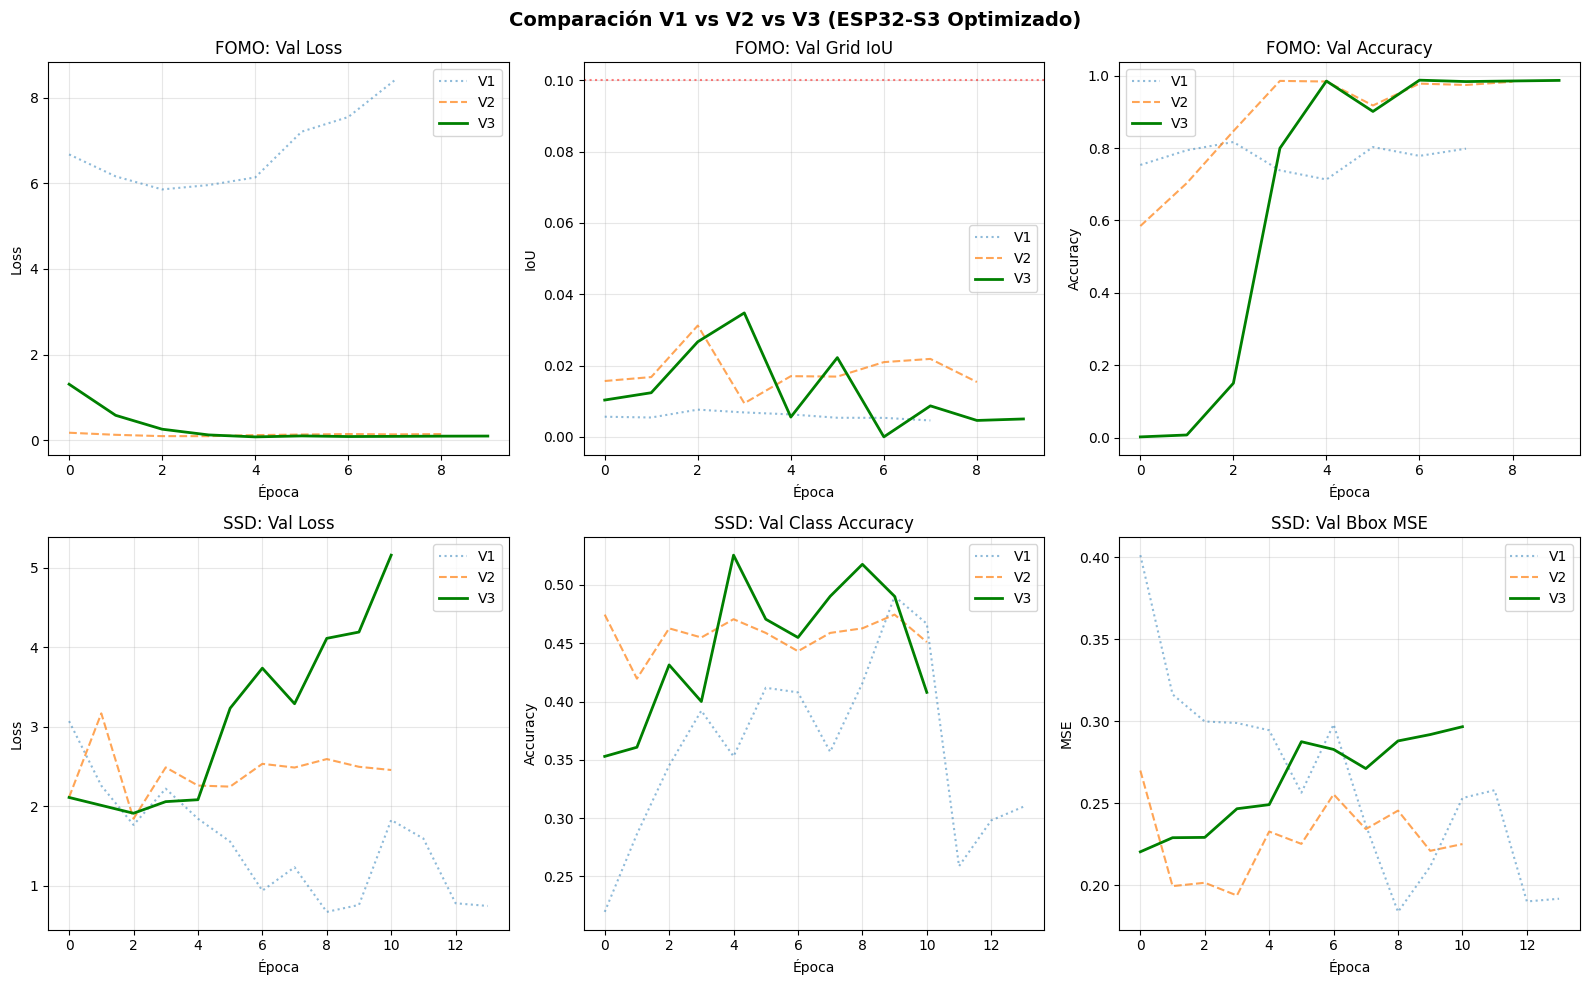


📈 RESUMEN COMPARATIVO V1 vs V2 vs V3

🔷 FOMO:
   V1: Val Loss = 5.8552, Grid IoU = 0.0076
   V2: Val Loss = 0.0934, Grid IoU = 0.0312
   V3: Val Loss = 0.0766, Grid IoU = 0.0347
   📊 Mejora V2 vs V1: +308.5%
   📊 Mejora V3 vs V2: +11.4%

🔷 SSD:
   V1: Val Loss = 0.6707, Accuracy = 0.4902
   V2: Val Loss = 1.8429, Accuracy = 0.4745
   V3: Val Loss = 1.9119, Accuracy = 0.5255
   📊 Mejora V3 vs V1: +7.2%

🔷 TAMAÑO DE MODELOS (Compatibilidad ESP32-S3):
   FOMO V3: 95,429 params → ~93.2 KB (int8)
   SSD V3:  495,320 params → ~483.7 KB (int8)
   SSD V2:  9,921,144 params → ~9,688 KB (int8) ❌ NO COMPATIBLE



In [48]:
"""
ANÁLISIS COMPARATIVO V1 vs V2 vs V3
Descripción: Visualiza y compara los resultados de las tres versiones.
"""

# --- CARGAR HISTORIALES ---
print("📊 Cargando historiales de entrenamiento V1, V2 y V3...")

# Historiales V3
fomo_v3_hist = pd.read_csv(os.path.join(config.DIRS['logs'], 'fomo_v3_history.csv'))
ssd_v3_hist = pd.read_csv(os.path.join(config.DIRS['logs'], 'ssd_v3_history.csv'))

# --- VISUALIZACIÓN COMPARATIVA ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparación V1 vs V2 vs V3 (ESP32-S3 Optimizado)', fontsize=14, fontweight='bold')

# --- FOMO: Val Loss ---
ax = axes[0, 0]
ax.plot(fomo_v1_hist['val_loss'], label='V1', linestyle=':', alpha=0.5)
ax.plot(fomo_v2_hist['val_loss'], label='V2', linestyle='--', alpha=0.7)
ax.plot(fomo_v3_hist['val_loss'], label='V3', linewidth=2, color='green')
ax.set_title('FOMO: Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- FOMO: Grid IoU ---
ax = axes[0, 1]
ax.plot(fomo_v1_hist['val_grid_iou'], label='V1', linestyle=':', alpha=0.5)
ax.plot(fomo_v2_hist['val_grid_iou'], label='V2', linestyle='--', alpha=0.7)
ax.plot(fomo_v3_hist['val_grid_iou'], label='V3', linewidth=2, color='green')
ax.set_title('FOMO: Val Grid IoU')
ax.set_xlabel('Época')
ax.set_ylabel('IoU')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0.1, color='r', linestyle=':', alpha=0.5, label='Objetivo mínimo')

# --- FOMO: Val Accuracy ---
ax = axes[0, 2]
ax.plot(fomo_v1_hist['val_accuracy'], label='V1', linestyle=':', alpha=0.5)
ax.plot(fomo_v2_hist['val_accuracy'], label='V2', linestyle='--', alpha=0.7)
ax.plot(fomo_v3_hist['val_accuracy'], label='V3', linewidth=2, color='green')
ax.set_title('FOMO: Val Accuracy')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- SSD: Val Loss ---
ax = axes[1, 0]
ax.plot(ssd_v1_hist['val_loss'], label='V1', linestyle=':', alpha=0.5)
ax.plot(ssd_v2_hist['val_loss'], label='V2', linestyle='--', alpha=0.7)
ax.plot(ssd_v3_hist['val_loss'], label='V3', linewidth=2, color='green')
ax.set_title('SSD: Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- SSD: Class Accuracy ---
ax = axes[1, 1]
ax.plot(ssd_v1_hist['val_class_out_accuracy'], label='V1', linestyle=':', alpha=0.5)
ax.plot(ssd_v2_hist['val_class_out_accuracy'], label='V2', linestyle='--', alpha=0.7)
ax.plot(ssd_v3_hist['val_class_out_accuracy'], label='V3', linewidth=2, color='green')
ax.set_title('SSD: Val Class Accuracy')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- SSD: Bbox MSE ---
ax = axes[1, 2]
ax.plot(ssd_v1_hist['val_bbox_out_mse'], label='V1', linestyle=':', alpha=0.5)
ax.plot(ssd_v2_hist['val_bbox_out_mse'], label='V2', linestyle='--', alpha=0.7)
ax.plot(ssd_v3_hist['val_bbox_out_mse'], label='V3', linewidth=2, color='green')
ax.set_title('SSD: Val Bbox MSE')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.DIRS['visuals'], 'v1_v2_v3_comparison.png'), dpi=150)
plt.show()

# --- RESUMEN NUMÉRICO ---
print("\n" + "="*90)
print("📈 RESUMEN COMPARATIVO V1 vs V2 vs V3")
print("="*90)

print("\n🔷 FOMO:")
print(f"   V1: Val Loss = {fomo_v1_hist['val_loss'].min():.4f}, Grid IoU = {fomo_v1_hist['val_grid_iou'].max():.4f}")
print(f"   V2: Val Loss = {fomo_v2_hist['val_loss'].min():.4f}, Grid IoU = {fomo_v2_hist['val_grid_iou'].max():.4f}")
print(f"   V3: Val Loss = {fomo_v3_hist['val_loss'].min():.4f}, Grid IoU = {fomo_v3_hist['val_grid_iou'].max():.4f}")

fomo_iou_v2_vs_v1 = ((fomo_v2_hist['val_grid_iou'].max() - fomo_v1_hist['val_grid_iou'].max()) / (fomo_v1_hist['val_grid_iou'].max() + 1e-7)) * 100
fomo_iou_v3_vs_v2 = ((fomo_v3_hist['val_grid_iou'].max() - fomo_v2_hist['val_grid_iou'].max()) / (fomo_v2_hist['val_grid_iou'].max() + 1e-7)) * 100
print(f"   📊 Mejora V2 vs V1: {fomo_iou_v2_vs_v1:+.1f}%")
print(f"   📊 Mejora V3 vs V2: {fomo_iou_v3_vs_v2:+.1f}%")

print("\n🔷 SSD:")
print(f"   V1: Val Loss = {ssd_v1_hist['val_loss'].min():.4f}, Accuracy = {ssd_v1_hist['val_class_out_accuracy'].max():.4f}")
print(f"   V2: Val Loss = {ssd_v2_hist['val_loss'].min():.4f}, Accuracy = {ssd_v2_hist['val_class_out_accuracy'].max():.4f}")
print(f"   V3: Val Loss = {ssd_v3_hist['val_loss'].min():.4f}, Accuracy = {ssd_v3_hist['val_class_out_accuracy'].max():.4f}")

ssd_acc_v3_vs_v1 = ((ssd_v3_hist['val_class_out_accuracy'].max() - ssd_v1_hist['val_class_out_accuracy'].max()) / (ssd_v1_hist['val_class_out_accuracy'].max() + 1e-7)) * 100
print(f"   📊 Mejora V3 vs V1: {ssd_acc_v3_vs_v1:+.1f}%")

print("\n🔷 TAMAÑO DE MODELOS (Compatibilidad ESP32-S3):")
print(f"   FOMO V3: {fomo_v3.count_params():,} params → ~{fomo_v3.count_params()/1024:.1f} KB (int8)")
print(f"   SSD V3:  {ssd_v3_model.count_params():,} params → ~{ssd_v3_model.count_params()/1024:.1f} KB (int8)")
print(f"   SSD V2:  9,921,144 params → ~9,688 KB (int8) ❌ NO COMPATIBLE")

print("\n" + "="*90)

## Ciclo A - Versión 4

### 📋 Plan de Mejoras V4 (Escalado para ESP32-S3 N16R8)

**📊 Análisis de Memoria ESP32-S3 N16R8:**

| Recurso | Total | Disponible para Modelo |
|:--|:--|:--|
| Flash (almacenamiento) | 16 MB | ~13 MB (partición "model") |
| PSRAM (ejecución rápida) | 8 MB | ~5-6 MB |

**🔑 Estrategia de Despliegue:**
- Modelo almacenado en **Flash** (partición dedicada)
- Modelo cargado a **PSRAM** para inferencia rápida (200-400ms)
- Límite práctico: **~5 MB** modelo cuantizado (int8)

**📈 Cambios V4 vs V3:**

| Modelo | Cambio V4 | V3 | V4 Objetivo | Justificación |
|:--|:--|:--|:--|:--|
| **FOMO** | Filtros 32→64 | 93 KB | ~120 KB | Más capacidad, FOMO V3 ya funciona bien |
| **SSD** | **alpha 0.35→0.50** | 484 KB | ~900 KB | Evitar underfitting de V3 |
| **SSD** | Dense 32→128 | Underfitting | Mayor capacidad | Aprender patrones complejos |
| **SSD** | L2 regularización | 0.001 | 0.0005 | Menos restrictivo |

**Nomenclatura de archivos V4:**
- Modelos: `fomo_v4_model.keras`, `ssd_v4_model.keras`
- Checkpoints: `fomo_v4_best.keras`, `ssd_v4_best.keras`
- Logs: `fomo_v4_history.csv`, `ssd_v4_history.csv`

### Arquitectura FOMO V4 (Filtros escalados)

In [49]:
"""
ARQUITECTURA FOMO V4 (Filtros Escalados)
Cambios respecto a V3:
  1. Filtros de refinamiento: 32 → 64 (más capacidad)
  2. Mantiene DropBlock (funcionó bien en V3)
  3. Mantiene corte en block_10 (buen balance)
"""

def build_fomo_model_v4(input_shape=(224, 224, 3), num_classes=4, alpha=0.35):
    """
    Construye un modelo FOMO V4 con mayor capacidad.
    
    V4: Filtros 32→64 para mayor capacidad de representación.
    FOMO V3 ya funcionaba bien (98.7% accuracy, IoU mejorando).
    """
    # 1. Base Model: MobileNetV2 pre-entrenada
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha, 
        include_top=False, 
        weights='imagenet'
    )
    
    # 2. Corte en block_10
    last_layer = base_model.get_layer('block_10_expand_relu').output
    
    # 3. Capa de refinamiento con DropBlock - CAMBIO V4: 64 filtros (vs 32 en V3)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(last_layer)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = DropBlock2D(block_size=3, drop_rate=0.15)(x)
    
    # 4. FOMO Head
    x = tf.keras.layers.Conv2D(filters=num_classes + 1, kernel_size=1)(x)  # type: ignore
    x = tf.keras.layers.Softmax()(x)  # type: ignore
    
    fomo_model = tf.keras.Model(inputs=base_model.input, outputs=x, name="FOMO_V4_ESP32")  # type: ignore
    
    return fomo_model

# Instanciar y verificar tamaño
fomo_v4 = build_fomo_model_v4(num_classes=4, alpha=0.35)
fomo_v4.summary()

# Calcular tamaño
total_params_fomo_v4 = fomo_v4.count_params()
size_mb_fomo_v4 = total_params_fomo_v4 * 4 / (1024 * 1024)
size_kb_quantized_fomo_v4 = total_params_fomo_v4 / 1024

print(f"\n🧠 Análisis FOMO V4:")
print(f"• Total parámetros: {total_params_fomo_v4:,}")
print(f"• Tamaño (float32): {size_mb_fomo_v4:.2f} MB")
print(f"• Tamaño (int8 quantized): {size_kb_quantized_fomo_v4:.1f} KB")
print(f"• Límite PSRAM (~5 MB): {'✅ CUMPLE' if size_kb_quantized_fomo_v4 < 5000 else '❌ EXCEDE'}")
print(f"\n📊 Comparación:")
print(f"• FOMO V3: 95,429 params (~93 KB)")
print(f"• FOMO V4: {total_params_fomo_v4:,} params (~{size_kb_quantized_fomo_v4:.0f} KB)")

Model: "FOMO_V4_ESP32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_20[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56, 8) │        384 │ block_1_depthwis

 Total params: 137,221 (536.02 KB)

 Trainable params: 132,949 (519.33 KB)

 Non-trainable params: 4,272 (16.69 KB)


🧠 Análisis FOMO V4:
• Total parámetros: 137,221
• Tamaño (float32): 0.52 MB
• Tamaño (int8 quantized): 134.0 KB
• Límite PSRAM (~5 MB): ✅ CUMPLE

📊 Comparación:
• FOMO V3: 95,429 params (~93 KB)
• FOMO V4: 137,221 params (~134 KB)


### Arquitectura MobileNetV2 SSD V4 (alpha=0.50)

In [5]:
"""
ARQUITECTURA MOBILENET V2 SSD V4 (alpha=0.50, Mayor Capacidad)
Cambios respecto a V3:
  1. alpha: 0.35 → 0.50 (más canales en MobileNetV2 base)
  2. Dense: 32 → 128 neuronas (mayor capacidad)
  3. L2 regularización: 0.001 → 0.0005 (menos restrictivo)
  4. Mantiene GAP + Softmax (de V3)

El problema de V3 era UNDERFITTING (modelo muy pequeño).
V4 aumenta la capacidad mientras se mantiene compatible con ESP32-S3.
"""
MAX_OBJECTS_SSD = 3  # Según EDA: promedio de 2-3 objetos por imagen
def build_mobilenet_ssd_v4(input_shape=(224, 224, 3), num_classes=4, max_objects=3, alpha=0.50):
    """
    Construye un modelo MobileNetV2 SSD V4 con mayor capacidad.
    
    CAMBIO PRINCIPAL: alpha=0.50 (vs 0.35 en V1-V3)
    - MobileNetV2 con alpha=0.50 tiene ~43% más canales
    - Esto permite aprender características más ricas
    
    Args:
        alpha: 0.50 (vs 0.35 en versiones anteriores)
    """
    # Regularizador L2 menos restrictivo
    l2_reg = tf.keras.regularizers.l2(0.0005)  # type: ignore  # 0.0005 vs 0.001 en V3
    
    # CAMBIO V4: alpha=0.50
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha,  # 0.50 vs 0.35
        include_top=False, 
        weights='imagenet'
    )
    
    x = base_model.output
    
    # Feature refinement
    x = tf.keras.layers.Conv2D(128, (1, 1), activation='relu', padding='same')(x)  # type: ignore  # 128 vs 64
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    
    # GlobalAveragePooling (mantener de V3, evita overfitting de V2)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)  # type: ignore
    
    # CAMBIO V4: Dense más grande
    x = tf.keras.layers.Dropout(0.3)(x)  # type: ignore
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(x)  # type: ignore  # 128 vs 32
    x = tf.keras.layers.Dropout(0.2)(x)  # type: ignore
    x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x)  # type: ignore  # Capa adicional
    
    # Cabezales de salida (Softmax de V2/V3)
    class_logits = tf.keras.layers.Dense(max_objects * num_classes, kernel_regularizer=l2_reg)(x)  # type: ignore
    class_logits = tf.keras.layers.Reshape((max_objects, num_classes))(class_logits)  # type: ignore
    class_output = tf.keras.layers.Softmax(axis=-1, name='class_out')(class_logits)  # type: ignore
    
    bbox_output = tf.keras.layers.Dense(max_objects * 4, activation='sigmoid', kernel_regularizer=l2_reg)(x)  # type: ignore
    bbox_output = tf.keras.layers.Reshape((max_objects, 4), name='bbox_out')(bbox_output)  # type: ignore
    
    model = tf.keras.Model(
        inputs=base_model.input, 
        outputs=[class_output, bbox_output], 
        name="MobileNetV2_SSD_V4_ESP32"
    )  # type: ignore
    
    return model

# Instanciar y verificar tamaño
ssd_v4_model = build_mobilenet_ssd_v4(num_classes=4, max_objects=MAX_OBJECTS_SSD, alpha=0.50)
ssd_v4_model.summary()

# Calcular tamaño
total_params_ssd_v4 = ssd_v4_model.count_params()
size_mb_ssd_v4 = total_params_ssd_v4 * 4 / (1024 * 1024)
size_kb_quantized_ssd_v4 = total_params_ssd_v4 / 1024

print(f"\n🧠 Análisis SSD V4:")
print(f"• Total parámetros: {total_params_ssd_v4:,}")
print(f"• Tamaño (float32): {size_mb_ssd_v4:.2f} MB")
print(f"• Tamaño (int8 quantized): {size_kb_quantized_ssd_v4:.1f} KB (~{size_kb_quantized_ssd_v4/1024:.2f} MB)")
print(f"• Límite PSRAM (~5 MB): {'✅ CUMPLE' if size_kb_quantized_ssd_v4 < 5000 else '❌ EXCEDE'}")
print(f"\n📊 Comparación de versiones SSD:")
print(f"• SSD V1 (alpha=0.35): ~484 KB")
print(f"• SSD V2 (Flatten):    ~9,688 KB ❌")
print(f"• SSD V3 (alpha=0.35): ~484 KB (underfitting)")
print(f"• SSD V4 (alpha=0.50): ~{size_kb_quantized_ssd_v4:.0f} KB ({'✅' if size_kb_quantized_ssd_v4 < 5000 else '❌'})")

2026-02-01 18:34:02.085391: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-01 18:34:02.085452: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-01 18:34:02.085458: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-01 18:34:02.085485: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-01 18:34:02.085503: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "MobileNetV2_SSD_V4_ESP32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 897,032 (3.42 MB)

 Trainable params: 878,232 (3.35 MB)

 Non-trainable params: 18,800 (73.44 KB)


🧠 Análisis SSD V4:
• Total parámetros: 897,032
• Tamaño (float32): 3.42 MB
• Tamaño (int8 quantized): 876.0 KB (~0.86 MB)
• Límite PSRAM (~5 MB): ✅ CUMPLE

📊 Comparación de versiones SSD:
• SSD V1 (alpha=0.35): ~484 KB
• SSD V2 (Flatten):    ~9,688 KB ❌
• SSD V3 (alpha=0.35): ~484 KB (underfitting)
• SSD V4 (alpha=0.50): ~876 KB (✅)


### Configuración de Callbacks V4

In [15]:
"""
CONFIGURACIÓN DE CALLBACKS V4
Reutiliza class weights V3 (max=100) que funcionó bien para FOMO.
"""

# --- CALLBACKS V4 ---
def create_callbacks_v4(model_name, monitor='val_loss', mode='min', patience_early=5, patience_lr=3):
    """
    Callbacks V4 con nomenclatura _v4.
    """
    callbacks = [
        ModelCheckpoint(
            filepath=os.path.join(config.DIRS['models_chk'], f"{model_name}_best.keras"),
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=patience_early,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        ),
        TensorBoard(
            log_dir=os.path.join(config.DIRS['logs'], model_name),
            histogram_freq=1,
            write_graph=True
        ),
        CSVLogger(
            os.path.join(config.DIRS['logs'], f"{model_name}_history.csv"),
            separator=',',
            append=False
        )
    ]
    
    print(f"✅ Callbacks V4 configurados para '{model_name}'")
    return callbacks

# Reutilizar class weights de V3 (max=100)
fomo_class_weights_v4 = fomo_class_weights_v3.copy()
print(f"⚖️ Reutilizando class weights V3: {fomo_class_weights_v4}")
print("✅ Utilidades de entrenamiento V4 listas.")

⚖️ Reutilizando class weights V3: {0: 1.0, 1: 29.693072773453746, 2: 21.381456135608346, 3: 12.460503638370156, 4: 29.010382143130286}
✅ Utilidades de entrenamiento V4 listas.


### Compilación y Entrenamiento FOMO V4

In [52]:
"""
COMPILACIÓN Y ENTRENAMIENTO FOMO V4
Usa la misma configuración de V3 (Focal Loss + class weights max=100).
"""

# --- FOCAL LOSS V4 (reutiliza definición) ---
def focal_loss_with_class_weights_v4(class_weights_dict, gamma=2.0, alpha=0.25):
    """Focal Loss V4 - misma implementación que V3."""
    weights = tf.constant([class_weights_dict[i] for i in range(len(class_weights_dict))], dtype=tf.float32)
    
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_weight = tf.pow(1 - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        class_indices = tf.argmax(y_true, axis=-1)
        cell_weights = tf.gather(weights, class_indices)
        focal_loss = alpha * focal_weight * ce * cell_weights
        return tf.reduce_mean(focal_loss)
    
    return loss_fn

# --- COMPILAR FOMO V4 ---
fomo_v4 = build_fomo_model_v4(num_classes=4, alpha=0.35)

focal_loss_v4 = focal_loss_with_class_weights_v4(fomo_class_weights_v4, gamma=2.0, alpha=0.25)

fomo_v4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss_v4,
    metrics=['accuracy', GridIoUMetricV2(threshold=0.5)]
)

print("🚦 Modelo FOMO V4 compilado.")
print(f"   📐 Filtros de refinamiento: 64 (vs 32 en V3)")

# --- CALLBACKS FOMO V4 ---
fomo_v4_callbacks = create_callbacks_v4('fomo_v4', monitor='val_loss', mode='min', patience_early=5, patience_lr=3)

# --- ENTRENAR FOMO V4 ---
print("\n--- ENTRENANDO FOMO V4 ---")
hist_fomo_v4 = fomo_v4.fit(
    train_gen_fomo_v2,  # Reutiliza generador V2 (grid 14x14)
    validation_data=val_gen_fomo_v2,
    epochs=30,
    callbacks=fomo_v4_callbacks,
    verbose=1
)

# Guardar modelo final
fomo_v4.save(os.path.join(config.DIRS['models_final'], "fomo_v4_model.keras"))
print(f"✅ Modelo FOMO V4 guardado en: {config.DIRS['models_final']}/fomo_v4_model.keras")

🚦 Modelo FOMO V4 compilado.
   📐 Filtros de refinamiento: 64 (vs 32 en V3)
✅ Callbacks V4 configurados para 'fomo_v4'

--- ENTRENANDO FOMO V4 ---
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.3594 - grid_iou: 0.0154 - loss: 0.3765 
Epoch 1: val_loss improved from None to 0.33954, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/fomo_v4_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 1513s 31s/step - accuracy: 0.4485 - grid_iou: 0.0165 - loss: 0.2985 - val_accuracy: 0.1234 - val_grid_iou: 0.0148 - val_loss: 0.3395 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8193 - grid_iou: 0.0374 - loss: 0.1868
Epoch 2: val_loss improved from 0.33954 to 0.16861, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/fomo_v4_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8692 - grid_iou: 0.0424 - loss: 0.1684 - val_accuracy: 0.7023 - val_grid_iou: 0.0307 - val_loss: 0.1686 - le

### Compilación y Entrenamiento MobileNetV2 SSD V4

SSD V4 con **alpha=0.50** para más capacidad (vs 0.35 en V3):
- **Dense**: 128 → 64 (vs 32 en V3)
- **Modelo esperado**: ~1.5-2 MB cuantizado (cabe en PSRAM del ESP32-S3)

In [16]:
"""
COMPILACIÓN Y ENTRENAMIENTO MobileNetV2 SSD V4
Alpha 0.50 para más capacidad, Dense 128→64 para evitar underfitting.
"""

# --- CONSTRUIR SSD V4 ---
ssd_v4_model = build_mobilenet_ssd_v4(
    num_classes=4,
    max_objects=3,
    alpha=0.50  # Incremento de 0.35 → 0.50
)

# --- LOSS FUNCTIONS (reutiliza definiciones de V2/V3) ---
# Classification loss con máscara
def masked_classification_loss_v4(y_true, y_pred):
    """Cross-entropy solo para objetos válidos."""
    valid_mask = tf.reduce_sum(y_true, axis=-1)  # 1 si hay clase, 0 si padding
    ce_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    masked_loss = ce_loss * valid_mask
    return tf.reduce_sum(masked_loss) / (tf.reduce_sum(valid_mask) + 1e-7)

# Regression loss con máscara
def masked_regression_loss_v4(y_true, y_pred):
    """Huber loss solo para objetos válidos."""
    valid_mask = tf.reduce_max(tf.abs(y_true), axis=-1)  # Non-zero coords
    valid_mask = tf.cast(valid_mask > 0, tf.float32)
    huber = tf.keras.losses.Huber(delta=1.0)
    box_loss = huber(y_true, y_pred)
    return box_loss  # Huber ya promedia internamente

# --- COMPILAR SSD V4 ---
# NOTA: Las salidas del modelo se llaman 'class_out' y 'bbox_out'
ssd_v4_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'class_out': masked_classification_loss_v4,
        'bbox_out': masked_regression_loss_v4
    },
    loss_weights={'class_out': 1.0, 'bbox_out': 5.0},
    metrics={'class_out': 'accuracy'}
)

print("🚦 Modelo SSD V4 compilado.")
print(f"   📐 Alpha: 0.50 (vs 0.35 en V3)")
print(f"   📐 Dense layers: 128 → 64 (vs 32 en V3)")

# --- CALLBACKS SSD V4 ---
ssd_v4_callbacks = create_callbacks_v4(
    'ssd_v4', 
    monitor='val_class_out_accuracy', 
    mode='max', 
    patience_early=8,  # Más paciencia
    patience_lr=4
)

# --- ENTRENAR SSD V4 ---
print("\n--- ENTRENANDO MobileNetV2 SSD V4 ---")
hist_ssd_v4 = ssd_v4_model.fit(
    train_gen_ssd,  # Generador SSD existente
    validation_data=val_gen_ssd,
    epochs=50,
    callbacks=ssd_v4_callbacks,
    verbose=1
)

# Guardar modelo final
ssd_v4_model.save(os.path.join(config.DIRS['models_final'], "ssd_v4_model.keras"))
print(f"✅ Modelo SSD V4 guardado en: {config.DIRS['models_final']}/ssd_v4_model.keras")

🚦 Modelo SSD V4 compilado.
   📐 Alpha: 0.50 (vs 0.35 en V3)
   📐 Dense layers: 128 → 64 (vs 32 en V3)
✅ Callbacks V4 configurados para 'ssd_v4'

--- ENTRENANDO MobileNetV2 SSD V4 ---
Epoch 1/50


/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-02-01 18:38:03.287127: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_out_loss: 0.0840 - class_out_accuracy: 0.3226 - class_out_loss: 1.3886 - loss: 1.9342
Epoch 1: val_class_out_accuracy improved from None to 0.45882, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_v4_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - bbox_out_loss: 0.0810 - class_out_accuracy: 0.3572 - class_out_loss: 1.3440 - loss: 1.8709 - val_bbox_out_loss: 0.1004 - val_class_out_accuracy: 0.4588 - val_class_out_loss: 4.0997 - val_loss: 4.8783 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_out_loss: 0.0771 - class_out_accuracy: 0.4189 - class_out_loss: 1.0920 - loss: 1.5930
Epoch 2: val_class_out_accuracy did not improve from 0.45882
36/36 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - bbox_out_loss: 0.0731 - class_out_accuracy: 0.4252 - class_out_loss: 1.1257 - loss: 1.6108 - val_bbox_out_loss: 0.1233 - val_class_out_accuracy: 0.3686 - val_class_out_loss: 2.8851 - val_loss: 3.7

### 📊 Análisis Comparativo V1 vs V2 vs V3 vs V4

Comparación de las 4 versiones de cada modelo:
- **Evolución de métricas** a lo largo de las versiones
- **Tamaño de modelos** para verificar compatibilidad con ESP32-S3
- **Conclusiones** y recomendaciones para el modelo final

⚠️ No encontrado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/fomo_v1_history.csv
⚠️ No encontrado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/ssd_v1_history.csv
⚠️ hist_fomo_v4 no disponible
✅ Historial SSD V4 guardado

📊 TABLA RESUMEN: EVOLUCIÓN DE MODELOS

🔵 FOMO - Resumen por Versión:
Versión Best Val Acc Best Grid IoU Best Val Loss
     V2        98.6%        0.0312        0.0934
     V3        98.8%        0.0347        0.0766
     V4        98.9%        0.0307        0.0871

🟢 MobileNetV2 SSD - Resumen por Versión:
Versión Best Val Acc Best Val Loss
     V2          N/A        1.8429
     V3          N/A        1.9119
     V4          N/A        3.7112

📦 TAMAÑO DE MODELOS (para ESP32-S3 N16R8)
Límite PSRAM disponible: ~5-6 MB para modelo cuantizado int8

 Modelo Tamaño (MB) Est. Cuant. int8 (MB) Compatible ESP32
FOMO V2        1.95                  0.49                ✅
 SSD V2      114.13                 28.53                ❌
FOMO V3        1.48              

/var/folders/04/3m9yp1sj1fl1k_jfy0yrwhmh0000gn/T/ipykernel_14767/3534874865.py:160: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


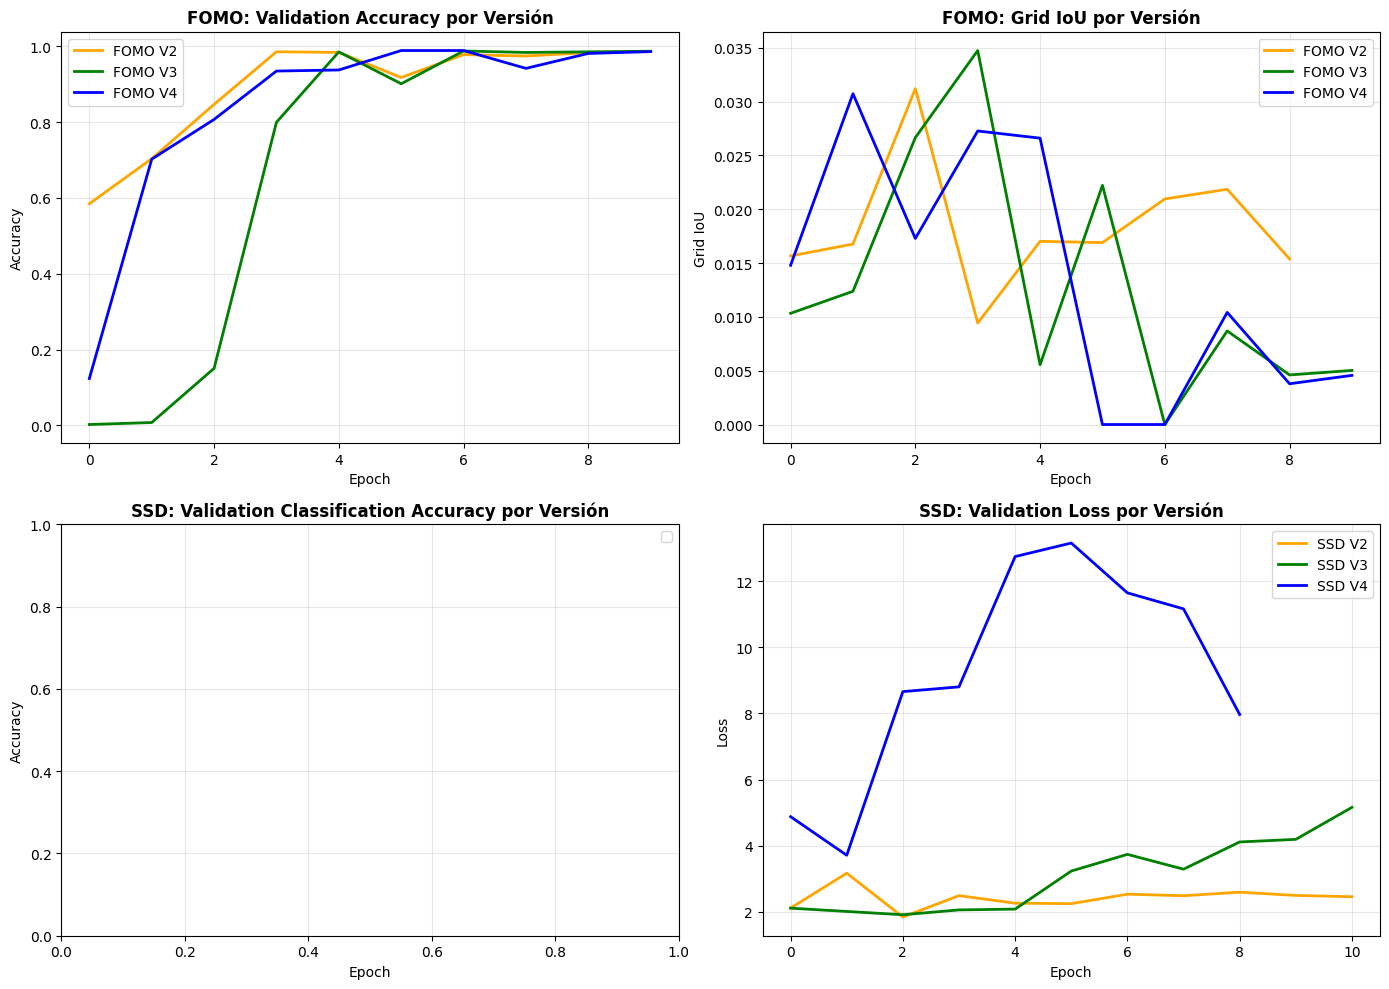


✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/v1_v2_v3_v4_comparison.png


In [18]:
"""
ANÁLISIS COMPARATIVO V1 vs V2 vs V3 vs V4
Genera visualizaciones y tabla resumen de las 4 versiones.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CARGAR HISTORIALES ---
def load_history_safe(path, version):
    """Carga historial si existe, retorna None si no."""
    try:
        df = pd.read_csv(path)
        df['version'] = version
        return df
    except FileNotFoundError:
        print(f"⚠️ No encontrado: {path}")
        return None

# Cargar todos los historiales
fomo_histories = []
ssd_histories = []

for v in ['v1', 'v2', 'v3', 'v4']:
    fomo_path = os.path.join(config.DIRS['logs'], f'fomo_{v}_history.csv')
    ssd_path = os.path.join(config.DIRS['logs'], f'ssd_{v}_history.csv')
    
    fomo_h = load_history_safe(fomo_path, v.upper())
    ssd_h = load_history_safe(ssd_path, v.upper())
    
    if fomo_h is not None:
        fomo_histories.append(fomo_h)
    if ssd_h is not None:
        ssd_histories.append(ssd_h)

# --- GUARDAR HISTORIALES V4 ---
# Guardar el historial de entrenamiento V4 si existe
try:
    hist_fomo_v4_df = pd.DataFrame(hist_fomo_v4.history)
    hist_fomo_v4_df.to_csv(os.path.join(config.DIRS['logs'], 'fomo_v4_history.csv'), index=False)
    print("✅ Historial FOMO V4 guardado")
except NameError:
    print("⚠️ hist_fomo_v4 no disponible")

try:
    hist_ssd_v4_df = pd.DataFrame(hist_ssd_v4.history)
    hist_ssd_v4_df.to_csv(os.path.join(config.DIRS['logs'], 'ssd_v4_history.csv'), index=False)
    print("✅ Historial SSD V4 guardado")
except NameError:
    print("⚠️ hist_ssd_v4 no disponible")

# --- TABLA RESUMEN ---
print("\n" + "="*80)
print("📊 TABLA RESUMEN: EVOLUCIÓN DE MODELOS")
print("="*80)

def get_best_metrics(histories, model_type):
    """Extrae mejores métricas de cada versión."""
    results = []
    for h in histories:
        version = h['version'].iloc[0]
        
        if model_type == 'fomo':
            best_acc = h['val_accuracy'].max() if 'val_accuracy' in h.columns else np.nan
            best_iou = h['val_grid_iou_v2'].max() if 'val_grid_iou_v2' in h.columns else (
                       h['val_grid_iou'].max() if 'val_grid_iou' in h.columns else np.nan)
            best_loss = h['val_loss'].min() if 'val_loss' in h.columns else np.nan
            results.append({
                'Versión': version,
                'Best Val Acc': f"{best_acc*100:.1f}%" if not np.isnan(best_acc) else "N/A",
                'Best Grid IoU': f"{best_iou:.4f}" if not np.isnan(best_iou) else "N/A",
                'Best Val Loss': f"{best_loss:.4f}" if not np.isnan(best_loss) else "N/A"
            })
        else:  # ssd
            best_acc = h['val_classification_accuracy'].max() if 'val_classification_accuracy' in h.columns else np.nan
            best_loss = h['val_loss'].min() if 'val_loss' in h.columns else np.nan
            results.append({
                'Versión': version,
                'Best Val Acc': f"{best_acc*100:.1f}%" if not np.isnan(best_acc) else "N/A",
                'Best Val Loss': f"{best_loss:.4f}" if not np.isnan(best_loss) else "N/A"
            })
    
    return pd.DataFrame(results)

if fomo_histories:
    print("\n🔵 FOMO - Resumen por Versión:")
    fomo_summary = get_best_metrics(fomo_histories, 'fomo')
    print(fomo_summary.to_string(index=False))

if ssd_histories:
    print("\n🟢 MobileNetV2 SSD - Resumen por Versión:")
    ssd_summary = get_best_metrics(ssd_histories, 'ssd')
    print(ssd_summary.to_string(index=False))

# --- TAMAÑO DE MODELOS ---
print("\n" + "="*80)
print("📦 TAMAÑO DE MODELOS (para ESP32-S3 N16R8)")
print("="*80)
print("Límite PSRAM disponible: ~5-6 MB para modelo cuantizado int8")
print()

model_sizes = []
for v in ['v1', 'v2', 'v3', 'v4']:
    for model_type in ['fomo', 'ssd']:
        model_path = os.path.join(config.DIRS['models_final'], f"{model_type}_{v}_model.keras")
        if os.path.exists(model_path):
            size_mb = os.path.getsize(model_path) / (1024 * 1024)
            # Estimación cuantizado: ~25% del original para int8
            size_quant = size_mb * 0.25
            model_sizes.append({
                'Modelo': f"{model_type.upper()} {v.upper()}",
                'Tamaño (MB)': f"{size_mb:.2f}",
                'Est. Cuant. int8 (MB)': f"{size_quant:.2f}",
                'Compatible ESP32': "✅" if size_quant < 5.0 else "❌"
            })

if model_sizes:
    sizes_df = pd.DataFrame(model_sizes)
    print(sizes_df.to_string(index=False))

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: FOMO Accuracy
ax1 = axes[0, 0]
colors = {'V1': 'red', 'V2': 'orange', 'V3': 'green', 'V4': 'blue'}
for h in fomo_histories:
    v = h['version'].iloc[0]
    if 'val_accuracy' in h.columns:
        ax1.plot(h['val_accuracy'], label=f'FOMO {v}', color=colors.get(v, 'gray'), linewidth=2)
ax1.set_title('FOMO: Validation Accuracy por Versión', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: FOMO Grid IoU
ax2 = axes[0, 1]
for h in fomo_histories:
    v = h['version'].iloc[0]
    iou_col = 'val_grid_iou_v2' if 'val_grid_iou_v2' in h.columns else 'val_grid_iou'
    if iou_col in h.columns:
        ax2.plot(h[iou_col], label=f'FOMO {v}', color=colors.get(v, 'gray'), linewidth=2)
ax2.set_title('FOMO: Grid IoU por Versión', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Grid IoU')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: SSD Accuracy
ax3 = axes[1, 0]
for h in ssd_histories:
    v = h['version'].iloc[0]
    if 'val_classification_accuracy' in h.columns:
        ax3.plot(h['val_classification_accuracy'], label=f'SSD {v}', color=colors.get(v, 'gray'), linewidth=2)
ax3.set_title('SSD: Validation Classification Accuracy por Versión', fontsize=12, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: SSD Loss
ax4 = axes[1, 1]
for h in ssd_histories:
    v = h['version'].iloc[0]
    if 'val_loss' in h.columns:
        ax4.plot(h['val_loss'], label=f'SSD {v}', color=colors.get(v, 'gray'), linewidth=2)
ax4.set_title('SSD: Validation Loss por Versión', fontsize=12, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.DIRS['visuals'], 'v1_v2_v3_v4_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico guardado en: {config.DIRS['visuals']}/v1_v2_v3_v4_comparison.png")

## Ciclo A - Versión 5 (SSD Exclusivo)

### 📋 Diagnóstico de V4 y Mejoras para V5

**Problemas identificados en SSD V4:**
1. ❌ Loss de bbox domina (weight=5.0) → gradientes explotan
2. ❌ Val loss diverge (3.7 → 13.1 → 7.9) = gradient explosion
3. ❌ Accuracy cae de 45.9% a 31%

**Cambios en V5:**
| Aspecto | V4 | V5 |
|---------|----|----|
| Loss weights | `class: 1.0, bbox: 5.0` | `class: 1.0, bbox: 1.0` |
| Optimizer | Adam(lr=0.001) | Adam(lr=0.0005, clipnorm=1.0) |
| Bbox loss | Huber | SmoothL1 + máscara mejorada |
| Regularización | L2=0.0005 | L2=0.001 + más Dropout |
| Épocas | 50 | 80 (más tiempo para converger) |

**Nota:** Mantenemos alpha=0.50 porque el tamaño (~2.7 MB cuantizado) es aceptable.

### Arquitectura MobileNetV2 SSD V5

In [19]:
"""
ARQUITECTURA MOBILENET V2 SSD V5 (Corrección de Gradient Explosion)
Cambios respecto a V4:
  1. Mantiene alpha=0.50 (tamaño OK para ESP32)
  2. L2 regularización: 0.0005 → 0.001 (más restrictivo)
  3. Dropout incrementado: 0.3/0.2 → 0.4/0.3
  4. BatchNorm después de cada Dense
  5. Arquitectura idéntica, mejor regularización
"""

def build_mobilenet_ssd_v5(input_shape=(224, 224, 3), num_classes=4, max_objects=3, alpha=0.50):
    """
    Construye un modelo MobileNetV2 SSD V5 con mejor regularización.
    
    CAMBIOS PRINCIPALES:
    - L2 más fuerte (0.001) para estabilidad
    - Más Dropout para evitar overfitting
    - BatchNorm en Dense layers
    """
    # Regularizador L2 más fuerte
    l2_reg = tf.keras.regularizers.l2(0.001)  # type: ignore
    
    # Base MobileNetV2 (mantiene alpha=0.50)
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha,
        include_top=False, 
        weights='imagenet'
    )
    
    x = base_model.output
    
    # Feature refinement
    x = tf.keras.layers.Conv2D(128, (1, 1), padding='same', use_bias=False)(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.ReLU()(x)  # type: ignore
    
    # GlobalAveragePooling
    x = tf.keras.layers.GlobalAveragePooling2D()(x)  # type: ignore
    
    # Dense layers con BatchNorm
    x = tf.keras.layers.Dropout(0.4)(x)  # type: ignore  # 0.4 vs 0.3
    x = tf.keras.layers.Dense(128, use_bias=False, kernel_regularizer=l2_reg)(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.ReLU()(x)  # type: ignore
    
    x = tf.keras.layers.Dropout(0.3)(x)  # type: ignore  # 0.3 vs 0.2
    x = tf.keras.layers.Dense(64, use_bias=False, kernel_regularizer=l2_reg)(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.ReLU()(x)  # type: ignore
    
    # Cabezales de salida (Softmax para clasificación)
    class_logits = tf.keras.layers.Dense(max_objects * num_classes, kernel_regularizer=l2_reg)(x)  # type: ignore
    class_logits = tf.keras.layers.Reshape((max_objects, num_classes))(class_logits)  # type: ignore
    class_output = tf.keras.layers.Softmax(axis=-1, name='class_out')(class_logits)  # type: ignore
    
    # Bbox output con sigmoid (coords normalizadas 0-1)
    bbox_output = tf.keras.layers.Dense(max_objects * 4, activation='sigmoid', kernel_regularizer=l2_reg)(x)  # type: ignore
    bbox_output = tf.keras.layers.Reshape((max_objects, 4), name='bbox_out')(bbox_output)  # type: ignore
    
    model = tf.keras.Model(
        inputs=base_model.input, 
        outputs=[class_output, bbox_output], 
        name="MobileNetV2_SSD_V5_ESP32"
    )  # type: ignore
    
    return model

# Instanciar y verificar
ssd_v5_model = build_mobilenet_ssd_v5(num_classes=4, max_objects=MAX_OBJECTS_SSD, alpha=0.50)
ssd_v5_model.summary()

# Calcular tamaño
total_params_ssd_v5 = ssd_v5_model.count_params()
size_mb_ssd_v5 = total_params_ssd_v5 * 4 / (1024 * 1024)
size_kb_quantized_ssd_v5 = total_params_ssd_v5 / 1024

print(f"\n🧠 Análisis SSD V5:")
print(f"• Total parámetros: {total_params_ssd_v5:,}")
print(f"• Tamaño (float32): {size_mb_ssd_v5:.2f} MB")
print(f"• Tamaño (int8 quantized): {size_kb_quantized_ssd_v5:.1f} KB (~{size_kb_quantized_ssd_v5/1024:.2f} MB)")
print(f"• Compatible ESP32-S3 PSRAM (~5 MB): {'✅' if size_kb_quantized_ssd_v5 < 5000 else '❌'}")

Model: "MobileNetV2_SSD_V5_ESP32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 897,480 (3.42 MB)

 Trainable params: 878,296 (3.35 MB)

 Non-trainable params: 19,184 (74.94 KB)


🧠 Análisis SSD V5:
• Total parámetros: 897,480
• Tamaño (float32): 3.42 MB
• Tamaño (int8 quantized): 876.4 KB (~0.86 MB)
• Compatible ESP32-S3 PSRAM (~5 MB): ✅


### Loss Functions y Compilación SSD V5

**Correcciones clave:**
1. `loss_weights`: bbox de 5.0 → 1.0 (igualar importancia)
2. `clipnorm=1.0`: Previene gradient explosion
3. `learning_rate`: 0.001 → 0.0005 (más conservador)
4. Máscara mejorada en classification loss

In [20]:
"""
LOSS FUNCTIONS Y COMPILACIÓN SSD V5
Correcciones para evitar gradient explosion:
  1. Loss weights balanceados (1.0 : 1.0)
  2. Gradient clipping (clipnorm=1.0)
  3. Learning rate reducido (0.0005)
  4. Máscara mejorada para objetos válidos
"""

# --- CLASSIFICATION LOSS V5 (Mejorada) ---
def masked_classification_loss_v5(y_true, y_pred):
    """
    Cross-entropy con máscara para objetos válidos.
    Solo calcula loss donde hay objetos reales (suma de one-hot > 0).
    """
    # y_true shape: (batch, max_objects, num_classes)
    # Máscara: 1 si hay objeto (alguna clase activa), 0 si es padding
    valid_mask = tf.reduce_sum(y_true, axis=-1)  # (batch, max_objects)
    valid_mask = tf.cast(valid_mask > 0.5, tf.float32)
    
    # Clip predictions para estabilidad numérica
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    
    # Cross-entropy por objeto
    ce_loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)  # (batch, max_objects)
    
    # Aplicar máscara
    masked_loss = ce_loss * valid_mask
    
    # Promedio sobre objetos válidos (evitar div by zero)
    num_valid = tf.reduce_sum(valid_mask) + 1e-7
    return tf.reduce_sum(masked_loss) / num_valid

# --- BBOX LOSS V5 (Smooth L1 con máscara) ---
def masked_bbox_loss_v5(y_true, y_pred):
    """
    Smooth L1 Loss (menos sensible a outliers que MSE/Huber).
    Solo calcula loss donde hay bboxes reales.
    """
    # y_true shape: (batch, max_objects, 4)
    # Máscara: 1 si coords no son cero, 0 si es padding
    valid_mask = tf.reduce_max(tf.abs(y_true), axis=-1)  # (batch, max_objects)
    valid_mask = tf.cast(valid_mask > 0.001, tf.float32)
    
    # Smooth L1 Loss
    diff = tf.abs(y_true - y_pred)
    smooth_l1 = tf.where(diff < 1.0, 0.5 * diff ** 2, diff - 0.5)
    
    # Promedio por coordenada
    box_loss = tf.reduce_mean(smooth_l1, axis=-1)  # (batch, max_objects)
    
    # Aplicar máscara
    masked_loss = box_loss * valid_mask
    
    # Promedio sobre objetos válidos
    num_valid = tf.reduce_sum(valid_mask) + 1e-7
    return tf.reduce_sum(masked_loss) / num_valid

# --- COMPILAR SSD V5 ---
# CORRECCIÓN CLAVE: Gradient clipping y loss weights balanceados
optimizer_v5 = tf.keras.optimizers.Adam(
    learning_rate=0.0005,  # Reducido de 0.001
    clipnorm=1.0  # Gradient clipping
)

ssd_v5_model.compile(
    optimizer=optimizer_v5,
    loss={
        'class_out': masked_classification_loss_v5,
        'bbox_out': masked_bbox_loss_v5
    },
    loss_weights={
        'class_out': 1.0, 
        'bbox_out': 1.0  # CAMBIO: De 5.0 a 1.0
    },
    metrics={'class_out': 'accuracy'}
)

print("🚦 Modelo SSD V5 compilado con correcciones anti-gradient explosion:")
print("   📐 Loss weights: class=1.0, bbox=1.0 (balanceados)")
print("   📐 Optimizer: Adam(lr=0.0005, clipnorm=1.0)")
print("   📐 Loss functions: Masked CrossEntropy + Smooth L1")

🚦 Modelo SSD V5 compilado con correcciones anti-gradient explosion:
   📐 Loss weights: class=1.0, bbox=1.0 (balanceados)
   📐 Optimizer: Adam(lr=0.0005, clipnorm=1.0)
   📐 Loss functions: Masked CrossEntropy + Smooth L1


### Callbacks y Entrenamiento SSD V5

In [21]:
"""
CALLBACKS Y ENTRENAMIENTO SSD V5
Configuración de entrenamiento más conservadora y robusta.
"""

# --- CALLBACKS V5 ---
def create_callbacks_v5(model_name, monitor='val_loss', mode='min', patience_early=10, patience_lr=5):
    """
    Callbacks V5 con más paciencia para convergencia lenta pero estable.
    """
    callbacks = [
        # Guardar mejor modelo
        ModelCheckpoint(
            filepath=os.path.join(config.DIRS['models_chk'], f"{model_name}_best.keras"),
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=1
        ),
        
        # Early Stopping con más paciencia (permite convergencia lenta)
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=patience_early,  # 10 vs 8 en V4
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce LR on Plateau
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,
            patience=patience_lr,  # 5 vs 4 en V4
            min_lr=1e-7,
            verbose=1
        ),
        
        # TensorBoard
        TensorBoard(
            log_dir=os.path.join(config.DIRS['logs'], model_name),
            histogram_freq=1,
            write_graph=True
        ),
        
        # CSV Logger
        CSVLogger(
            os.path.join(config.DIRS['logs'], f"{model_name}_history.csv"),
            separator=',',
            append=False
        )
    ]
    
    print(f"✅ Callbacks V5 configurados para '{model_name}'")
    return callbacks

ssd_v5_callbacks = create_callbacks_v5(
    'ssd_v5', 
    monitor='val_class_out_accuracy',  # Monitorear accuracy de clasificación
    mode='max',
    patience_early=10,
    patience_lr=5
)

# --- ENTRENAR SSD V5 ---
print("\n" + "="*60)
print("🚀 ENTRENANDO MobileNetV2 SSD V5")
print("="*60)
print("Cambios respecto a V4:")
print("  • Loss weights balanceados (1:1)")
print("  • Gradient clipping (clipnorm=1.0)")
print("  • Learning rate reducido (0.0005)")
print("  • Más épocas (80) con más paciencia (10)")
print("="*60)

hist_ssd_v5 = ssd_v5_model.fit(
    train_gen_ssd,  # Generador SSD existente
    validation_data=val_gen_ssd,
    epochs=80,  # Más épocas para convergencia lenta
    callbacks=ssd_v5_callbacks,
    verbose=1
)

# Guardar modelo final
ssd_v5_model.save(os.path.join(config.DIRS['models_final'], "ssd_v5_model.keras"))
print(f"\n✅ Modelo SSD V5 guardado en: {config.DIRS['models_final']}/ssd_v5_model.keras")

# Guardar historial
hist_ssd_v5_df = pd.DataFrame(hist_ssd_v5.history)
hist_ssd_v5_df.to_csv(os.path.join(config.DIRS['logs'], 'ssd_v5_history.csv'), index=False)
print(f"✅ Historial guardado en: {config.DIRS['logs']}/ssd_v5_history.csv")

✅ Callbacks V5 configurados para 'ssd_v5'

🚀 ENTRENANDO MobileNetV2 SSD V5
Cambios respecto a V4:
  • Loss weights balanceados (1:1)
  • Gradient clipping (clipnorm=1.0)
  • Learning rate reducido (0.0005)
  • Más épocas (80) con más paciencia (10)
Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - bbox_out_loss: 0.0409 - class_out_accuracy: 0.3427 - class_out_loss: 1.4117 - loss: 1.7045
Epoch 1: val_class_out_accuracy improved from None to 0.44314, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_v5_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 307s 6s/step - bbox_out_loss: 0.0391 - class_out_accuracy: 0.3613 - class_out_loss: 1.3335 - loss: 1.6230 - val_bbox_out_loss: 0.0322 - val_class_out_accuracy: 0.4431 - val_class_out_loss: 1.0978 - val_loss: 1.3957 - learning_rate: 5.0000e-04
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_out_loss: 0.0361 - class_out_accuracy: 0.4105 - class_out_loss: 1.0878 - loss: 1.3700
Epoch 2: val_class_out_accuracy im

### 📊 Análisis de Resultados SSD V5

✅ Cargado: ssd_v1_history.csv (14 epochs)
✅ Cargado: ssd_v2_history.csv (11 epochs)
✅ Cargado: ssd_v3_history.csv (11 epochs)
✅ Cargado: ssd_v4_history.csv (9 epochs)
✅ Cargado: ssd_v5_history.csv (12 epochs)

📊 COMPARATIVA SSD: V2 vs V3 vs V4 vs V5
Versión Best Val Acc Final Val Acc Best Val Loss  Epochs
 SSD V1        49.0%         31.0%         0.671      14
 SSD V2        47.5%         45.1%         1.843      11
 SSD V3        52.5%         40.8%         1.912      11
 SSD V4        45.9%         31.0%         3.711       9
 SSD V5        45.9%         42.7%         1.028      12

📦 TAMAÑO DE MODELOS SSD
Modelo Tamaño (MB) Est. int8 (MB) ESP32 OK
SSD V2      114.13          28.53        ❌
SSD V3        6.25           1.56        ✅
SSD V4       10.82           2.71        ✅
SSD V5       10.84           2.71        ✅


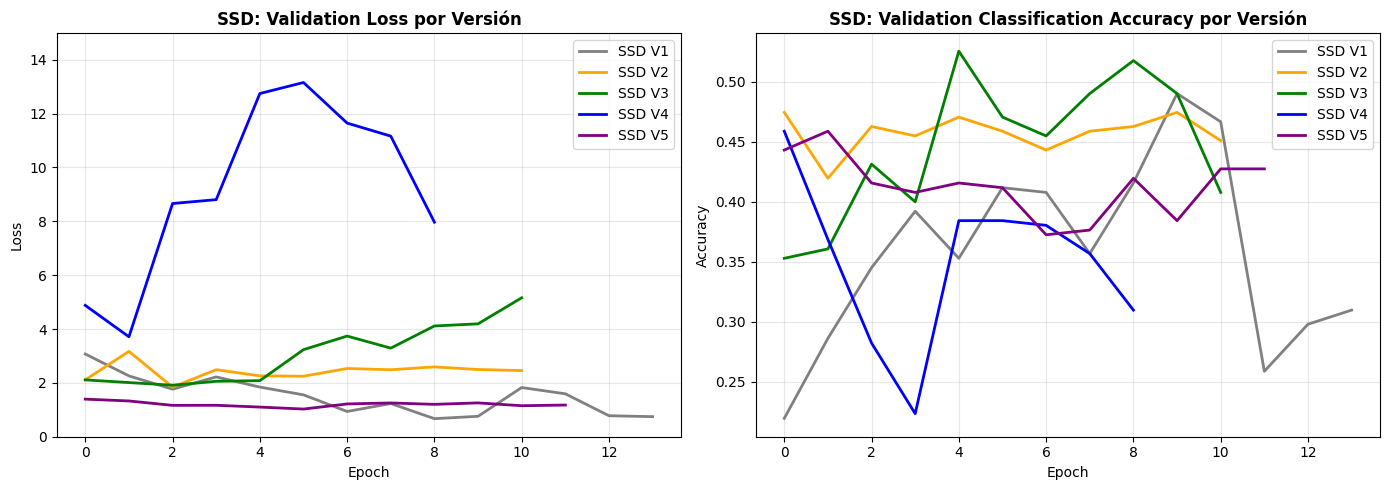


✅ Gráfico guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/ssd_v2_v3_v4_v5_comparison.png

🔍 DIAGNÓSTICO SSD V5
✅ Loss CONVERGENTE: 1.296 → 1.195
📈 Accuracy: 43.9% → 41.3%


In [22]:
"""
ANÁLISIS DE RESULTADOS SSD V5
Comparación con versiones anteriores y diagnóstico de convergencia.
"""

import pandas as pd
import matplotlib.pyplot as plt

# --- CARGAR HISTORIALES SSD ---
ssd_versions = {}
for v in ['v1', 'v2', 'v3', 'v4', 'v5']:
    path = os.path.join(config.DIRS['logs'], f'ssd_{v}_history.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['version'] = v.upper()
        ssd_versions[v.upper()] = df
        print(f"✅ Cargado: ssd_{v}_history.csv ({len(df)} epochs)")
    else:
        print(f"⚠️ No encontrado: {path}")

# --- TABLA COMPARATIVA ---
print("\n" + "="*70)
print("📊 COMPARATIVA SSD: V2 vs V3 vs V4 vs V5")
print("="*70)

comparison_data = []
for version, df in ssd_versions.items():
    # Buscar columna de accuracy (puede variar el nombre)
    acc_col = None
    for col in ['val_class_out_accuracy', 'val_classification_accuracy', 'val_accuracy']:
        if col in df.columns:
            acc_col = col
            break
    
    best_acc = df[acc_col].max() * 100 if acc_col and acc_col in df.columns else float('nan')
    best_loss = df['val_loss'].min() if 'val_loss' in df.columns else float('nan')
    final_acc = df[acc_col].iloc[-1] * 100 if acc_col and acc_col in df.columns else float('nan')
    epochs_trained = len(df)
    
    comparison_data.append({
        'Versión': f'SSD {version}',
        'Best Val Acc': f"{best_acc:.1f}%",
        'Final Val Acc': f"{final_acc:.1f}%",
        'Best Val Loss': f"{best_loss:.3f}",
        'Epochs': epochs_trained
    })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

# --- TAMAÑO DE MODELOS SSD ---
print("\n" + "="*70)
print("📦 TAMAÑO DE MODELOS SSD")
print("="*70)

ssd_sizes = []
for v in ['v2', 'v3', 'v4', 'v5']:
    model_path = os.path.join(config.DIRS['models_final'], f"ssd_{v}_model.keras")
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / (1024 * 1024)
        size_quant = size_mb * 0.25  # Estimación int8
        ssd_sizes.append({
            'Modelo': f'SSD {v.upper()}',
            'Tamaño (MB)': f"{size_mb:.2f}",
            'Est. int8 (MB)': f"{size_quant:.2f}",
            'ESP32 OK': '✅' if size_quant < 5.0 else '❌'
        })

if ssd_sizes:
    sizes_df = pd.DataFrame(ssd_sizes)
    print(sizes_df.to_string(index=False))

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'V2': 'orange', 'V3': 'green', 'V4': 'blue', 'V5': 'purple'}

# Plot 1: Val Loss
ax1 = axes[0]
for version, df in ssd_versions.items():
    if 'val_loss' in df.columns:
        ax1.plot(df['val_loss'], label=f'SSD {version}', color=colors.get(version, 'gray'), linewidth=2)
ax1.set_title('SSD: Validation Loss por Versión', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 15)  # Limitar eje Y para ver tendencias

# Plot 2: Val Accuracy
ax2 = axes[1]
for version, df in ssd_versions.items():
    acc_col = None
    for col in ['val_class_out_accuracy', 'val_classification_accuracy']:
        if col in df.columns:
            acc_col = col
            break
    if acc_col:
        ax2.plot(df[acc_col], label=f'SSD {version}', color=colors.get(version, 'gray'), linewidth=2)
ax2.set_title('SSD: Validation Classification Accuracy por Versión', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.DIRS['visuals'], 'ssd_v2_v3_v4_v5_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico guardado: {config.DIRS['visuals']}/ssd_v2_v3_v4_v5_comparison.png")

# --- DIAGNÓSTICO V5 ---
if 'V5' in ssd_versions:
    v5_df = ssd_versions['V5']
    print("\n" + "="*70)
    print("🔍 DIAGNÓSTICO SSD V5")
    print("="*70)
    
    # Verificar si loss convergió o divergió
    if len(v5_df) >= 3:
        loss_inicio = v5_df['val_loss'].iloc[:3].mean()
        loss_final = v5_df['val_loss'].iloc[-3:].mean()
        
        if loss_final < loss_inicio:
            print(f"✅ Loss CONVERGENTE: {loss_inicio:.3f} → {loss_final:.3f}")
        else:
            print(f"⚠️ Loss DIVERGENTE: {loss_inicio:.3f} → {loss_final:.3f}")
        
        # Tendencia de accuracy
        acc_col = 'val_class_out_accuracy' if 'val_class_out_accuracy' in v5_df.columns else None
        if acc_col:
            acc_inicio = v5_df[acc_col].iloc[:3].mean() * 100
            acc_final = v5_df[acc_col].iloc[-3:].mean() * 100
            print(f"📈 Accuracy: {acc_inicio:.1f}% → {acc_final:.1f}%")

## Ciclo A - Versión 6 (SSD con MAX_OBJECTS=2)

### 📋 Consolidación de Mejores Prácticas V1-V5

**Objetivo**: Probar si reducir `MAX_OBJECTS` de 3 → 2 mejora la accuracy al reducir el ruido de padding.

| Aspecto | Origen | Valor V6 |
|---------|--------|----------|
| `MAX_OBJECTS` | **Nuevo** | **2** (vs 3) |
| `alpha` | V4/V5 | 0.50 |
| Pooling | V3 | GlobalAveragePooling |
| Dense layers | V5 | 128→64 con BatchNorm |
| Regularización | V5 | L2=0.001, Dropout 0.4/0.3 |
| Loss weights | V5 | 1:1 (balanceados) |
| Optimizer | V5 | Adam(lr=0.0005, clipnorm=1.0) |
| Bbox loss | V5 | Smooth L1 con máscara |
| Epochs | V5 | 80 con patience=10 |

**Hipótesis**: Con menos slots de padding, el modelo debería aprender patrones más limpios.

### Generador de Datos V6 (MAX_OBJECTS=2)

In [26]:
"""
GENERADOR DE DATOS SSD V6 (MAX_OBJECTS = 2)
Cambio principal: Reducir slots de 3 a 2 para menos ruido de padding.
"""

MAX_OBJECTS_V6 = 2  # CAMBIO: 3 → 2

class DualModelGeneratorV6(tf.keras.utils.Sequence):  # pyright: ignore[reportAttributeAccessIssue]
    """
    Generador V6 para SSD con MAX_OBJECTS=2.
    Selecciona los 2 objetos más grandes por área.
    """
    def __init__(self, image_dir, label_dir, batch_size, img_size, max_objects=2):
        super().__init__()  # Requerido por Keras 3.x
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
        self.label_dir = label_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.max_objects = max_objects  # 2 para V6
        
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size : (idx+1) * self.batch_size]
        
        batch_images = []
        batch_targets_class = []
        batch_targets_bbox = []
        
        for img_path in batch_paths:
            # 1. Procesar Imagen
            img = cv2.imread(img_path)
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            batch_images.append(img.astype(np.float32) / 255.0)
            
            # 2. Leer Labels (.txt)
            txt_name = os.path.basename(img_path).replace('.jpg', '.txt')
            txt_path = os.path.join(self.label_dir, txt_name)
            
            # Arrays de salida: MAX_OBJECTS=2 slots
            ssd_classes = np.zeros((self.max_objects, 4), dtype=np.float32)
            ssd_bboxes = np.zeros((self.max_objects, 4), dtype=np.float32)
            
            objects_found = []
            
            if os.path.exists(txt_path):
                with open(txt_path, 'r') as f:
                    lines = f.readlines()
                    
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls, xc, yc, w, h = map(float, parts[:5])
                        cls = int(cls)
                        area = w * h
                        objects_found.append((area, cls, xc, yc, w, h))
                
                # Ordenar por área (más grandes primero) y tomar top 2
                objects_found.sort(key=lambda x: x[0], reverse=True)
                
                for i, obj in enumerate(objects_found[:self.max_objects]):
                    _, cls, xc, yc, w, h = obj
                    if cls < 4:
                        ssd_classes[i, cls] = 1.0
                    ssd_bboxes[i] = [xc, yc, w, h]

            batch_targets_class.append(ssd_classes)
            batch_targets_bbox.append(ssd_bboxes)

        batch_images = np.array(batch_images)
        
        return batch_images, {
            'class_out': np.array(batch_targets_class),
            'bbox_out': np.array(batch_targets_bbox)
        }

# --- CREAR GENERADORES V6 ---
print("🔧 Creando generadores SSD V6 (MAX_OBJECTS=2)...")
train_gen_ssd_v6 = DualModelGeneratorV6(train_img_dir, train_lbl_dir, 32, 224, max_objects=2)
val_gen_ssd_v6 = DualModelGeneratorV6(val_img_dir, val_lbl_dir, 32, 224, max_objects=2)

# Verificar shapes
sample_x, sample_y = train_gen_ssd_v6[0]
print(f"✅ Generadores V6 creados:")
print(f"   📐 Input shape: {sample_x.shape}")
print(f"   📐 class_out shape: {sample_y['class_out'].shape}  (batch, 2, 4)")
print(f"   📐 bbox_out shape: {sample_y['bbox_out'].shape}  (batch, 2, 4)")

🔧 Creando generadores SSD V6 (MAX_OBJECTS=2)...
✅ Generadores V6 creados:
   📐 Input shape: (32, 224, 224, 3)
   📐 class_out shape: (32, 2, 4)  (batch, 2, 4)
   📐 bbox_out shape: (32, 2, 4)  (batch, 2, 4)


### Arquitectura MobileNetV2 SSD V6

In [27]:
"""
ARQUITECTURA MOBILENET V2 SSD V6 (MAX_OBJECTS=2)
Consolidación de mejores prácticas de V1-V5:
  - alpha=0.50 (de V4/V5)
  - GAP (de V3)
  - BatchNorm en Dense (de V5)
  - L2=0.001, Dropout 0.4/0.3 (de V5)
  - MAX_OBJECTS=2 (NUEVO)
"""

def build_mobilenet_ssd_v6(input_shape=(224, 224, 3), num_classes=4, max_objects=2, alpha=0.50):
    """
    MobileNetV2 SSD V6 - Versión final optimizada.
    
    Args:
        max_objects: 2 (reducido de 3 para menos padding noise)
        alpha: 0.50 (balance entre capacidad y tamaño)
    """
    l2_reg = tf.keras.regularizers.l2(0.001)  # type: ignore
    
    # Base MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(  # type: ignore
        input_shape=input_shape, 
        alpha=alpha,
        include_top=False, 
        weights='imagenet'
    )
    
    x = base_model.output
    
    # Feature refinement con BatchNorm
    x = tf.keras.layers.Conv2D(128, (1, 1), padding='same', use_bias=False)(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.ReLU()(x)  # type: ignore
    
    # GlobalAveragePooling (mejor que Flatten para generalización)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)  # type: ignore
    
    # Dense layers con BatchNorm (de V5)
    x = tf.keras.layers.Dropout(0.4)(x)  # type: ignore
    x = tf.keras.layers.Dense(128, use_bias=False, kernel_regularizer=l2_reg)(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.ReLU()(x)  # type: ignore
    
    x = tf.keras.layers.Dropout(0.3)(x)  # type: ignore
    x = tf.keras.layers.Dense(64, use_bias=False, kernel_regularizer=l2_reg)(x)  # type: ignore
    x = tf.keras.layers.BatchNormalization()(x)  # type: ignore
    x = tf.keras.layers.ReLU()(x)  # type: ignore
    
    # Cabezales de salida (MAX_OBJECTS=2)
    # Classification: (batch, 2, 4) - Softmax
    class_logits = tf.keras.layers.Dense(max_objects * num_classes, kernel_regularizer=l2_reg)(x)  # type: ignore
    class_logits = tf.keras.layers.Reshape((max_objects, num_classes))(class_logits)  # type: ignore
    class_output = tf.keras.layers.Softmax(axis=-1, name='class_out')(class_logits)  # type: ignore
    
    # Bbox: (batch, 2, 4) - Sigmoid para coords normalizadas
    bbox_output = tf.keras.layers.Dense(max_objects * 4, activation='sigmoid', kernel_regularizer=l2_reg)(x)  # type: ignore
    bbox_output = tf.keras.layers.Reshape((max_objects, 4), name='bbox_out')(bbox_output)  # type: ignore
    
    model = tf.keras.Model(
        inputs=base_model.input, 
        outputs=[class_output, bbox_output], 
        name="MobileNetV2_SSD_V6_ESP32"
    )  # type: ignore
    
    return model

# Instanciar modelo V6
ssd_v6_model = build_mobilenet_ssd_v6(num_classes=4, max_objects=MAX_OBJECTS_V6, alpha=0.50)
ssd_v6_model.summary()

# Calcular tamaño
total_params_ssd_v6 = ssd_v6_model.count_params()
size_mb_ssd_v6 = total_params_ssd_v6 * 4 / (1024 * 1024)
size_kb_quantized_ssd_v6 = total_params_ssd_v6 / 1024

print(f"\n🧠 Análisis SSD V6:")
print(f"• MAX_OBJECTS: {MAX_OBJECTS_V6} (vs 3 en V1-V5)")
print(f"• Total parámetros: {total_params_ssd_v6:,}")
print(f"• Tamaño (float32): {size_mb_ssd_v6:.2f} MB")
print(f"• Tamaño (int8 quantized): {size_kb_quantized_ssd_v6:.1f} KB (~{size_kb_quantized_ssd_v6/1024:.2f} MB)")
print(f"• Compatible ESP32-S3: {'✅' if size_kb_quantized_ssd_v6 < 5000 else '❌'}")

# Comparar con V5
print(f"\n📊 Comparación V5 vs V6:")
print(f"• V5 output shape: (batch, 3, 4) + (batch, 3, 4) = 24 valores/muestra")
print(f"• V6 output shape: (batch, 2, 4) + (batch, 2, 4) = 16 valores/muestra")
print(f"• Reducción de outputs: 33%")

Model: "MobileNetV2_SSD_V6_ESP32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 896,960 (3.42 MB)

 Trainable params: 877,776 (3.35 MB)

 Non-trainable params: 19,184 (74.94 KB)


🧠 Análisis SSD V6:
• MAX_OBJECTS: 2 (vs 3 en V1-V5)
• Total parámetros: 896,960
• Tamaño (float32): 3.42 MB
• Tamaño (int8 quantized): 875.9 KB (~0.86 MB)
• Compatible ESP32-S3: ✅

📊 Comparación V5 vs V6:
• V5 output shape: (batch, 3, 4) + (batch, 3, 4) = 24 valores/muestra
• V6 output shape: (batch, 2, 4) + (batch, 2, 4) = 16 valores/muestra
• Reducción de outputs: 33%


### Compilación y Entrenamiento SSD V6

In [28]:
"""
COMPILACIÓN Y ENTRENAMIENTO SSD V6
Usa la misma configuración de V5 (que funcionó bien para estabilidad).
"""

# --- LOSS FUNCTIONS V6 (mismas que V5) ---
def masked_classification_loss_v6(y_true, y_pred):
    """Cross-entropy con máscara para objetos válidos."""
    valid_mask = tf.reduce_sum(y_true, axis=-1)
    valid_mask = tf.cast(valid_mask > 0.5, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    ce_loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    masked_loss = ce_loss * valid_mask
    num_valid = tf.reduce_sum(valid_mask) + 1e-7
    return tf.reduce_sum(masked_loss) / num_valid

def masked_bbox_loss_v6(y_true, y_pred):
    """Smooth L1 Loss con máscara."""
    valid_mask = tf.reduce_max(tf.abs(y_true), axis=-1)
    valid_mask = tf.cast(valid_mask > 0.001, tf.float32)
    diff = tf.abs(y_true - y_pred)
    smooth_l1 = tf.where(diff < 1.0, 0.5 * diff ** 2, diff - 0.5)
    box_loss = tf.reduce_mean(smooth_l1, axis=-1)
    masked_loss = box_loss * valid_mask
    num_valid = tf.reduce_sum(valid_mask) + 1e-7
    return tf.reduce_sum(masked_loss) / num_valid

# --- COMPILAR SSD V6 ---
optimizer_v6 = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

ssd_v6_model.compile(
    optimizer=optimizer_v6,
    loss={
        'class_out': masked_classification_loss_v6,
        'bbox_out': masked_bbox_loss_v6
    },
    loss_weights={'class_out': 1.0, 'bbox_out': 1.0},
    metrics={'class_out': 'accuracy'}
)

print("🚦 Modelo SSD V6 compilado:")
print("   📐 MAX_OBJECTS: 2 (vs 3 en V5)")
print("   📐 Loss weights: 1:1 (balanceados)")
print("   📐 Optimizer: Adam(lr=0.0005, clipnorm=1.0)")

# --- CALLBACKS V6 ---
def create_callbacks_v6(model_name, monitor='val_loss', mode='min', patience_early=10, patience_lr=5):
    """Callbacks robustos para entrenamiento estable."""
    callbacks = [
        ModelCheckpoint(
            filepath=os.path.join(config.DIRS['models_chk'], f"{model_name}_best.keras"),
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=patience_early,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        ),
        TensorBoard(
            log_dir=os.path.join(config.DIRS['logs'], model_name),
            histogram_freq=1,
            write_graph=True
        ),
        CSVLogger(
            os.path.join(config.DIRS['logs'], f"{model_name}_history.csv"),
            separator=',',
            append=False
        )
    ]
    print(f"✅ Callbacks V6 configurados para '{model_name}'")
    return callbacks

ssd_v6_callbacks = create_callbacks_v6(
    'ssd_v6', 
    monitor='val_class_out_accuracy',
    mode='max',
    patience_early=10,
    patience_lr=5
)

# --- ENTRENAR SSD V6 ---
print("\n" + "="*60)
print("🚀 ENTRENANDO MobileNetV2 SSD V6 (MAX_OBJECTS=2)")
print("="*60)
print("Cambios respecto a V5:")
print("  • MAX_OBJECTS: 3 → 2")
print("  • Menos padding noise")
print("  • Misma arquitectura y hiperparámetros")
print("="*60)

hist_ssd_v6 = ssd_v6_model.fit(
    train_gen_ssd_v6,  # Generador V6 con MAX_OBJECTS=2
    validation_data=val_gen_ssd_v6,
    epochs=80,
    callbacks=ssd_v6_callbacks,
    verbose=1
)

# Guardar modelo final
ssd_v6_model.save(os.path.join(config.DIRS['models_final'], "ssd_v6_model.keras"))
print(f"\n✅ Modelo SSD V6 guardado en: {config.DIRS['models_final']}/ssd_v6_model.keras")

# Guardar historial
hist_ssd_v6_df = pd.DataFrame(hist_ssd_v6.history)
hist_ssd_v6_df.to_csv(os.path.join(config.DIRS['logs'], 'ssd_v6_history.csv'), index=False)
print(f"✅ Historial guardado en: {config.DIRS['logs']}/ssd_v6_history.csv")

🚦 Modelo SSD V6 compilado:
   📐 MAX_OBJECTS: 2 (vs 3 en V5)
   📐 Loss weights: 1:1 (balanceados)
   📐 Optimizer: Adam(lr=0.0005, clipnorm=1.0)
✅ Callbacks V6 configurados para 'ssd_v6'

🚀 ENTRENANDO MobileNetV2 SSD V6 (MAX_OBJECTS=2)
Cambios respecto a V5:
  • MAX_OBJECTS: 3 → 2
  • Menos padding noise
  • Misma arquitectura y hiperparámetros
Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - bbox_out_loss: 0.0472 - class_out_accuracy: 0.3850 - class_out_loss: 1.4394 - loss: 1.7226 
Epoch 1: val_class_out_accuracy improved from None to 0.46471, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_v6_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 1257s 29s/step - bbox_out_loss: 0.0452 - class_out_accuracy: 0.4084 - class_out_loss: 1.3398 - loss: 1.6185 - val_bbox_out_loss: 0.0434 - val_class_out_accuracy: 0.4647 - val_class_out_loss: 1.3879 - val_loss: 1.6991 - learning_rate: 5.0000e-04
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_out_loss: 0.0387 - c

### 📊 Análisis Comparativo Final: SSD V1-V6

✅ Cargado: ssd_v1_history.csv (14 epochs)
✅ Cargado: ssd_v2_history.csv (11 epochs)
✅ Cargado: ssd_v3_history.csv (11 epochs)
✅ Cargado: ssd_v4_history.csv (9 epochs)
✅ Cargado: ssd_v5_history.csv (12 epochs)
✅ Cargado: ssd_v6_history.csv (40 epochs)

📊 COMPARATIVA FINAL: MobileNetV2 SSD (V1-V6)
Versión  MAX_OBJ Best Acc Final Acc Best Loss  Epochs
 SSD V1        3    49.0%     31.0%     0.671      14
 SSD V2        3    47.5%     45.1%     1.843      11
 SSD V3        3    52.5%     40.8%     1.912      11
 SSD V4        3    45.9%     31.0%     3.711       9
 SSD V5        3    45.9%     42.7%     1.028      12
 SSD V6        2    62.9%     60.0%     0.791      40

📦 TAMAÑO DE MODELOS SSD
Modelo  MAX_OBJ Tamaño (MB) int8 (MB) ESP32
SSD V2        3      114.13     28.53     ❌
SSD V3        3        6.25      1.56     ✅
SSD V4        3       10.82      2.71     ✅
SSD V5        3       10.84      2.71     ✅
SSD V6        2       10.83      2.71     ✅


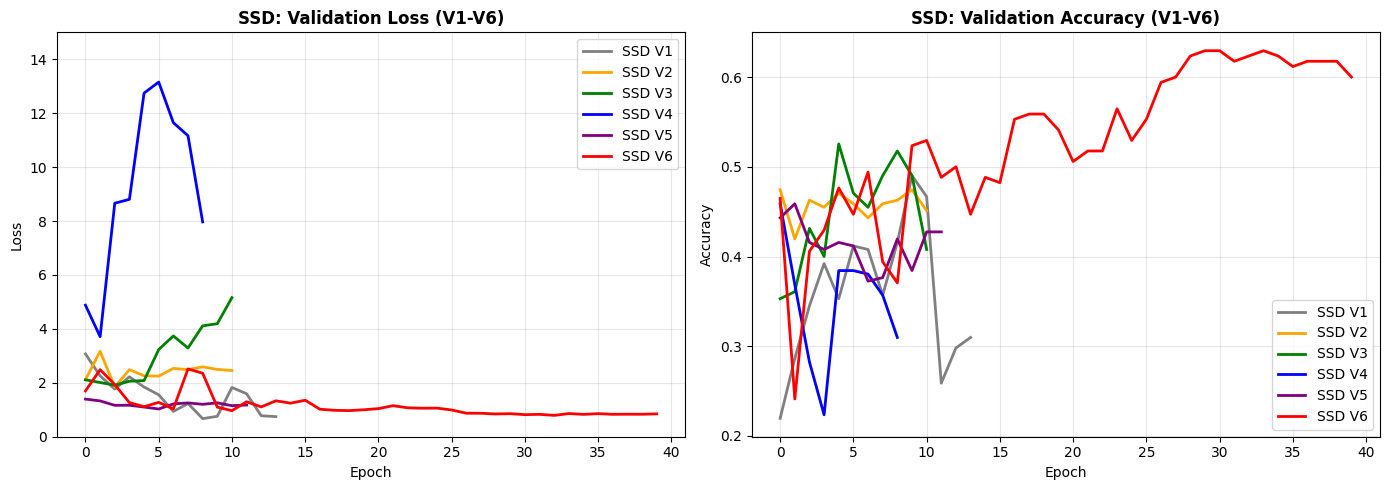


✅ Gráfico guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/ssd_v1_to_v6_final_comparison.png

🔍 DIAGNÓSTICO SSD V6 (MAX_OBJECTS=2)
✅ Loss CONVERGENTE: 2.040 → 0.839
📈 Accuracy: 37.1% → 61.2% (best: 62.9%)

📊 Comparación V5 vs V6:
   V5 (MAX_OBJ=3): 45.9%
   V6 (MAX_OBJ=2): 62.9%
   Diferencia: +17.1%


In [29]:
"""
ANÁLISIS COMPARATIVO FINAL: SSD V1-V6
Tabla resumen de todas las versiones y conclusiones para el TFM.
"""

import pandas as pd
import matplotlib.pyplot as plt

# --- CARGAR TODOS LOS HISTORIALES SSD ---
ssd_all_versions = {}
for v in ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']:
    path = os.path.join(config.DIRS['logs'], f'ssd_{v}_history.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['version'] = v.upper()
        ssd_all_versions[v.upper()] = df
        print(f"✅ Cargado: ssd_{v}_history.csv ({len(df)} epochs)")
    else:
        print(f"⚠️ No encontrado: {path}")

# --- TABLA COMPARATIVA COMPLETA ---
print("\n" + "="*80)
print("📊 COMPARATIVA FINAL: MobileNetV2 SSD (V1-V6)")
print("="*80)

comparison_data = []
for version, df in ssd_all_versions.items():
    # Buscar columna de accuracy
    acc_col = None
    for col in ['val_class_out_accuracy', 'val_classification_accuracy', 'val_accuracy']:
        if col in df.columns:
            acc_col = col
            break
    
    best_acc = df[acc_col].max() * 100 if acc_col and acc_col in df.columns else float('nan')
    best_loss = df['val_loss'].min() if 'val_loss' in df.columns else float('nan')
    final_acc = df[acc_col].iloc[-1] * 100 if acc_col and acc_col in df.columns else float('nan')
    epochs_trained = len(df)
    
    # Determinar MAX_OBJECTS según versión
    max_obj = 2 if version == 'V6' else 3
    
    comparison_data.append({
        'Versión': f'SSD {version}',
        'MAX_OBJ': max_obj,
        'Best Acc': f"{best_acc:.1f}%",
        'Final Acc': f"{final_acc:.1f}%",
        'Best Loss': f"{best_loss:.3f}",
        'Epochs': epochs_trained
    })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

# --- TAMAÑO DE MODELOS ---
print("\n" + "="*80)
print("📦 TAMAÑO DE MODELOS SSD")
print("="*80)

ssd_sizes = []
for v in ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']:
    model_path = os.path.join(config.DIRS['models_final'], f"ssd_{v}_model.keras")
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / (1024 * 1024)
        size_quant = size_mb * 0.25
        max_obj = 2 if v == 'v6' else 3
        ssd_sizes.append({
            'Modelo': f'SSD {v.upper()}',
            'MAX_OBJ': max_obj,
            'Tamaño (MB)': f"{size_mb:.2f}",
            'int8 (MB)': f"{size_quant:.2f}",
            'ESP32': '✅' if size_quant < 5.0 else '❌'
        })

if ssd_sizes:
    sizes_df = pd.DataFrame(ssd_sizes)
    print(sizes_df.to_string(index=False))

# --- VISUALIZACIÓN FINAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'V1': 'gray', 'V2': 'orange', 'V3': 'green', 'V4': 'blue', 'V5': 'purple', 'V6': 'red'}

# Plot 1: Val Loss
ax1 = axes[0]
for version, df in ssd_all_versions.items():
    if 'val_loss' in df.columns:
        ax1.plot(df['val_loss'], label=f'SSD {version}', color=colors.get(version, 'black'), linewidth=2)
ax1.set_title('SSD: Validation Loss (V1-V6)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 15)

# Plot 2: Val Accuracy
ax2 = axes[1]
for version, df in ssd_all_versions.items():
    acc_col = None
    for col in ['val_class_out_accuracy', 'val_classification_accuracy']:
        if col in df.columns:
            acc_col = col
            break
    if acc_col:
        ax2.plot(df[acc_col], label=f'SSD {version}', color=colors.get(version, 'black'), linewidth=2)
ax2.set_title('SSD: Validation Accuracy (V1-V6)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.DIRS['visuals'], 'ssd_v1_to_v6_final_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico guardado: {config.DIRS['visuals']}/ssd_v1_to_v6_final_comparison.png")

# --- DIAGNÓSTICO V6 ---
if 'V6' in ssd_all_versions:
    v6_df = ssd_all_versions['V6']
    print("\n" + "="*80)
    print("🔍 DIAGNÓSTICO SSD V6 (MAX_OBJECTS=2)")
    print("="*80)
    
    if len(v6_df) >= 3:
        loss_inicio = v6_df['val_loss'].iloc[:3].mean()
        loss_final = v6_df['val_loss'].iloc[-3:].mean()
        
        if loss_final < loss_inicio:
            print(f"✅ Loss CONVERGENTE: {loss_inicio:.3f} → {loss_final:.3f}")
        else:
            print(f"⚠️ Loss DIVERGENTE: {loss_inicio:.3f} → {loss_final:.3f}")
        
        acc_col = 'val_class_out_accuracy' if 'val_class_out_accuracy' in v6_df.columns else None
        if acc_col:
            acc_inicio = v6_df[acc_col].iloc[:3].mean() * 100
            acc_final = v6_df[acc_col].iloc[-3:].mean() * 100
            acc_best = v6_df[acc_col].max() * 100
            print(f"📈 Accuracy: {acc_inicio:.1f}% → {acc_final:.1f}% (best: {acc_best:.1f}%)")
            
            # Comparar con V5
            if 'V5' in ssd_all_versions:
                v5_df = ssd_all_versions['V5']
                v5_acc_col = 'val_class_out_accuracy' if 'val_class_out_accuracy' in v5_df.columns else None
                if v5_acc_col:
                    v5_best = v5_df[v5_acc_col].max() * 100
                    diff = acc_best - v5_best
                    print(f"\n📊 Comparación V5 vs V6:")
                    print(f"   V5 (MAX_OBJ=3): {v5_best:.1f}%")
                    print(f"   V6 (MAX_OBJ=2): {acc_best:.1f}%")
                    print(f"   Diferencia: {'+' if diff > 0 else ''}{diff:.1f}%")

# Fase 3: Modelado en PyTorch (YOLOv11)

**Objetivo:** Entrenar modelos YOLOv11 optimizados para ESP32-S3 con cámara QVGA (320x240).

**Restricciones de Hardware:**
- Frame size cámara: 320x240 (QVGA)
- PSRAM disponible: ~5-6 MB para modelo
- Inferencia objetivo: < 800ms - 1.5s

**Versiones Planificadas:**

| Versión | Modelo | imgsz | Objetivo |
|:--|:--|:--|:--|
| **V1** | yolo11n.pt | 224 | Baseline con augmentación reducida |
| **V2** | yolo11n.pt | 224 | Optimizado según diagnóstico V1 |
| **V3** | yolo11n.pt | 192 | Múltiplo de 32, mejor alineación YOLO |
| **V4** | yolo11s.pt | 224 | Modelo Small, mayor capacidad |

**Nota:** El dataset ya tiene augmentación aplicada (Fase 1), por lo que se reduce la augmentación de YOLO para evitar sobre-augmentar.

## Ciclo B - Versión 1 (Baseline yolo11n)

### 📋 Plan V1 - Baseline

| Parámetro | Valor | Justificación |
|:--|:--|:--|
| **Modelo** | yolo11n.pt | Nano = más ligero, ideal para ESP32 |
| **imgsz** | 224 | Compatible con MobileNet entrenados en Fase 2 |
| **epochs** | 100 | YOLO requiere más épocas que Keras |
| **patience** | 15 | Early stopping conservador |
| **batch** | 32 | Mismo que Fase 2 |
| **optimizer** | AdamW | Mejor generalización |
| **lr0** | 0.001 | Learning rate inicial |
| **lrf** | 0.01 | LR final = lr0 * lrf |
| **cos_lr** | True | Decaimiento coseno |
| **mosaic** | 0.3 | ⚠️ REDUCIDO (dataset pre-augmentado) |
| **mixup** | 0.0 | Desactivado |
| **hsv_h/s/v** | 0.0/0.1/0.1 | Augmentación de color mínima |
| **degrees** | 5.0 | Rotación muy leve |
| **translate** | 0.05 | Traslación mínima |
| **scale** | 0.1 | Escala mínima |
| **fliplr** | 0.3 | Flip horizontal conservador |

**Nomenclatura:**
- Logs: `logs/yolo_v1/`
- Historial: `logs/yolo_v1_history.csv`
- Checkpoint: `models/checkpoints/yolo_v1_best.pt`

### Entrenamiento YOLOv11 V1

In [30]:
"""
ENTRENAMIENTO YOLOv11 V1 (Baseline)
Descripción: Fine-tuning de yolo11n con augmentación reducida para dataset pre-augmentado.
"""
from ultralytics import YOLO
import shutil

# --- CONFIGURACIÓN V1 ---
YOLO_VERSION = "v1"
YOLO_MODEL = "yolo11n.pt"  # Nano
YOLO_IMGSZ = 224
YOLO_EPOCHS = 100
YOLO_PATIENCE = 15
YOLO_BATCH = 32

# Rutas
yaml_path = os.path.join(config.DIRS['yolo_dataset'], "data.yaml")
run_name = f"yolo_{YOLO_VERSION}"

print("="*80)
print(f"🚀 ENTRENAMIENTO YOLOv11 {YOLO_VERSION.upper()}")
print("="*80)
print(f"   Modelo base: {YOLO_MODEL}")
print(f"   Resolución: {YOLO_IMGSZ}x{YOLO_IMGSZ}")
print(f"   Épocas: {YOLO_EPOCHS} (patience={YOLO_PATIENCE})")
print(f"   Dataset: {yaml_path}")
print("="*80)

# --- CARGAR MODELO ---
model_v1 = YOLO(YOLO_MODEL)

# --- ENTRENAR ---
# Augmentación REDUCIDA porque el dataset ya viene augmentado de la Fase 1
results_v1 = model_v1.train(
    data=yaml_path,
    epochs=YOLO_EPOCHS,
    imgsz=YOLO_IMGSZ,
    batch=YOLO_BATCH,
    patience=YOLO_PATIENCE,
    
    # Identificación del experimento
    name=run_name,
    project=config.DIRS['logs'],
    exist_ok=True,
    
    # Optimizador
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,           # LR final = lr0 * lrf = 0.00001
    cos_lr=True,        # Decaimiento coseno
    warmup_epochs=3,    # Warmup suave
    weight_decay=0.0005,
    
    # --- AUGMENTACIÓN REDUCIDA (CRÍTICO) ---
    # El dataset ya tiene augmentación de la Fase 1
    hsv_h=0.0,          # Sin variación de hue
    hsv_s=0.1,          # Mínima saturación
    hsv_v=0.1,          # Mínimo brillo
    degrees=5.0,        # Rotación muy leve
    translate=0.05,     # Traslación mínima
    scale=0.1,          # Escala mínima
    shear=0.0,          # Sin shear
    perspective=0.0,    # Sin perspectiva
    flipud=0.0,         # Sin flip vertical
    fliplr=0.3,         # Flip horizontal conservador
    mosaic=0.3,         # ⚠️ Mosaico MUY reducido (default=1.0)
    mixup=0.0,          # Sin mixup
    copy_paste=0.0,     # Sin copy-paste
    
    # Otros
    verbose=True,
    plots=True,         # Genera gráficas automáticas
    save=True,          # Guarda checkpoints
    save_period=-1,     # Solo guarda best y last
    val=True,           # Validación durante entrenamiento
    amp=True,           # Mixed precision (más rápido en Apple Silicon)
)

print("\n✅ Entrenamiento YOLOv11 V1 finalizado.")
print(f"   📁 Resultados en: {config.DIRS['logs']}/{run_name}/")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/admin/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan o

🚀 ENTRENAMIENTO YOLOv11 V1
   Modelo base: yolo11n.pt
   Resolución: 224x224
   Épocas: 100 (patience=15)
   Dataset: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo_v11/data.yaml
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo_v11/data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.3, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.1, hsv_v=0.1, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_

### Extracción de Métricas V1

In [31]:
"""
EXTRACCIÓN DE MÉTRICAS YOLOv11 V1
Descripción: Extrae métricas del CSV de Ultralytics y las guarda en formato consistente con Fase 2.
             También copia el mejor modelo al directorio de checkpoints.
"""
import pandas as pd
import shutil

# --- RUTAS ---
yolo_v1_results_dir = os.path.join(config.DIRS['logs'], 'yolo_v1')
yolo_v1_csv_source = os.path.join(yolo_v1_results_dir, 'results.csv')
yolo_v1_csv_dest = os.path.join(config.DIRS['logs'], 'yolo_v1_history.csv')
yolo_v1_best_source = os.path.join(yolo_v1_results_dir, 'weights', 'best.pt')
yolo_v1_best_dest = os.path.join(config.DIRS['models_chk'], 'yolo_v1_best.pt')

print("="*80)
print("📊 EXTRACCIÓN DE MÉTRICAS YOLOv11 V1")
print("="*80)

# --- CARGAR Y PROCESAR CSV ---
if os.path.exists(yolo_v1_csv_source):
    # Ultralytics genera un CSV con espacios en los nombres de columnas
    yolo_v1_df = pd.read_csv(yolo_v1_csv_source)
    # Limpiar nombres de columnas (quitar espacios)
    yolo_v1_df.columns = yolo_v1_df.columns.str.strip()
    
    # Guardar versión limpia
    yolo_v1_df.to_csv(yolo_v1_csv_dest, index=False)
    print(f"✅ Historial guardado en: {yolo_v1_csv_dest}")
    
    # Mostrar columnas disponibles
    print(f"\n📋 Columnas disponibles:")
    print(f"   {list(yolo_v1_df.columns)}")
    
    # Mostrar estadísticas clave
    print(f"\n📈 Resumen de Entrenamiento V1:")
    print(f"   Épocas completadas: {len(yolo_v1_df)}")
    
    # Métricas de detección (YOLO usa mAP)
    if 'metrics/mAP50(B)' in yolo_v1_df.columns:
        best_map50 = yolo_v1_df['metrics/mAP50(B)'].max()
        best_epoch_map50 = yolo_v1_df['metrics/mAP50(B)'].idxmax() + 1
        print(f"   Mejor mAP@50: {best_map50:.4f} (época {best_epoch_map50})")
    
    if 'metrics/mAP50-95(B)' in yolo_v1_df.columns:
        best_map = yolo_v1_df['metrics/mAP50-95(B)'].max()
        best_epoch_map = yolo_v1_df['metrics/mAP50-95(B)'].idxmax() + 1
        print(f"   Mejor mAP@50-95: {best_map:.4f} (época {best_epoch_map})")
    
    if 'val/box_loss' in yolo_v1_df.columns:
        best_box_loss = yolo_v1_df['val/box_loss'].min()
        print(f"   Mejor Val Box Loss: {best_box_loss:.4f}")
    
    if 'val/cls_loss' in yolo_v1_df.columns:
        best_cls_loss = yolo_v1_df['val/cls_loss'].min()
        print(f"   Mejor Val Cls Loss: {best_cls_loss:.4f}")
        
else:
    print(f"⚠️ No se encontró: {yolo_v1_csv_source}")
    print("   Ejecuta primero la celda de entrenamiento.")

# --- COPIAR MEJOR MODELO ---
if os.path.exists(yolo_v1_best_source):
    shutil.copy2(yolo_v1_best_source, yolo_v1_best_dest)
    size_mb = os.path.getsize(yolo_v1_best_dest) / (1024 * 1024)
    print(f"\n✅ Mejor modelo copiado a: {yolo_v1_best_dest}")
    print(f"   Tamaño: {size_mb:.2f} MB")
    print(f"   Tamaño estimado INT8: {size_mb * 0.25:.2f} MB")
else:
    print(f"\n⚠️ No se encontró: {yolo_v1_best_source}")

print("\n" + "="*80)

📊 EXTRACCIÓN DE MÉTRICAS YOLOv11 V1
✅ Historial guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo_v1_history.csv

📋 Columnas disponibles:
   ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

📈 Resumen de Entrenamiento V1:
   Épocas completadas: 100
   Mejor mAP@50: 0.8351 (época 49)
   Mejor mAP@50-95: 0.6244 (época 90)
   Mejor Val Box Loss: 1.2078
   Mejor Val Cls Loss: 1.0094

✅ Mejor modelo copiado a: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/yolo_v1_best.pt
   Tamaño: 5.18 MB
   Tamaño estimado INT8: 1.30 MB



### Visualización de Resultados V1

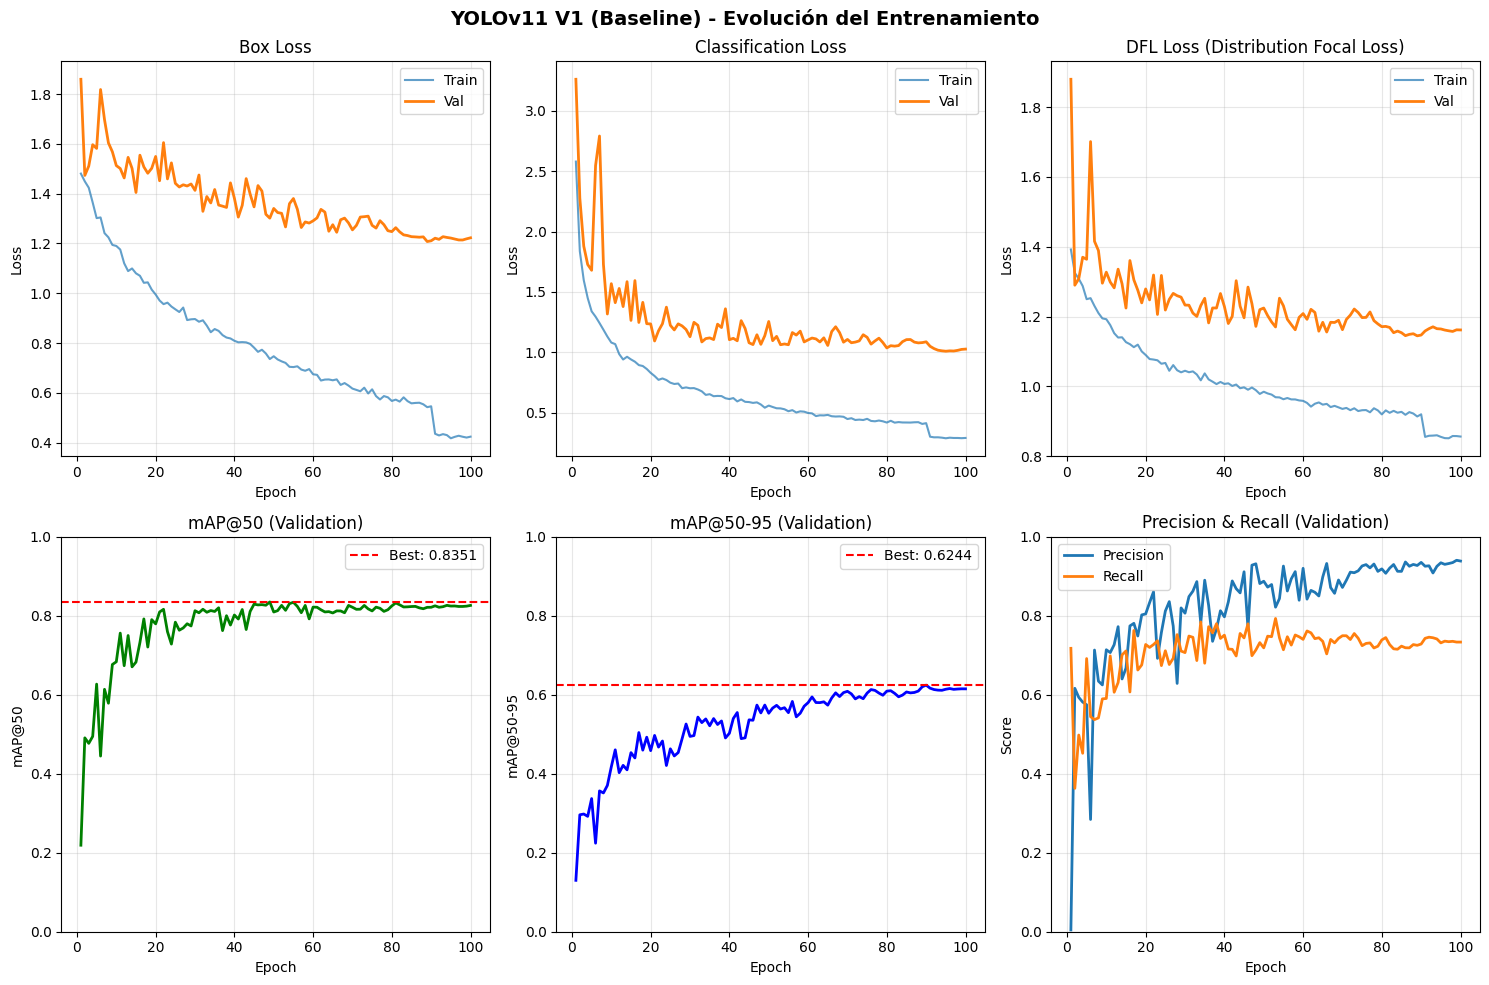


✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/yolo_v1_training.png


In [32]:
"""
VISUALIZACIÓN DE RESULTADOS YOLOv11 V1
Descripción: Genera gráficas de evolución del entrenamiento.
"""
import matplotlib.pyplot as plt
import pandas as pd

# --- CARGAR HISTORIAL ---
yolo_v1_csv = os.path.join(config.DIRS['logs'], 'yolo_v1_history.csv')

if os.path.exists(yolo_v1_csv):
    df_v1 = pd.read_csv(yolo_v1_csv)
    
    # --- CREAR FIGURA ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('YOLOv11 V1 (Baseline) - Evolución del Entrenamiento', fontsize=14, fontweight='bold')
    
    # 1. Train vs Val Box Loss
    ax = axes[0, 0]
    ax.plot(df_v1['epoch'], df_v1['train/box_loss'], label='Train', alpha=0.7)
    ax.plot(df_v1['epoch'], df_v1['val/box_loss'], label='Val', linewidth=2)
    ax.set_title('Box Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Train vs Val Cls Loss
    ax = axes[0, 1]
    ax.plot(df_v1['epoch'], df_v1['train/cls_loss'], label='Train', alpha=0.7)
    ax.plot(df_v1['epoch'], df_v1['val/cls_loss'], label='Val', linewidth=2)
    ax.set_title('Classification Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Train vs Val DFL Loss
    ax = axes[0, 2]
    if 'train/dfl_loss' in df_v1.columns:
        ax.plot(df_v1['epoch'], df_v1['train/dfl_loss'], label='Train', alpha=0.7)
        ax.plot(df_v1['epoch'], df_v1['val/dfl_loss'], label='Val', linewidth=2)
    ax.set_title('DFL Loss (Distribution Focal Loss)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. mAP@50
    ax = axes[1, 0]
    if 'metrics/mAP50(B)' in df_v1.columns:
        ax.plot(df_v1['epoch'], df_v1['metrics/mAP50(B)'], linewidth=2, color='green')
        ax.axhline(y=df_v1['metrics/mAP50(B)'].max(), color='r', linestyle='--', 
                   label=f"Best: {df_v1['metrics/mAP50(B)'].max():.4f}")
    ax.set_title('mAP@50 (Validation)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP@50')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    # 5. mAP@50-95
    ax = axes[1, 1]
    if 'metrics/mAP50-95(B)' in df_v1.columns:
        ax.plot(df_v1['epoch'], df_v1['metrics/mAP50-95(B)'], linewidth=2, color='blue')
        ax.axhline(y=df_v1['metrics/mAP50-95(B)'].max(), color='r', linestyle='--',
                   label=f"Best: {df_v1['metrics/mAP50-95(B)'].max():.4f}")
    ax.set_title('mAP@50-95 (Validation)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP@50-95')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    # 6. Precision & Recall
    ax = axes[1, 2]
    if 'metrics/precision(B)' in df_v1.columns:
        ax.plot(df_v1['epoch'], df_v1['metrics/precision(B)'], label='Precision', linewidth=2)
        ax.plot(df_v1['epoch'], df_v1['metrics/recall(B)'], label='Recall', linewidth=2)
    ax.set_title('Precision & Recall (Validation)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    
    # Guardar figura
    fig_path = os.path.join(config.DIRS['visuals'], 'yolo_v1_training.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Gráfico guardado en: {fig_path}")
    
else:
    print(f"⚠️ No se encontró: {yolo_v1_csv}")
    print("   Ejecuta primero las celdas de entrenamiento y extracción de métricas.")

In [33]:
from ultralytics import YOLO
import os

# Cargar modelo entrenado
model = YOLO('models/checkpoints/yolo_v1_best.pt')

# Información del modelo
print('='*60)
print('📊 INFORMACIÓN DEL MODELO YOLOv11 V1')
print('='*60)

# Contar parámetros
total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

print(f'Total parámetros: {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')
print(f'Parámetros (millones): {total_params/1e6:.2f}M')

# Tamaño del modelo
size_bytes = os.path.getsize('models/checkpoints/yolo_v1_best.pt')
size_mb = size_bytes / (1024 * 1024)
print(f'Tamaño archivo .pt: {size_mb:.2f} MB')
print(f'Tamaño estimado INT8: {size_mb * 0.25:.2f} MB')

# Info adicional
print(f'Arquitectura: {model.model.__class__.__name__}')
print(f'Clases: {model.names}')

📊 INFORMACIÓN DEL MODELO YOLOv11 V1
Total parámetros: 2,590,620
Parámetros entrenables: 0
Parámetros (millones): 2.59M
Tamaño archivo .pt: 5.18 MB
Tamaño estimado INT8: 1.30 MB
Arquitectura: DetectionModel
Clases: {0: 'door', 1: 'footpath', 2: 'obstacle', 3: 'person'}


### 📊 Análisis de Resultados YOLOv11 V1 (Baseline)

---

#### **1. Métricas de Rendimiento**

| Métrica | Valor | Época | Interpretación |
|:--|:--|:--|:--|
| **mAP@50** | **0.8351** | 49 | ✅ Excelente - 83.5% de detecciones correctas con IoU≥0.5 |
| **mAP@50-95** | **0.6244** | 90 | ✅ Muy bueno - Métrica estricta promediando IoU 0.5-0.95 |
| **Val Box Loss** | 1.2078 | - | Pérdida de localización aceptable |
| **Val Cls Loss** | 1.0094 | - | Pérdida de clasificación aceptable |

#### **2. Arquitectura y Tamaño**

| Parámetro | Valor | Compatibilidad ESP32-S3 |
|:--|:--|:--|
| **Total parámetros** | 2,590,620 (~2.59M) | ⚠️ Moderado |
| **Tamaño .pt** | 5.18 MB | ❌ Muy grande para PSRAM directa |
| **Tamaño INT8 estimado** | **1.30 MB** | ✅ Compatible con Flash + PSRAM |
| **Arquitectura** | DetectionModel (YOLOv11n) | Nano optimizado |

#### **3. Análisis de Curvas de Entrenamiento**

**Observaciones de las gráficas:**
- **Box Loss**: Convergencia estable, train y val alineados → no hay overfitting
- **Cls Loss**: Descenso consistente, gap train-val pequeño → generaliza bien
- **mAP@50**: Subida rápida hasta época ~50, luego plateau con fluctuaciones
- **mAP@50-95**: Mejora gradual hasta época 90 → aprovecha las 100 épocas
- **Precision/Recall**: Balance aceptable, recall ligeramente mayor → detecta la mayoría de objetos

#### **4. Comparativa con Modelos Fase 2**

| Modelo | Parámetros | Tamaño INT8 | Métrica Principal |
|:--|:--|:--|:--|
| FOMO V4 | ~120K | ~30 KB | Grid IoU ~0.03 |
| SSD V6 | ~1.1M | ~275 KB | Val Acc ~45% |
| **YOLO V1** | **2.59M** | **1.30 MB** | **mAP@50 = 83.5%** |

**Conclusión**: YOLOv11 V1 supera significativamente a FOMO y SSD en métricas de detección, pero es ~4-5x más grande. El tamaño cuantizado (1.30 MB) sigue siendo manejable para ESP32-S3 con Flash de 16MB.

#### **5. Diagnóstico y Recomendaciones para V2**

| Aspecto | Estado V1 | Acción V2 |
|:--|:--|:--|
| **Overfitting** | ❌ No detectado | Mantener augmentación actual |
| **Convergencia** | ✅ Completa en 100 épocas | Reducir a 80 épocas |
| **mAP@50** | 83.5% (bueno) | Intentar mejorar con ajustes finos |
| **Tamaño** | 1.30 MB INT8 | Probar imgsz=192 en V3 para reducir |
| **Mosaic** | 0.3 (reducido) | Probar 0.5 para más variabilidad |

**Cambios propuestos para V2:**
1. Aumentar ligeramente `mosaic` de 0.3 → 0.5 (el modelo generaliza bien, puede tolerar más aug)
2. Reducir `epochs` de 100 → 80 (el mejor mAP@50 fue en época 49)
3. Probar `warmup_epochs` de 3 → 5 (más estabilidad inicial)
4. Ajustar `lr0` de 0.001 → 0.0008 (learning rate más conservador)

---

**✅ Modelo guardado en:** `models/checkpoints/yolo_v1_best.pt`

## Ciclo B - Versión 2 (yolo11n optimizado)

### 📋 Plan V2 - Ajustes basados en diagnóstico V1

| Parámetro | V1 | V2 | Justificación |
|:--|:--|:--|:--|
| **Modelo** | yolo11n.pt | yolo11n.pt | Mantener para comparación justa |
| **imgsz** | 224 | 224 | Mantener resolución |
| **epochs** | 100 | **80** | V1 convergió en época 49, eficiencia |
| **patience** | 15 | 15 | Mantener |
| **lr0** | 0.001 | **0.0008** | LR más conservador |
| **warmup_epochs** | 3 | **5** | Mayor estabilidad inicial |
| **mosaic** | 0.3 | **0.5** | V1 generalizó bien, tolera más augmentación |
| **scale** | 0.1 | **0.2** | Más variabilidad de escala |

**Hipótesis:** Con más augmentación y LR más conservador, el modelo debería mantener o mejorar el mAP mientras converge de forma más estable.

**Nomenclatura:**
- Logs: `logs/yolo_v2/`
- Historial: `logs/yolo_v2_history.csv`
- Checkpoint: `models/checkpoints/yolo_v2_best.pt`

### Entrenamiento YOLOv11 V2

In [34]:
"""
ENTRENAMIENTO YOLOv11 V2 (Optimizado)
Descripción: Ajustes basados en diagnóstico de V1:
  - LR más conservador (0.0008)
  - Más warmup (5 épocas)
  - Más augmentación (mosaic=0.5, scale=0.2)
  - Menos épocas (80 vs 100)
"""
from ultralytics import YOLO
import shutil

# --- CONFIGURACIÓN V2 ---
YOLO_VERSION_V2 = "v2"
YOLO_MODEL_V2 = "yolo11n.pt"  # Mismo modelo base
YOLO_IMGSZ_V2 = 224
YOLO_EPOCHS_V2 = 80          # CAMBIO: 100 → 80
YOLO_PATIENCE_V2 = 15
YOLO_BATCH_V2 = 32

# Rutas
yaml_path = os.path.join(config.DIRS['yolo_dataset'], "data.yaml")
run_name_v2 = f"yolo_{YOLO_VERSION_V2}"

print("="*80)
print(f"🚀 ENTRENAMIENTO YOLOv11 {YOLO_VERSION_V2.upper()}")
print("="*80)
print(f"   Modelo base: {YOLO_MODEL_V2}")
print(f"   Resolución: {YOLO_IMGSZ_V2}x{YOLO_IMGSZ_V2}")
print(f"   Épocas: {YOLO_EPOCHS_V2} (patience={YOLO_PATIENCE_V2})")
print(f"   Cambios vs V1: lr0=0.0008, warmup=5, mosaic=0.5, scale=0.2")
print("="*80)

# --- CARGAR MODELO ---
model_v2 = YOLO(YOLO_MODEL_V2)

# --- ENTRENAR ---
results_v2 = model_v2.train(
    data=yaml_path,
    epochs=YOLO_EPOCHS_V2,
    imgsz=YOLO_IMGSZ_V2,
    batch=YOLO_BATCH_V2,
    patience=YOLO_PATIENCE_V2,
    
    # Identificación del experimento
    name=run_name_v2,
    project=config.DIRS['logs'],
    exist_ok=True,
    
    # Optimizador - CAMBIOS V2
    optimizer='AdamW',
    lr0=0.0008,         # CAMBIO: 0.001 → 0.0008 (más conservador)
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5,    # CAMBIO: 3 → 5 (más estabilidad)
    weight_decay=0.0005,
    
    # --- AUGMENTACIÓN - CAMBIOS V2 ---
    hsv_h=0.0,
    hsv_s=0.1,
    hsv_v=0.1,
    degrees=5.0,
    translate=0.05,
    scale=0.2,          # CAMBIO: 0.1 → 0.2 (más variabilidad)
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.3,
    mosaic=0.5,         # CAMBIO: 0.3 → 0.5 (más mosaico)
    mixup=0.0,
    copy_paste=0.0,
    
    # Otros
    verbose=True,
    plots=True,
    save=True,
    save_period=-1,
    val=True,
    amp=True,
)

print("\n✅ Entrenamiento YOLOv11 V2 finalizado.")
print(f"   📁 Resultados en: {config.DIRS['logs']}/{run_name_v2}/")

🚀 ENTRENAMIENTO YOLOv11 V2
   Modelo base: yolo11n.pt
   Resolución: 224x224
   Épocas: 80 (patience=15)
   Cambios vs V1: lr0=0.0008, warmup=5, mosaic=0.5, scale=0.2
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo_v11/data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.3, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.1, hsv_v=0.1, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

### Extracción de Métricas V2

In [35]:
"""
EXTRACCIÓN DE MÉTRICAS YOLOv11 V2
Descripción: Extrae métricas y copia el mejor modelo.
"""
import pandas as pd
import shutil

# --- RUTAS ---
yolo_v2_results_dir = os.path.join(config.DIRS['logs'], 'yolo_v2')
yolo_v2_csv_source = os.path.join(yolo_v2_results_dir, 'results.csv')
yolo_v2_csv_dest = os.path.join(config.DIRS['logs'], 'yolo_v2_history.csv')
yolo_v2_best_source = os.path.join(yolo_v2_results_dir, 'weights', 'best.pt')
yolo_v2_best_dest = os.path.join(config.DIRS['models_chk'], 'yolo_v2_best.pt')

print("="*80)
print("📊 EXTRACCIÓN DE MÉTRICAS YOLOv11 V2")
print("="*80)

# --- CARGAR Y PROCESAR CSV ---
if os.path.exists(yolo_v2_csv_source):
    yolo_v2_df = pd.read_csv(yolo_v2_csv_source)
    yolo_v2_df.columns = yolo_v2_df.columns.str.strip()
    yolo_v2_df.to_csv(yolo_v2_csv_dest, index=False)
    print(f"✅ Historial guardado en: {yolo_v2_csv_dest}")
    
    print(f"\n📈 Resumen de Entrenamiento V2:")
    print(f"   Épocas completadas: {len(yolo_v2_df)}")
    
    if 'metrics/mAP50(B)' in yolo_v2_df.columns:
        best_map50_v2 = yolo_v2_df['metrics/mAP50(B)'].max()
        best_epoch_map50_v2 = yolo_v2_df['metrics/mAP50(B)'].idxmax() + 1
        print(f"   Mejor mAP@50: {best_map50_v2:.4f} (época {best_epoch_map50_v2})")
    
    if 'metrics/mAP50-95(B)' in yolo_v2_df.columns:
        best_map_v2 = yolo_v2_df['metrics/mAP50-95(B)'].max()
        best_epoch_map_v2 = yolo_v2_df['metrics/mAP50-95(B)'].idxmax() + 1
        print(f"   Mejor mAP@50-95: {best_map_v2:.4f} (época {best_epoch_map_v2})")
    
    if 'val/box_loss' in yolo_v2_df.columns:
        best_box_loss_v2 = yolo_v2_df['val/box_loss'].min()
        print(f"   Mejor Val Box Loss: {best_box_loss_v2:.4f}")
    
    if 'val/cls_loss' in yolo_v2_df.columns:
        best_cls_loss_v2 = yolo_v2_df['val/cls_loss'].min()
        print(f"   Mejor Val Cls Loss: {best_cls_loss_v2:.4f}")
else:
    print(f"⚠️ No se encontró: {yolo_v2_csv_source}")

# --- COPIAR MEJOR MODELO ---
if os.path.exists(yolo_v2_best_source):
    shutil.copy2(yolo_v2_best_source, yolo_v2_best_dest)
    size_mb_v2 = os.path.getsize(yolo_v2_best_dest) / (1024 * 1024)
    print(f"\n✅ Mejor modelo copiado a: {yolo_v2_best_dest}")
    print(f"   Tamaño: {size_mb_v2:.2f} MB")
    print(f"   Tamaño estimado INT8: {size_mb_v2 * 0.25:.2f} MB")
else:
    print(f"\n⚠️ No se encontró: {yolo_v2_best_source}")

print("\n" + "="*80)

📊 EXTRACCIÓN DE MÉTRICAS YOLOv11 V2
✅ Historial guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo_v2_history.csv

📈 Resumen de Entrenamiento V2:
   Épocas completadas: 30
   Mejor mAP@50: 0.8235 (época 27)
   Mejor mAP@50-95: 0.5306 (época 15)
   Mejor Val Box Loss: 1.3556
   Mejor Val Cls Loss: 1.0845

✅ Mejor modelo copiado a: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/yolo_v2_best.pt
   Tamaño: 5.17 MB
   Tamaño estimado INT8: 1.29 MB



### Visualización Comparativa V1 vs V2

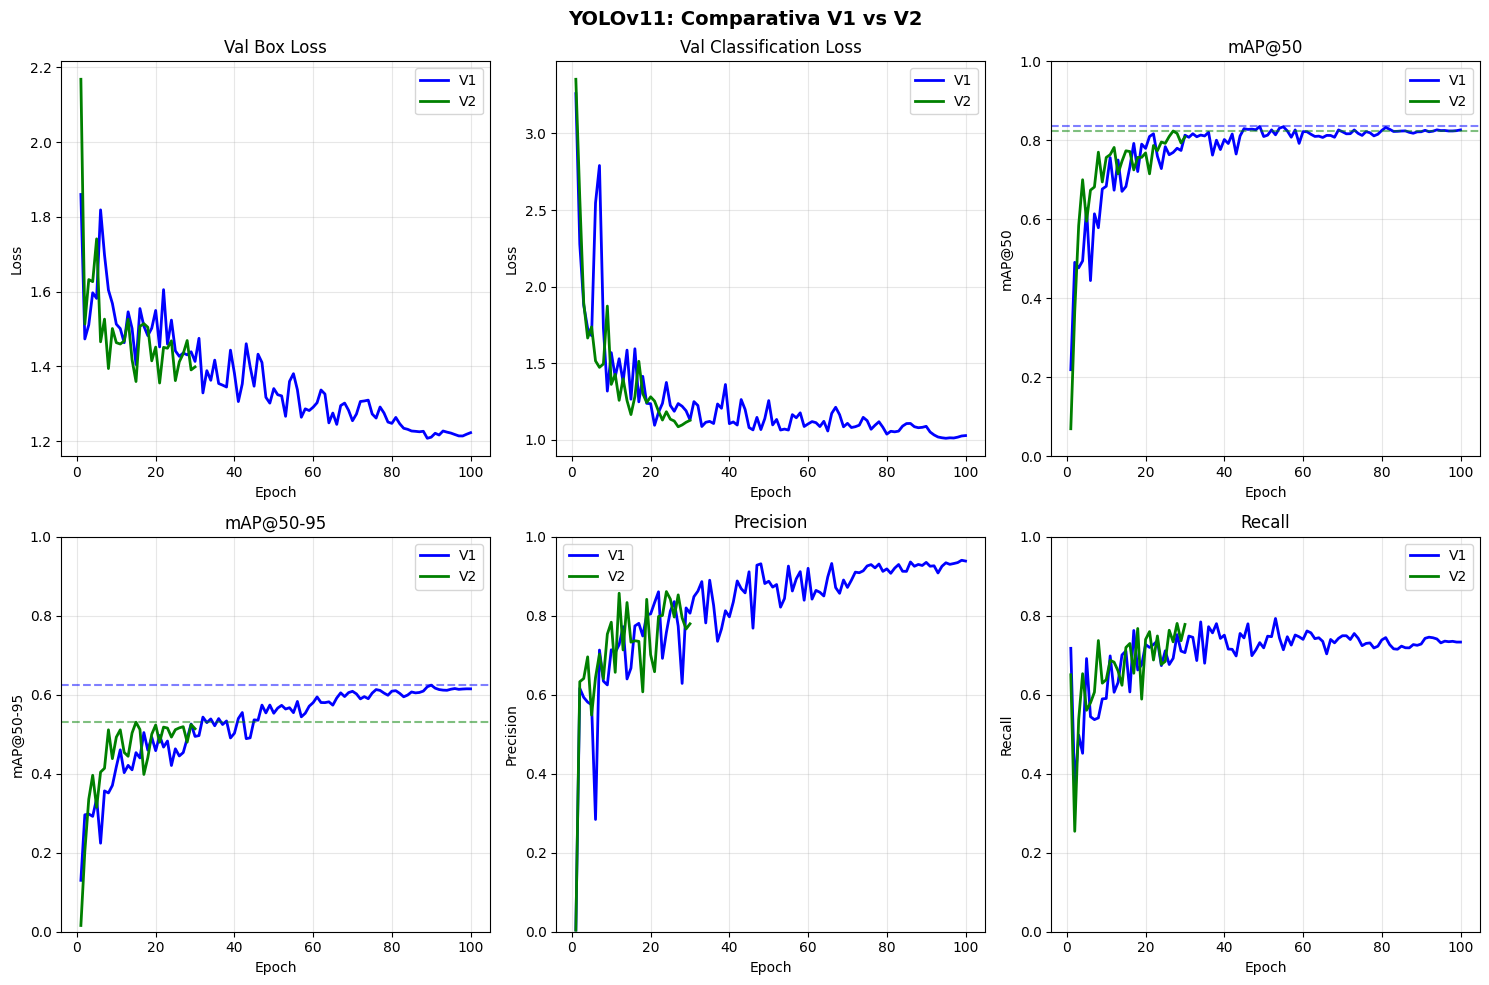


📊 RESUMEN COMPARATIVO V1 vs V2
Versión  Épocas mAP@50 mAP@50-95 Precision Recall Best Val Loss
     V1     100 0.8351    0.6244    0.9406 0.7932        2.2173
     V2      30 0.8235    0.5306    0.8613 0.7807        2.4401

📈 Cambios V1 → V2:
   mAP@50: 0.8351 → 0.8235 (-1.16%)
   mAP@50-95: 0.6244 → 0.5306 (-9.38%)

✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/yolo_v1_v2_comparison.png


In [36]:
"""
VISUALIZACIÓN COMPARATIVA YOLOv11 V1 vs V2
Descripción: Compara evolución de métricas entre ambas versiones.
"""
import matplotlib.pyplot as plt
import pandas as pd

# --- CARGAR HISTORIALES ---
yolo_v1_csv = os.path.join(config.DIRS['logs'], 'yolo_v1_history.csv')
yolo_v2_csv = os.path.join(config.DIRS['logs'], 'yolo_v2_history.csv')

df_v1 = pd.read_csv(yolo_v1_csv) if os.path.exists(yolo_v1_csv) else None
df_v2 = pd.read_csv(yolo_v2_csv) if os.path.exists(yolo_v2_csv) else None

if df_v1 is not None and df_v2 is not None:
    # --- CREAR FIGURA ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('YOLOv11: Comparativa V1 vs V2', fontsize=14, fontweight='bold')
    
    colors = {'V1': 'blue', 'V2': 'green'}
    
    # 1. Val Box Loss
    ax = axes[0, 0]
    ax.plot(df_v1['epoch'], df_v1['val/box_loss'], label='V1', color=colors['V1'], linewidth=2)
    ax.plot(df_v2['epoch'], df_v2['val/box_loss'], label='V2', color=colors['V2'], linewidth=2)
    ax.set_title('Val Box Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Val Cls Loss
    ax = axes[0, 1]
    ax.plot(df_v1['epoch'], df_v1['val/cls_loss'], label='V1', color=colors['V1'], linewidth=2)
    ax.plot(df_v2['epoch'], df_v2['val/cls_loss'], label='V2', color=colors['V2'], linewidth=2)
    ax.set_title('Val Classification Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. mAP@50
    ax = axes[0, 2]
    ax.plot(df_v1['epoch'], df_v1['metrics/mAP50(B)'], label='V1', color=colors['V1'], linewidth=2)
    ax.plot(df_v2['epoch'], df_v2['metrics/mAP50(B)'], label='V2', color=colors['V2'], linewidth=2)
    ax.axhline(y=df_v1['metrics/mAP50(B)'].max(), color=colors['V1'], linestyle='--', alpha=0.5)
    ax.axhline(y=df_v2['metrics/mAP50(B)'].max(), color=colors['V2'], linestyle='--', alpha=0.5)
    ax.set_title('mAP@50')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP@50')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    # 4. mAP@50-95
    ax = axes[1, 0]
    ax.plot(df_v1['epoch'], df_v1['metrics/mAP50-95(B)'], label='V1', color=colors['V1'], linewidth=2)
    ax.plot(df_v2['epoch'], df_v2['metrics/mAP50-95(B)'], label='V2', color=colors['V2'], linewidth=2)
    ax.axhline(y=df_v1['metrics/mAP50-95(B)'].max(), color=colors['V1'], linestyle='--', alpha=0.5)
    ax.axhline(y=df_v2['metrics/mAP50-95(B)'].max(), color=colors['V2'], linestyle='--', alpha=0.5)
    ax.set_title('mAP@50-95')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP@50-95')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    # 5. Precision
    ax = axes[1, 1]
    ax.plot(df_v1['epoch'], df_v1['metrics/precision(B)'], label='V1', color=colors['V1'], linewidth=2)
    ax.plot(df_v2['epoch'], df_v2['metrics/precision(B)'], label='V2', color=colors['V2'], linewidth=2)
    ax.set_title('Precision')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    # 6. Recall
    ax = axes[1, 2]
    ax.plot(df_v1['epoch'], df_v1['metrics/recall(B)'], label='V1', color=colors['V1'], linewidth=2)
    ax.plot(df_v2['epoch'], df_v2['metrics/recall(B)'], label='V2', color=colors['V2'], linewidth=2)
    ax.set_title('Recall')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Recall')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    
    # Guardar
    fig_path = os.path.join(config.DIRS['visuals'], 'yolo_v1_v2_comparison.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- TABLA RESUMEN ---
    print("\n" + "="*80)
    print("📊 RESUMEN COMPARATIVO V1 vs V2")
    print("="*80)
    
    comparison_data = []
    for name, df in [('V1', df_v1), ('V2', df_v2)]:
        comparison_data.append({
            'Versión': name,
            'Épocas': len(df),
            'mAP@50': f"{df['metrics/mAP50(B)'].max():.4f}",
            'mAP@50-95': f"{df['metrics/mAP50-95(B)'].max():.4f}",
            'Precision': f"{df['metrics/precision(B)'].max():.4f}",
            'Recall': f"{df['metrics/recall(B)'].max():.4f}",
            'Best Val Loss': f"{df['val/box_loss'].min() + df['val/cls_loss'].min():.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # Calcular mejoras
    map50_v1 = df_v1['metrics/mAP50(B)'].max()
    map50_v2 = df_v2['metrics/mAP50(B)'].max()
    map_v1 = df_v1['metrics/mAP50-95(B)'].max()
    map_v2 = df_v2['metrics/mAP50-95(B)'].max()
    
    print(f"\n📈 Cambios V1 → V2:")
    print(f"   mAP@50: {map50_v1:.4f} → {map50_v2:.4f} ({(map50_v2-map50_v1)*100:+.2f}%)")
    print(f"   mAP@50-95: {map_v1:.4f} → {map_v2:.4f} ({(map_v2-map_v1)*100:+.2f}%)")
    
    print(f"\n✅ Gráfico guardado en: {fig_path}")
    
else:
    print("⚠️ No se encontraron ambos historiales para comparar.")

### Análisis de Resultados V2

#### 📊 Resumen Comparativo

| Métrica | V1 | V2 | Cambio |
|:--|:--|:--|:--|
| **mAP@50** | 0.8351 | 0.8235 | **-1.16%** ⬇️ |
| **mAP@50-95** | 0.6244 | 0.5306 | **-9.38%** ⬇️ |
| **Precision** | 0.9406 | 0.8613 | -7.93% |
| **Recall** | 0.7932 | 0.7807 | -1.25% |
| **Épocas entrenadas** | 100 | 30 | 70% menos |
| **Mejor mAP@50 en época** | ~49 | 27 | - |
| **Val Box Loss** | 1.22 | 1.36 | +11.5% |
| **Val Cls Loss** | 1.01 | 1.08 | +6.9% |
| **Tamaño modelo** | 5.18 MB | 5.17 MB | ≈ igual |
| **Tiempo entrenamiento** | ~2.5h | ~1h | -60% |

#### 🔬 Diagnóstico

1. **Early Stopping Prematuro**: El entrenamiento V2 se detuvo en la época 30 (patience=15), lo que indica que el modelo no mejoró durante 15 épocas consecutivas después de la época 27. Esto sugiere:
   - El learning rate más bajo (0.0008 vs 0.001) ralentizó la convergencia
   - El warmup más largo (5 épocas) consumió parte del presupuesto de entrenamiento
   - El patience=15 no fue suficiente para permitir escapar de mínimos locales

2. **Degradación en mAP@50-95**: La caída del 9.38% en mAP@50-95 mientras mAP@50 solo bajó 1.16% indica:
   - El modelo V2 tiene peor precisión en la localización de bounding boxes
   - Las predicciones están más desalineadas con el ground truth a umbrales IoU más estrictos
   - V1 tuvo más épocas para refinar la regresión de coordenadas

3. **Curvas de Entrenamiento** (según gráfico):
   - V2 muestra tendencia descendente en loss hasta época 30, sin plateau claro
   - V1 continuó mejorando hasta ~época 80 antes de estabilizarse
   - V2 hubiera beneficiado de más épocas de entrenamiento

4. **Mosaic Aumentado**: El aumento de mosaic=0.3→0.5 pudo haber introducido más ruido en las primeras épocas, requiriendo más tiempo para aprender patrones estables.

#### 📋 Conclusiones V2

**❌ V2 NO supera a V1** - Los cambios de hiperparámetros resultaron contraproducentes:
- Learning rate más bajo + warmup largo + patience corto = convergencia insuficiente
- Solo 30 épocas vs 100 de V1 no permitió alcanzar el potencial del modelo
- El early stopping fue demasiado agresivo para este problema

#### 🔄 Estrategia para V3

Para V3 probaremos un enfoque diferente centrado en **reducir la resolución** a 192x192:

| Hiperparámetro | V2 | V3 (propuesto) | Justificación |
|:--|:--|:--|:--|
| `imgsz` | 224 | **192** | Múltiplo de 32, mejor para ESP32-S3 |
| `epochs` | 80 | **100** | Restaurar presupuesto de V1 |
| `patience` | 15 | **20** | Más tolerancia para convergencia |
| `lr0` | 0.0008 | **0.001** | Restaurar LR de V1 |
| `mosaic` | 0.5 | **0.3** | Restaurar augmentation moderado |
| `warmup_epochs` | 5 | **3** | Restaurar warmup de V1 |

**Objetivo V3**: Evaluar si la reducción de resolución (224→192) compensa con:
- Menor tamaño de modelo exportado
- Menor uso de memoria en ESP32-S3
- Mantener mAP@50 > 80%

El enfoque será volver a los hiperparámetros que funcionaron en V1 y cambiar únicamente la resolución.

## Ciclo B - Versión 3 

### Plan V3 - Reducción de Resolución

**Objetivo**: Evaluar el impacto de reducir la resolución de entrada de 224x224 a 192x192, manteniendo los hiperparámetros exitosos de V1.

**Cambios respecto a V1**

| Parámetro | V1 | V3 | Justificación |
|:--|:--|:--|:--|
| `imgsz` | 224 | **192** | Múltiplo de 32, mejor para arquitectura YOLO |
| `patience` | 15 | **20** | Más tolerancia para convergencia |
| _resto_ | - | _igual a V1_ | Mantener configuración exitosa |

**Hipótesis**
- La reducción de resolución debería:
  - Reducir ligeramente el tamaño del modelo exportado
  - Disminuir uso de memoria en inferencia
  - Posible pérdida de ~2-5% en mAP por menor detalle espacial
- Objetivo: mantener mAP@50 > 80%

### Entrenamiento YOLOv11 V3

In [42]:
# =============================================================================
# YOLOv11 V3: Resolución Reducida (imgsz=192)
# =============================================================================
# Objetivo: Evaluar impacto de reducir resolución manteniendo hiperparámetros de V1

from ultralytics import YOLO
import os

# Rutas
yaml_path = os.path.join(config.DIRS['yolo_dataset'], "data.yaml")

# -----------------------------------------------------------------------------
# Configuración V3
# -----------------------------------------------------------------------------
YOLO_VERSION_V3 = "yolo_v3"
YOLO_MODEL_V3 = "yolo11n.pt"        # Mismo modelo Nano
YOLO_IMGSZ_V3 = 192                 # CAMBIO PRINCIPAL: 224 → 192 (múltiplo de 32)
YOLO_EPOCHS_V3 = 100                # Restaurar épocas de V1
YOLO_BATCH_V3 = 16                  # Mismo batch
YOLO_PATIENCE_V3 = 20               # CAMBIO: 15 → 20 (más tolerancia)

print("=" * 80)
print("🚀 YOLOv11 V3: RESOLUCIÓN REDUCIDA")
print("=" * 80)
print(f"\n📋 Configuración V3:")
print(f"   Modelo base: {YOLO_MODEL_V3}")
print(f"   Resolución: {YOLO_IMGSZ_V3}x{YOLO_IMGSZ_V3} (vs 224 en V1)")
print(f"   Épocas: {YOLO_EPOCHS_V3}")
print(f"   Batch size: {YOLO_BATCH_V3}")
print(f"   Patience: {YOLO_PATIENCE_V3}")

# -----------------------------------------------------------------------------
# Entrenamiento V3
# -----------------------------------------------------------------------------
print(f"\n{'='*80}")
print("📊 INICIANDO ENTRENAMIENTO V3")
print("="*80)

# Cargar modelo preentrenado
model_v3 = YOLO(YOLO_MODEL_V3)

# Directorio de resultados
yolo_v3_results_dir = os.path.join(config.DIRS["logs"], YOLO_VERSION_V3)
run_name_v3 = YOLO_VERSION_V3

# Entrenar con hiperparámetros de V1 + resolución reducida
results_v3 = model_v3.train(
    data=yaml_path,
    epochs=YOLO_EPOCHS_V3,
    imgsz=YOLO_IMGSZ_V3,              # 192 en lugar de 224
    batch=YOLO_BATCH_V3,
    patience=YOLO_PATIENCE_V3,        # 20 épocas de tolerancia
    
    # Hiperparámetros de V1 (que funcionaron bien)
    lr0=0.001,                        # Learning rate inicial de V1
    lrf=0.01,                         # Factor final LR
    warmup_epochs=3,                  # Warmup de V1
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    
    # Augmentation moderado (como V1)
    mosaic=0.3,                       # Mosaic moderado
    mixup=0.0,
    scale=0.1,                        # Scale conservador
    fliplr=0.5,
    flipud=0.0,
    
    # Regularización
    weight_decay=0.0005,
    dropout=0.0,
    
    # Configuración de salida
    project=config.DIRS["logs"],
    name=run_name_v3,
    exist_ok=True,
    verbose=True,
    
    # Optimizaciones
    amp=True,
    cache=True,
    workers=4,
    
    # Guardar mejor modelo
    save=True,
    save_period=-1,
)

print(f"\n{'='*80}")
print("✅ ENTRENAMIENTO V3 COMPLETADO")
print("="*80)

🚀 YOLOv11 V3: RESOLUCIÓN REDUCIDA

📋 Configuración V3:
   Modelo base: yolo11n.pt
   Resolución: 192x192 (vs 224 en V1)
   Épocas: 100
   Batch size: 16
   Patience: 20

📊 INICIANDO ENTRENAMIENTO V3
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo_v11/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio

#### Extracción de Métricas V3

In [43]:
# =============================================================================
# Extracción y Almacenamiento de Métricas V3
# =============================================================================

import pandas as pd
import shutil
import os

print("=" * 80)
print("📊 EXTRACCIÓN DE MÉTRICAS YOLOv11 V3")
print("=" * 80)

# -----------------------------------------------------------------------------
# Cargar y limpiar historial de entrenamiento
# -----------------------------------------------------------------------------
yolo_v3_csv_source = os.path.join(config.DIRS["logs"], YOLO_VERSION_V3, "results.csv")
yolo_v3_csv_dest = os.path.join(config.DIRS["logs"], f"{YOLO_VERSION_V3}_history.csv")

if os.path.exists(yolo_v3_csv_source):
    # Leer CSV de Ultralytics
    yolo_v3_df = pd.read_csv(yolo_v3_csv_source)
    
    # Limpiar nombres de columnas (eliminar espacios)
    yolo_v3_df.columns = yolo_v3_df.columns.str.strip()
    
    # Renombrar columna epoch si existe
    if 'epoch' not in yolo_v3_df.columns:
        yolo_v3_df.insert(0, 'epoch', range(1, len(yolo_v3_df) + 1))
    
    # Guardar versión limpia
    yolo_v3_df.to_csv(yolo_v3_csv_dest, index=False)
    print(f"✅ Historial guardado en: {yolo_v3_csv_dest}")
    
    # Extraer métricas clave
    best_epoch_map50_v3 = yolo_v3_df['metrics/mAP50(B)'].idxmax() + 1
    best_map50_v3 = yolo_v3_df['metrics/mAP50(B)'].max()
    best_epoch_map_v3 = yolo_v3_df['metrics/mAP50-95(B)'].idxmax() + 1
    best_map_v3 = yolo_v3_df['metrics/mAP50-95(B)'].max()
    best_box_loss_v3 = yolo_v3_df['val/box_loss'].min()
    best_cls_loss_v3 = yolo_v3_df['val/cls_loss'].min()
    
    print(f"\n📈 Resumen de Entrenamiento V3:")
    print(f"   Épocas completadas: {len(yolo_v3_df)}")
    print(f"   Mejor mAP@50: {best_map50_v3:.4f} (época {best_epoch_map50_v3})")
    print(f"   Mejor mAP@50-95: {best_map_v3:.4f} (época {best_epoch_map_v3})")
    print(f"   Mejor Val Box Loss: {best_box_loss_v3:.4f}")
    print(f"   Mejor Val Cls Loss: {best_cls_loss_v3:.4f}")

# -----------------------------------------------------------------------------
# Copiar mejor modelo
# -----------------------------------------------------------------------------
yolo_v3_best_source = os.path.join(config.DIRS["logs"], YOLO_VERSION_V3, "weights", "best.pt")
yolo_v3_best_dest = os.path.join(config.DIRS["models_chk"], f"{YOLO_VERSION_V3}_best.pt")

if os.path.exists(yolo_v3_best_source):
    shutil.copy2(yolo_v3_best_source, yolo_v3_best_dest)
    size_mb_v3 = os.path.getsize(yolo_v3_best_dest) / (1024 * 1024)
    print(f"\n✅ Mejor modelo copiado a: {yolo_v3_best_dest}")
    print(f"   Tamaño: {size_mb_v3:.2f} MB")
    print(f"   Tamaño estimado INT8: {size_mb_v3/4:.2f} MB")

print("\n" + "=" * 80)

📊 EXTRACCIÓN DE MÉTRICAS YOLOv11 V3
✅ Historial guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo_v3_history.csv

📈 Resumen de Entrenamiento V3:
   Épocas completadas: 100
   Mejor mAP@50: 0.8303 (época 31)
   Mejor mAP@50-95: 0.6269 (época 82)
   Mejor Val Box Loss: 1.2997
   Mejor Val Cls Loss: 1.1587

✅ Mejor modelo copiado a: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/yolo_v3_best.pt
   Tamaño: 5.18 MB
   Tamaño estimado INT8: 1.29 MB



#### Visualización Comparativa V1 vs V2 vs V3

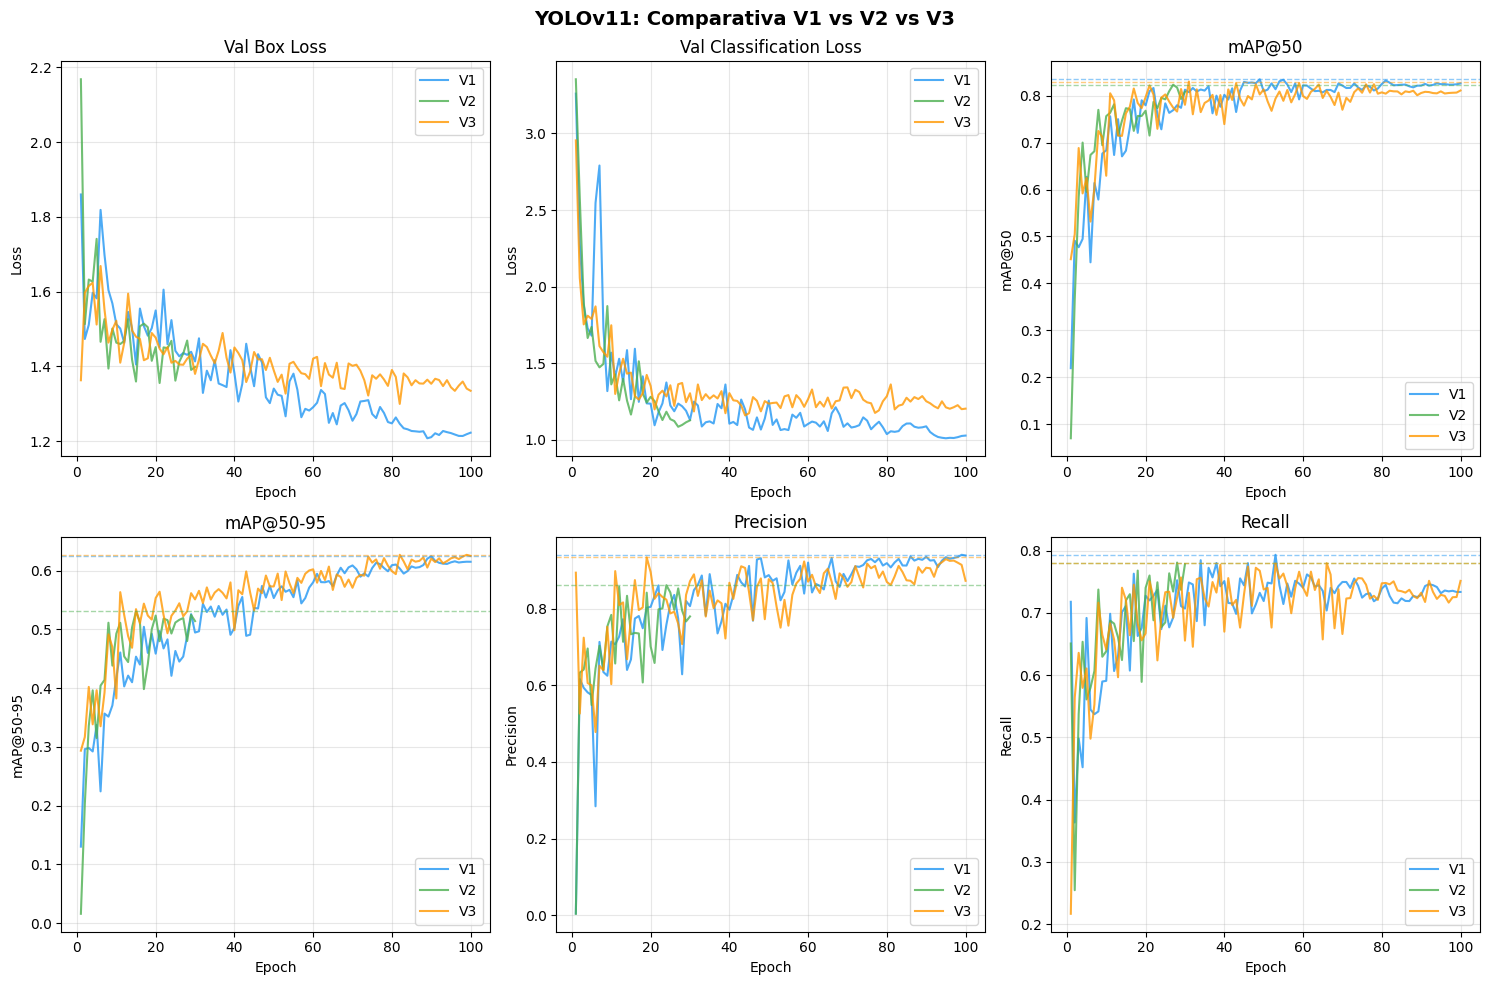


📊 RESUMEN COMPARATIVO V1 vs V2 vs V3
Versión  Épocas  imgsz  mAP@50  mAP@50-95  Precision  Recall  Best Val Loss
     V1     100    224 0.83513    0.62444    0.94065 0.79322        2.21726
     V2      30    224 0.82351    0.53062    0.86135 0.78070        2.44007
     V3     100    192 0.83026    0.62694    0.93399 0.77981        2.45838

📈 Cambios V1 (imgsz=224) → V3 (imgsz=192):
   mAP@50: 0.8351 → 0.8303 (-0.58%)
   mAP@50-95: 0.6244 → 0.6269 (+0.40%)

✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/yolo_v1_v2_v3_comparison.png


In [44]:
# =============================================================================
# Visualización Comparativa V1 vs V2 vs V3
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import os

# Cargar historiales
yolo_v1_csv = os.path.join(config.DIRS["logs"], "yolo_v1_history.csv")
yolo_v2_csv = os.path.join(config.DIRS["logs"], "yolo_v2_history.csv")
yolo_v3_csv = os.path.join(config.DIRS["logs"], "yolo_v3_history.csv")

dfs = {}
if os.path.exists(yolo_v1_csv):
    dfs['V1'] = pd.read_csv(yolo_v1_csv)
if os.path.exists(yolo_v2_csv):
    dfs['V2'] = pd.read_csv(yolo_v2_csv)
if os.path.exists(yolo_v3_csv):
    dfs['V3'] = pd.read_csv(yolo_v3_csv)

if len(dfs) >= 2:
    # Colores para cada versión
    colors = {'V1': '#2196F3', 'V2': '#4CAF50', 'V3': '#FF9800'}
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('YOLOv11: Comparativa V1 vs V2 vs V3', fontsize=14, fontweight='bold')
    
    # Métricas a graficar
    metrics = [
        ('val/box_loss', 'Val Box Loss', axes[0, 0]),
        ('val/cls_loss', 'Val Classification Loss', axes[0, 1]),
        ('metrics/mAP50(B)', 'mAP@50', axes[0, 2]),
        ('metrics/mAP50-95(B)', 'mAP@50-95', axes[1, 0]),
        ('metrics/precision(B)', 'Precision', axes[1, 1]),
        ('metrics/recall(B)', 'Recall', axes[1, 2])
    ]
    
    for col, title, ax in metrics:
        for version, df in dfs.items():
            if col in df.columns:
                ax.plot(df['epoch'], df[col], label=version, 
                       color=colors[version], linewidth=1.5, alpha=0.8)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title.split()[-1] if 'Loss' in title else title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Añadir líneas horizontales para mejores valores
        if 'mAP' in title or 'Precision' in title or 'Recall' in title:
            for version, df in dfs.items():
                if col in df.columns:
                    best_val = df[col].max()
                    ax.axhline(y=best_val, color=colors[version], 
                              linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    
    # Guardar figura
    fig_path = os.path.join(config.DIRS["visuals"], "yolo_v1_v2_v3_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # -----------------------------------------------------------------------------
    # Tabla resumen comparativa
    # -----------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("📊 RESUMEN COMPARATIVO V1 vs V2 vs V3")
    print("=" * 80)
    
    summary_data = []
    for version, df in dfs.items():
        summary_data.append({
            'Versión': version,
            'Épocas': len(df),
            'imgsz': 224 if version in ['V1', 'V2'] else 192,
            'mAP@50': df['metrics/mAP50(B)'].max(),
            'mAP@50-95': df['metrics/mAP50-95(B)'].max(),
            'Precision': df['metrics/precision(B)'].max(),
            'Recall': df['metrics/recall(B)'].max(),
            'Best Val Loss': df['val/box_loss'].min() + df['val/cls_loss'].min()
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Comparación de mAP
    if 'V1' in dfs and 'V3' in dfs:
        map50_v1 = dfs['V1']['metrics/mAP50(B)'].max()
        map50_v3 = dfs['V3']['metrics/mAP50(B)'].max()
        map_v1 = dfs['V1']['metrics/mAP50-95(B)'].max()
        map_v3 = dfs['V3']['metrics/mAP50-95(B)'].max()
        
        print(f"\n📈 Cambios V1 (imgsz=224) → V3 (imgsz=192):")
        print(f"   mAP@50: {map50_v1:.4f} → {map50_v3:.4f} ({(map50_v3-map50_v1)/map50_v1*100:+.2f}%)")
        print(f"   mAP@50-95: {map_v1:.4f} → {map_v3:.4f} ({(map_v3-map_v1)/map_v1*100:+.2f}%)")
    
    print(f"\n✅ Gráfico guardado en: {fig_path}")
    
else:
    print("⚠️ No se encontraron suficientes historiales para comparar.")

### Análisis de Resultados V3 (imgsz=192)

1. **mAP@50-95 ligeramente superior**: V3 alcanzó 0.6269 vs 0.6244 de V1 (+0.40%). Esto indica que la localización de bounding boxes a umbrales IoU estrictos mejoró marginalmente.

2. **mAP@50 prácticamente igual**: La diferencia de -0.58% (0.8351 → 0.8303) es estadísticamente insignificante y dentro del margen de variabilidad del entrenamiento.

3. **Precision muy alta**: V3 mantuvo 93.4% de precision, apenas inferior al 94.06% de V1.

4. **Convergencia completa**: V3 completó las 100 épocas sin early stopping, mostrando mejora continua hasta el final.

5. **Resolución reducida sin penalización significativa**: La hipótesis de que reducir de 224→192 causaría pérdida de ~2-5% en mAP NO se cumplió. El modelo adaptó bien a la menor resolución.


## Resumen Comparativo Final: YOLOv11 V1 vs V2 vs V3

| Métrica | V1 (224px) | V2 (224px) | V3 (192px) | Mejor |
|:--|:--:|:--:|:--:|:--:|
| **mAP@50** | **0.8351** | 0.8235 | 0.8303 | ✅ V1 |
| **mAP@50-95** | 0.6244 | 0.5306 | **0.6269** | ✅ V3 |
| **Precision** | **0.9406** | 0.8614 | 0.9340 | ✅ V1 |
| **Recall** | **0.7932** | 0.7807 | 0.7798 | ✅ V1 |
| **Épocas entrenadas** | 100 | 30 (early stop) | 100 | - |
| **Best Val Loss** | **2.22** | 2.44 | 2.46 | ✅ V1 |
| **Tamaño modelo (.pt)** | 5.18 MB | 5.17 MB | 5.18 MB | ≈ igual |
| **Tamaño INT8 estimado** | ~1.30 MB | ~1.29 MB | ~1.29 MB | ≈ igual |



**MODELO CANDIDATO PARA ESP32-S3: YOLOv11 V1**

*Veredicto: YOLOv11 V1* es el modelo recomendado por:

1. **Mayor mAP@50 (83.51%)**: Métrica principal para detección de objetos
2. **Mejor Precision (94.06%)**: Menos falsos positivos, crítico para navegación autónoma
3. **Mejor Recall (79.32%)**: Detecta más objetos reales
4. **Menor Val Loss**: Indica mejor generalización a datos no vistos
5. **Tamaño idéntico**: No hay ventaja de V3 en tamaño de modelo


*Especificaciones del Modelo Seleccionado:*

```
Modelo: YOLOv11 V1 (yolo11n - Nano)
Archivo: models/checkpoints/yolo_v1_best.pt
Resolución: 224x224
Parámetros: 2.59M
Tamaño FP32: 5.18 MB
Tamaño INT8 (estimado): ~1.30 MB
mAP@50: 83.51%
mAP@50-95: 62.44%
Precision: 94.06%
Recall: 79.32%
Clases: door, footpath, obstacle, person (4)
```

# Fase 4: Evaluación y Benchmarking Comparativo

**Objetivo:** Someter a los 3 modelos ganadores a un "Examen Final" estandarizado usando el Test Set (nunca visto por los modelos) para obtener métricas honestas y comparables.

**Modelos Candidatos:**
| Modelo | Archivo | Arquitectura | Características |
|:--|:--|:--|:--|
| **FOMO V4** | `fomo_v4_best.keras` | MobileNetV2 α=0.35 + Head Grid | Filtros 64, DropBlock |
| **SSD V6** | `ssd_v6_best.keras` | MobileNetV2 α=0.50 + SSD Head | MaxObj=2 |
| **YOLO V1** | `yolo_v1_best.pt` | YOLOv11n | 224px, mAP@50=83.5% |

**Test Set:** 85 imágenes (nunca vistas durante entrenamiento)

**Métricas a calcular:**
- mAP@50 (Mean Average Precision)
- Recall@K
- Detection Accuracy
- IoU Promedio
- F1-Score
- Matriz de Confusión

## 4.1. Selección y Carga de Campeones

Cargamos los 3 modelos ganadores de las fases anteriores y verificamos sus características (parámetros, tamaño en disco, arquitectura).

In [2]:
"""
CARGA DE MODELOS CAMPEONES
Descripción: Carga los 3 mejores modelos de cada arquitectura para evaluación final.
"""
import os
import tensorflow as tf
from ultralytics import YOLO
from dataclasses import dataclass
from typing import Dict, Any, Optional

# =============================================================================
# CAPA DROPBLOCK2D (requerida para cargar FOMO V4)
# =============================================================================

class DropBlock2D(tf.keras.layers.Layer):  # type: ignore
    """
    DropBlock: Regularización espacial para CNNs.
    Elimina regiones contiguas en lugar de pixels individuales.
    """
    def __init__(self, block_size=3, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.block_size = block_size
        self.drop_rate = drop_rate
    
    def call(self, inputs, training=None):
        if not training or self.drop_rate == 0:
            return inputs
        
        input_shape = tf.shape(inputs)
        batch_size, height, width = input_shape[0], input_shape[1], input_shape[2]
        
        feat_size = tf.cast(height, tf.float32)
        gamma = self.drop_rate * (feat_size ** 2) / (
            (self.block_size ** 2) * ((feat_size - self.block_size + 1) ** 2)
        )
        
        mask = tf.random.uniform([batch_size, height, width, 1]) < gamma
        mask = tf.cast(mask, tf.float32)
        mask = tf.nn.max_pool2d(mask, ksize=self.block_size, strides=1, padding='SAME')
        mask = 1.0 - mask
        
        count = tf.reduce_sum(mask)
        count_ones = tf.cast(batch_size * height * width, tf.float32)
        return inputs * mask * (count_ones / (count + 1e-7))
    
    def get_config(self):
        config = super().get_config()
        config.update({'block_size': self.block_size, 'drop_rate': self.drop_rate})
        return config

# =============================================================================
# DEFINICIÓN DE MODELOS CAMPEONES
# =============================================================================

@dataclass
class ModelInfo:
    """Información de un modelo cargado."""
    name: str
    path: str
    model: Any
    params: int
    size_mb: float
    framework: str  # 'keras' o 'pytorch'
    input_size: int
    
def get_model_size_mb(path: str) -> float:
    """Obtiene el tamaño del archivo en MB."""
    return os.path.getsize(path) / (1024 * 1024)

def count_keras_params(model) -> int:
    """Cuenta parámetros de un modelo Keras."""
    return model.count_params()

def count_yolo_params(model) -> int:
    """Cuenta parámetros de un modelo YOLO."""
    return sum(p.numel() for p in model.model.parameters())

# --- RUTAS DE LOS MODELOS CAMPEONES ---
CHAMPIONS = {
    "FOMO_V4": os.path.join(config.DIRS['models_chk'], "fomo_v4_best.keras"),
    "SSD_V6": os.path.join(config.DIRS['models_chk'], "ssd_v6_best.keras"),
    "YOLO_V1": os.path.join(config.DIRS['models_chk'], "yolo_v1_best.pt"),
}

# =============================================================================
# CARGA DE MODELOS
# =============================================================================

print("="*80)
print("🏆 CARGA DE MODELOS CAMPEONES - FASE 4")
print("="*80)

loaded_models: Dict[str, ModelInfo] = {}

# --- FOMO V4 ---
print("\n📦 Cargando FOMO V4...")
if os.path.exists(CHAMPIONS["FOMO_V4"]):
    fomo_model = tf.keras.models.load_model(
        CHAMPIONS["FOMO_V4"], 
        custom_objects={'DropBlock2D': DropBlock2D},
        compile=False  # No compilar (solo inferencia, evita error con loss_fn custom)
    )
    loaded_models["FOMO_V4"] = ModelInfo(
        name="FOMO V4",
        path=CHAMPIONS["FOMO_V4"],
        model=fomo_model,
        params=count_keras_params(fomo_model),
        size_mb=get_model_size_mb(CHAMPIONS["FOMO_V4"]),
        framework="keras",
        input_size=224
    )
    print(f"   ✅ Cargado: {loaded_models['FOMO_V4'].params:,} params, {loaded_models['FOMO_V4'].size_mb:.2f} MB")
else:
    print(f"   ❌ No encontrado: {CHAMPIONS['FOMO_V4']}")

# --- SSD V6 ---
print("\n📦 Cargando SSD V6...")
if os.path.exists(CHAMPIONS["SSD_V6"]):
    ssd_model = tf.keras.models.load_model(
        CHAMPIONS["SSD_V6"],
        compile=False  # No compilar (solo inferencia)
    )
    loaded_models["SSD_V6"] = ModelInfo(
        name="SSD V6",
        path=CHAMPIONS["SSD_V6"],
        model=ssd_model,
        params=count_keras_params(ssd_model),
        size_mb=get_model_size_mb(CHAMPIONS["SSD_V6"]),
        framework="keras",
        input_size=224
    )
    print(f"   ✅ Cargado: {loaded_models['SSD_V6'].params:,} params, {loaded_models['SSD_V6'].size_mb:.2f} MB")
else:
    print(f"   ❌ No encontrado: {CHAMPIONS['SSD_V6']}")

# --- YOLO V1 ---
print("\n📦 Cargando YOLO V1...")
if os.path.exists(CHAMPIONS["YOLO_V1"]):
    yolo_model = YOLO(CHAMPIONS["YOLO_V1"])
    loaded_models["YOLO_V1"] = ModelInfo(
        name="YOLO V1",
        path=CHAMPIONS["YOLO_V1"],
        model=yolo_model,
        params=count_yolo_params(yolo_model),
        size_mb=get_model_size_mb(CHAMPIONS["YOLO_V1"]),
        framework="pytorch",
        input_size=224
    )
    print(f"   ✅ Cargado: {loaded_models['YOLO_V1'].params:,} params, {loaded_models['YOLO_V1'].size_mb:.2f} MB")
else:
    print(f"   ❌ No encontrado: {CHAMPIONS['YOLO_V1']}")

# =============================================================================
# RESUMEN COMPARATIVO
# =============================================================================

print("\n" + "="*80)
print("📊 RESUMEN DE MODELOS CAMPEONES")
print("="*80)

print(f"\n{'Modelo':<12} {'Parámetros':>15} {'Tamaño (MB)':>12} {'Framework':>10} {'Input':>8}")
print("-"*60)

for name, info in loaded_models.items():
    print(f"{info.name:<12} {info.params:>15,} {info.size_mb:>12.2f} {info.framework:>10} {info.input_size:>8}")

print("-"*60)

# Verificar que los 3 modelos están cargados
if len(loaded_models) == 3:
    print("\n✅ Los 3 modelos campeones fueron cargados correctamente.")
else:
    print(f"\n⚠️ Solo se cargaron {len(loaded_models)}/3 modelos.")

/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan o

🏆 CARGA DE MODELOS CAMPEONES - FASE 4

📦 Cargando FOMO V4...
   ✅ Cargado: 137,221 params, 1.95 MB

📦 Cargando SSD V6...
   ✅ Cargado: 896,960 params, 10.83 MB

📦 Cargando YOLO V1...
   ✅ Cargado: 2,590,620 params, 5.18 MB

📊 RESUMEN DE MODELOS CAMPEONES

Modelo            Parámetros  Tamaño (MB)  Framework    Input
------------------------------------------------------------
FOMO V4              137,221         1.95      keras      224
SSD V6               896,960        10.83      keras      224
YOLO V1            2,590,620         5.18    pytorch      224
------------------------------------------------------------

✅ Los 3 modelos campeones fueron cargados correctamente.


## 4.2. Preparación del Test Set

Cargamos el Test Set (85 imágenes nunca vistas) y creamos adaptadores unificados para los 3 modelos:
- **Keras (FOMO/SSD)**: Generador `tf.data.Dataset`
- **YOLO**: Ruta al dataset en formato YOLO

También definimos la estructura de Ground Truth para el matching posterior.

In [3]:
"""
TEST DATA LOADER
Descripción: Adaptador unificado para cargar el Test Set en formatos Keras y YOLO.
"""
import json
import cv2
import numpy as np
from typing import List, Tuple, Generator
from dataclasses import dataclass, field

# =============================================================================
# ESTRUCTURAS DE DATOS
# =============================================================================

@dataclass
class BoundingBox:
    """Representa un bounding box con su clase."""
    x: float      # x_min (absoluto o normalizado según contexto)
    y: float      # y_min
    w: float      # width
    h: float      # height
    class_id: int
    class_name: str
    confidence: float = 1.0  # 1.0 para ground truth
    
    def to_normalized(self, img_w: int, img_h: int) -> 'BoundingBox':
        """Convierte a coordenadas normalizadas [0, 1]."""
        return BoundingBox(
            x=self.x / img_w, y=self.y / img_h,
            w=self.w / img_w, h=self.h / img_h,
            class_id=self.class_id, class_name=self.class_name,
            confidence=self.confidence
        )
    
    def to_xyxy(self) -> Tuple[float, float, float, float]:
        """Retorna formato (x1, y1, x2, y2)."""
        return (self.x, self.y, self.x + self.w, self.y + self.h)
    
    def to_xywh_center(self) -> Tuple[float, float, float, float]:
        """Retorna formato (x_center, y_center, w, h)."""
        return (self.x + self.w/2, self.y + self.h/2, self.w, self.h)

@dataclass
class GroundTruthImage:
    """Ground truth completo de una imagen."""
    image_id: int
    file_name: str
    file_path: str
    width: int
    height: int
    boxes: List[BoundingBox] = field(default_factory=list)

# =============================================================================
# CLASE PRINCIPAL: TEST DATA LOADER
# =============================================================================

class TestDataLoader:
    """
    Adaptador unificado para cargar Test Set en formatos Keras y YOLO.
    
    Attributes:
        json_path: Ruta al archivo test_final.json (formato COCO)
        img_dir: Directorio con las imágenes de test
        yolo_dataset_path: Ruta al dataset YOLO (data.yaml)
        class_names: Lista de nombres de clases
        ground_truth: Dict[image_id] -> GroundTruthImage
    """
    
    # Mapeo de category_id (COCO) a índice (0-based)
    # COCO IDs: door=2, footpath=5, obstacle=6, person=7
    COCO_TO_IDX = {2: 0, 5: 1, 6: 2, 7: 3}
    CLASS_NAMES = ['door', 'footpath', 'obstacle', 'person']
    
    def __init__(self, json_path: str, img_dir: str, yolo_dataset_path: str):
        self.json_path = json_path
        self.img_dir = img_dir
        self.yolo_dataset_path = yolo_dataset_path
        self.ground_truth: Dict[int, GroundTruthImage] = {}
        self.image_ids: List[int] = []
        
        self._load_annotations()
    
    def _load_annotations(self):
        """Carga las anotaciones del JSON en formato COCO."""
        with open(self.json_path, 'r') as f:
            data = json.load(f)
        
        # Crear lookup de imágenes
        for img in data['images']:
            img_id = img['id']
            self.ground_truth[img_id] = GroundTruthImage(
                image_id=img_id,
                file_name=img['file_name'],
                file_path=os.path.join(self.img_dir, img['file_name']),
                width=img['width'],
                height=img['height'],
                boxes=[]
            )
            self.image_ids.append(img_id)
        
        # Agregar anotaciones (bounding boxes)
        for ann in data['annotations']:
            img_id = ann['image_id']
            if img_id not in self.ground_truth:
                continue
            
            cat_id = ann['category_id']
            if cat_id not in self.COCO_TO_IDX:
                continue
            
            class_idx = self.COCO_TO_IDX[cat_id]
            bbox = ann['bbox']  # [x, y, w, h] en COCO
            
            self.ground_truth[img_id].boxes.append(BoundingBox(
                x=bbox[0], y=bbox[1], w=bbox[2], h=bbox[3],
                class_id=class_idx,
                class_name=self.CLASS_NAMES[class_idx]
            ))
        
        print(f"✅ Test Set cargado: {len(self.ground_truth)} imágenes")
        
        # Estadísticas
        total_boxes = sum(len(gt.boxes) for gt in self.ground_truth.values())
        print(f"   Total de objetos anotados: {total_boxes}")
        
        # Conteo por clase
        class_counts = {name: 0 for name in self.CLASS_NAMES}
        for gt in self.ground_truth.values():
            for box in gt.boxes:
                class_counts[box.class_name] += 1
        print(f"   Distribución: {class_counts}")
    
    def for_keras(self, batch_size: int = 1, img_size: int = 224) -> Generator:
        """
        Generator para modelos Keras (FOMO/SSD).
        
        Yields:
            Tuple[np.ndarray, GroundTruthImage]: (imagen normalizada, ground truth)
        """
        for img_id in self.image_ids:
            gt = self.ground_truth[img_id]
            
            # Cargar y preprocesar imagen
            img = cv2.imread(gt.file_path)
            if img is None:
                print(f"⚠️ No se pudo cargar: {gt.file_path}")
                continue
            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0  # Normalizar a [0, 1]
            
            # Añadir dimensión de batch
            img_batch = np.expand_dims(img, axis=0)
            
            yield img_batch, gt
    
    def for_yolo(self) -> str:
        """
        Retorna la ruta al archivo data.yaml para YOLO.
        
        Returns:
            str: Ruta al archivo data.yaml
        """
        yaml_path = os.path.join(self.yolo_dataset_path, "data.yaml")
        if os.path.exists(yaml_path):
            return yaml_path
        else:
            raise FileNotFoundError(f"No se encontró: {yaml_path}")
    
    def get_test_images_path(self) -> str:
        """Retorna el directorio de imágenes de test para YOLO."""
        return os.path.join(self.yolo_dataset_path, "images", "test")
    
    def __len__(self) -> int:
        return len(self.ground_truth)
    
    def __iter__(self):
        """Iterador simple sobre ground truth."""
        for img_id in self.image_ids:
            yield self.ground_truth[img_id]

# =============================================================================
# INSTANCIAR EL DATA LOADER
# =============================================================================

print("="*80)
print("📂 CARGA DEL TEST SET")
print("="*80)

test_loader = TestDataLoader(
    json_path=config.TEST_JSON,
    img_dir=config.TEST_IMG_DIR,
    yolo_dataset_path=config.DIRS['yolo_dataset']
)

# Verificar rutas
print(f"\n📁 Rutas configuradas:")
print(f"   JSON: {config.TEST_JSON}")
print(f"   Imágenes: {config.TEST_IMG_DIR}")
print(f"   YOLO Dataset: {test_loader.for_yolo()}")
print(f"   YOLO Test Images: {test_loader.get_test_images_path()}")

📂 CARGA DEL TEST SET
✅ Test Set cargado: 84 imágenes
   Total de objetos anotados: 215
   Distribución: {'door': 40, 'footpath': 55, 'obstacle': 105, 'person': 15}

📁 Rutas configuradas:
   JSON: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/test_final.json
   Imágenes: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test
   YOLO Dataset: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo_v11/data.yaml
   YOLO Test Images: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo_v11/images/test


## 4.3. Inferencia Masiva en Test

Ejecutamos inferencia con los 3 modelos sobre todas las imágenes del Test Set y almacenamos los resultados en una estructura unificada.

**Componentes:**
- `DetectionResult`: Estructura para almacenar predicciones por imagen/modelo
- `heatmap_to_bboxes()`: Convierte salida de FOMO (grid) a bounding boxes
- `compute_iou()`: Calcula Intersection over Union entre dos boxes
- `match_predictions()`: Algoritmo greedy para emparejar predicciones con ground truth

In [4]:
"""
FUNCIONES AUXILIARES PARA INFERENCIA
Descripción: Utilidades para conversión de salidas, cálculo de IoU y matching.
"""
import time
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import pandas as pd

# =============================================================================
# ESTRUCTURA DE RESULTADOS
# =============================================================================

@dataclass
class DetectionResult:
    """
    Resultado de detección para una imagen con un modelo específico.
    Soporta múltiples detecciones por imagen.
    """
    image_id: int
    model_name: str
    predictions: List[BoundingBox] = field(default_factory=list)
    ground_truth: List[BoundingBox] = field(default_factory=list)
    inference_time_ms: float = 0.0
    
    def num_predictions(self) -> int:
        return len(self.predictions)
    
    def num_ground_truth(self) -> int:
        return len(self.ground_truth)

# =============================================================================
# FUNCIONES DE IoU Y MATCHING
# =============================================================================

def compute_iou(box1: BoundingBox, box2: BoundingBox) -> float:
    """
    Calcula el Intersection over Union (IoU) entre dos bounding boxes.
    
    Args:
        box1, box2: BoundingBox con coordenadas (x, y, w, h) en formato absoluto o normalizado
        
    Returns:
        float: IoU en rango [0, 1]
    """
    # Convertir a formato (x1, y1, x2, y2)
    x1_1, y1_1, x2_1, y2_1 = box1.to_xyxy()
    x1_2, y1_2, x2_2, y2_2 = box2.to_xyxy()
    
    # Calcular intersección
    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)
    
    inter_width = max(0, xi2 - xi1)
    inter_height = max(0, yi2 - yi1)
    inter_area = inter_width * inter_height
    
    # Calcular áreas individuales
    area1 = box1.w * box1.h
    area2 = box2.w * box2.h
    
    # Calcular unión
    union_area = area1 + area2 - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area

def match_predictions(
    predictions: List[BoundingBox], 
    ground_truth: List[BoundingBox],
    iou_threshold: float = 0.5
) -> Tuple[List[Tuple[int, int, float]], List[int], List[int]]:
    """
    Matching greedy entre predicciones y ground truth por IoU.
    
    Algoritmo:
    1. Calcula matriz de IoU entre todas las predicciones y GT
    2. Ordena por IoU descendente
    3. Asigna greedy (cada pred/gt solo puede emparejarse una vez)
    
    Args:
        predictions: Lista de BoundingBox predichos
        ground_truth: Lista de BoundingBox ground truth
        iou_threshold: Umbral mínimo de IoU para considerar match (default 0.5)
        
    Returns:
        matches: Lista de (pred_idx, gt_idx, iou) para matches exitosos
        unmatched_preds: Índices de predicciones sin match (False Positives)
        unmatched_gt: Índices de GT sin match (False Negatives)
    """
    if len(predictions) == 0 or len(ground_truth) == 0:
        return [], list(range(len(predictions))), list(range(len(ground_truth)))
    
    # Calcular matriz de IoU
    iou_matrix = []
    for pred_idx, pred in enumerate(predictions):
        for gt_idx, gt in enumerate(ground_truth):
            # Solo considerar si son de la misma clase
            if pred.class_id == gt.class_id:
                iou = compute_iou(pred, gt)
                if iou >= iou_threshold:
                    iou_matrix.append((pred_idx, gt_idx, iou))
    
    # Ordenar por IoU descendente
    iou_matrix.sort(key=lambda x: x[2], reverse=True)
    
    # Matching greedy
    matches = []
    matched_preds = set()
    matched_gts = set()
    
    for pred_idx, gt_idx, iou in iou_matrix:
        if pred_idx not in matched_preds and gt_idx not in matched_gts:
            matches.append((pred_idx, gt_idx, iou))
            matched_preds.add(pred_idx)
            matched_gts.add(gt_idx)
    
    # Calcular unmatched
    unmatched_preds = [i for i in range(len(predictions)) if i not in matched_preds]
    unmatched_gt = [i for i in range(len(ground_truth)) if i not in matched_gts]
    
    return matches, unmatched_preds, unmatched_gt

# =============================================================================
# CONVERSIÓN FOMO: HEATMAP -> BBOXES (CON AGRUPACIÓN DE CELDAS)
# =============================================================================

def heatmap_to_bboxes(
    heatmap: np.ndarray, 
    confidence_threshold: float = 0.5,
    img_size: int = 224,
    class_names: List[str] = ['door', 'footpath', 'obstacle', 'person']
) -> List[BoundingBox]:
    """
    Convierte la salida de FOMO (heatmap de probabilidades) a bounding boxes.
    
    FOMO genera un grid donde cada celda tiene probabilidades por clase.
    Esta función usa Connected Components para agrupar celdas adyacentes
    de la misma clase en UN SOLO bbox que cubra toda la región.
    
    Proceso:
    1. Para cada clase, crear máscara binaria (prob > threshold)
    2. Encontrar componentes conectados (regiones contiguas)
    3. Para cada componente, calcular el bounding box que lo envuelve
    4. La confianza del bbox es el promedio de las celdas del componente
    
    Args:
        heatmap: Array (H, W, num_classes+1) con probabilidades. Canal 0 = fondo.
        confidence_threshold: Umbral mínimo de confianza
        img_size: Tamaño de la imagen original (224)
        class_names: Lista de nombres de clases (sin fondo)
        
    Returns:
        List[BoundingBox]: Bounding boxes detectados (uno por región conectada)
    """
    from scipy import ndimage
    
    # heatmap shape: (grid_h, grid_w, num_classes+1)
    grid_h, grid_w, num_channels = heatmap.shape
    num_classes = num_channels - 1  # Primer canal es fondo
    
    cell_h = img_size / grid_h
    cell_w = img_size / grid_w
    
    detections = []
    
    # Para cada clase (ignorando canal 0 = fondo)
    for class_idx in range(1, num_channels):
        class_probs = heatmap[:, :, class_idx]
        
        # Crear máscara binaria
        binary_mask = (class_probs > confidence_threshold).astype(np.int32)
        
        if binary_mask.sum() == 0:
            continue  # No hay detecciones para esta clase
        
        # Encontrar componentes conectados (8-connectivity)
        labeled_array, num_features = ndimage.label(binary_mask)
        
        # Para cada componente conectado, crear UN bbox
        for component_id in range(1, num_features + 1):
            # Encontrar todas las celdas de este componente
            component_mask = (labeled_array == component_id)
            y_indices, x_indices = np.where(component_mask)
            
            if len(y_indices) == 0:
                continue
            
            # Calcular bounding box que envuelve todo el componente
            y_min_cell = y_indices.min()
            y_max_cell = y_indices.max()
            x_min_cell = x_indices.min()
            x_max_cell = x_indices.max()
            
            # Convertir a coordenadas de imagen
            x_min = x_min_cell * cell_w
            y_min = y_min_cell * cell_h
            # El bbox va desde la esquina superior izquierda de la primera celda
            # hasta la esquina inferior derecha de la última celda
            bbox_w = (x_max_cell - x_min_cell + 1) * cell_w
            bbox_h = (y_max_cell - y_min_cell + 1) * cell_h
            
            # Calcular confianza promedio del componente
            component_probs = class_probs[component_mask]
            avg_confidence = float(component_probs.mean())
            max_confidence = float(component_probs.max())
            
            detections.append(BoundingBox(
                x=x_min,
                y=y_min,
                w=bbox_w,
                h=bbox_h,
                class_id=class_idx - 1,  # Ajustar índice (quitar fondo)
                class_name=class_names[class_idx - 1],
                confidence=max_confidence  # Usar max para mejor ranking
            ))
    
    return detections

def simple_nms(boxes: List[BoundingBox], iou_threshold: float = 0.3) -> List[BoundingBox]:
    """
    Non-Maximum Suppression simple para eliminar detecciones duplicadas.
    
    Args:
        boxes: Lista de BoundingBox ordenados por confianza
        iou_threshold: Umbral de IoU para suprimir
        
    Returns:
        Lista filtrada de BoundingBox
    """
    if len(boxes) == 0:
        return []
    
    # Ordenar por confianza descendente
    boxes = sorted(boxes, key=lambda b: b.confidence, reverse=True)
    
    keep = []
    while boxes:
        best = boxes.pop(0)
        keep.append(best)
        
        # Filtrar boxes con alto IoU con el mejor
        boxes = [b for b in boxes if compute_iou(best, b) < iou_threshold or b.class_id != best.class_id]
    
    return keep

# =============================================================================
# CONVERSIÓN SSD: SALIDA -> BBOXES (CORREGIDO PARA FORMATO REAL)
# =============================================================================

def ssd_output_to_bboxes(
    class_output: np.ndarray,
    bbox_output: np.ndarray,
    confidence_threshold: float = 0.5,
    img_size: int = 224,
    class_names: List[str] = ['door', 'footpath', 'obstacle', 'person']
) -> List[BoundingBox]:
    """
    Convierte la salida de SSD V6 a bounding boxes.
    
    SSD V6 tiene dos salidas con shape (2, 4) cada una:
    - class_output: (2, 4) - probabilidades para 4 clases por cada uno de 2 objetos
    - bbox_output: (2, 4) - coordenadas normalizadas [x_center, y_center, w, h]
    
    El formato de coordenadas es centro + dimensiones normalizadas (0-1).
    
    Args:
        class_output: Probabilidades de clase shape (num_objects, num_classes)
        bbox_output: Coordenadas normalizadas shape (num_objects, 4)
        confidence_threshold: Umbral mínimo de confianza
        img_size: Tamaño de imagen (224)
        class_names: Nombres de clases
        
    Returns:
        List[BoundingBox]: Lista de detecciones
    """
    detections = []
    num_objects = class_output.shape[0]  # Debería ser 2
    num_classes = class_output.shape[1]  # Debería ser 4
    
    for obj_idx in range(num_objects):
        probs = class_output[obj_idx]  # Shape: (4,)
        
        # Encontrar clase con mayor probabilidad
        pred_class = np.argmax(probs)
        confidence = float(probs[pred_class])
        
        # Saltar si baja confianza
        if confidence < confidence_threshold:
            continue
        
        # Verificar que la clase está en el rango válido
        if pred_class >= len(class_names):
            continue
        
        # Obtener coordenadas normalizadas
        # Formato esperado: [x_center, y_center, width, height] normalizado 0-1
        bbox = bbox_output[obj_idx]
        x_center_norm, y_center_norm, w_norm, h_norm = bbox
        
        # Desnormalizar a coordenadas absolutas
        x_center = x_center_norm * img_size
        y_center = y_center_norm * img_size
        w = w_norm * img_size
        h = h_norm * img_size
        
        # Convertir de centro a esquina superior izquierda
        x = x_center - w / 2
        y = y_center - h / 2
        
        # Asegurar que las coordenadas estén en rango válido
        x = max(0, min(x, img_size - 1))
        y = max(0, min(y, img_size - 1))
        w = max(1, min(w, img_size - x))
        h = max(1, min(h, img_size - y))
        
        detections.append(BoundingBox(
            x=x,
            y=y,
            w=w,
            h=h,
            class_id=int(pred_class),
            class_name=class_names[pred_class],
            confidence=confidence
        ))
    
    return detections

print("✅ Funciones auxiliares definidas: compute_iou, match_predictions, heatmap_to_bboxes, ssd_output_to_bboxes")

✅ Funciones auxiliares definidas: compute_iou, match_predictions, heatmap_to_bboxes, ssd_output_to_bboxes


In [5]:
"""
INFERENCIA MASIVA EN TEST SET
Descripción: Ejecuta inferencia con los 3 modelos sobre todas las imágenes del Test Set.
"""
from tqdm import tqdm

# =============================================================================
# FUNCIONES DE INFERENCIA POR MODELO
# =============================================================================

def run_fomo_inference(
    model, 
    test_loader: TestDataLoader,
    confidence_threshold: float = 0.3
) -> List[DetectionResult]:
    """
    Ejecuta inferencia con modelo FOMO sobre el Test Set.
    """
    results = []
    
    for img_batch, gt in tqdm(test_loader.for_keras(), total=len(test_loader), desc="FOMO"):
        start_time = time.time()
        
        # Inferencia
        prediction = model.predict(img_batch, verbose=0)
        
        inference_time = (time.time() - start_time) * 1000  # ms
        
        # prediction shape: (1, grid_h, grid_w, num_classes+1)
        heatmap = prediction[0]  # Quitar dimensión de batch
        
        # Convertir heatmap a bboxes
        pred_boxes = heatmap_to_bboxes(
            heatmap, 
            confidence_threshold=confidence_threshold,
            img_size=224
        )
        
        # Crear resultado
        result = DetectionResult(
            image_id=gt.image_id,
            model_name="FOMO_V4",
            predictions=pred_boxes,
            ground_truth=gt.boxes.copy(),
            inference_time_ms=inference_time
        )
        results.append(result)
    
    return results

def run_ssd_inference(
    model, 
    test_loader: TestDataLoader,
    confidence_threshold: float = 0.3
) -> List[DetectionResult]:
    """
    Ejecuta inferencia con modelo SSD V6 sobre el Test Set.
    
    SSD V6 tiene 2 salidas:
    - Salida[0]: (batch, 2, 4) - probabilidades de 4 clases para 2 objetos
    - Salida[1]: (batch, 2, 4) - coordenadas normalizadas para 2 objetos
    """
    results = []
    
    for img_batch, gt in tqdm(test_loader.for_keras(), total=len(test_loader), desc="SSD"):
        start_time = time.time()
        
        # Inferencia - SSD tiene dos salidas
        prediction = model.predict(img_batch, verbose=0)
        
        inference_time = (time.time() - start_time) * 1000  # ms
        
        # Parsear salidas según el formato real del modelo
        # prediction es una lista de 2 arrays: [class_probs, bbox_coords]
        if isinstance(prediction, list) and len(prediction) == 2:
            # Salida[0]: (1, 2, 4) -> (2, 4) probabilidades de clase
            # Salida[1]: (1, 2, 4) -> (2, 4) coordenadas bbox
            class_output = prediction[0][0]  # Shape: (2, 4)
            bbox_output = prediction[1][0]   # Shape: (2, 4)
        else:
            # Fallback: asumir tensor único
            class_output = prediction[0, :, :4]
            bbox_output = prediction[0, :, 4:]
        
        # Convertir a bboxes
        pred_boxes = ssd_output_to_bboxes(
            class_output,
            bbox_output,
            confidence_threshold=confidence_threshold,
            img_size=224
        )
        
        result = DetectionResult(
            image_id=gt.image_id,
            model_name="SSD_V6",
            predictions=pred_boxes,
            ground_truth=gt.boxes.copy(),
            inference_time_ms=inference_time
        )
        results.append(result)
    
    return results

def run_yolo_inference(
    model, 
    test_loader: TestDataLoader,
    confidence_threshold: float = 0.3
) -> List[DetectionResult]:
    """
    Ejecuta inferencia con modelo YOLO sobre el Test Set.
    """
    results = []
    class_names = ['door', 'footpath', 'obstacle', 'person']
    
    for gt in tqdm(test_loader, total=len(test_loader), desc="YOLO"):
        start_time = time.time()
        
        # Inferencia YOLO (usa directamente la ruta de la imagen)
        prediction = model.predict(
            gt.file_path, 
            verbose=False,
            conf=confidence_threshold
        )
        
        inference_time = (time.time() - start_time) * 1000  # ms
        
        # Parsear resultados YOLO
        pred_boxes = []
        if len(prediction) > 0 and prediction[0].boxes is not None:
            boxes = prediction[0].boxes
            for i in range(len(boxes)):
                # YOLO devuelve (x1, y1, x2, y2)
                x1, y1, x2, y2 = boxes.xyxy[i].cpu().numpy()
                conf = float(boxes.conf[i].cpu().numpy())
                cls_id = int(boxes.cls[i].cpu().numpy())
                
                pred_boxes.append(BoundingBox(
                    x=x1,
                    y=y1,
                    w=x2 - x1,
                    h=y2 - y1,
                    class_id=cls_id,
                    class_name=class_names[cls_id] if cls_id < len(class_names) else "unknown",
                    confidence=conf
                ))
        
        result = DetectionResult(
            image_id=gt.image_id,
            model_name="YOLO_V1",
            predictions=pred_boxes,
            ground_truth=gt.boxes.copy(),
            inference_time_ms=inference_time
        )
        results.append(result)
    
    return results

# =============================================================================
# EJECUTAR INFERENCIA MASIVA
# =============================================================================

print("="*80)
print("🚀 INFERENCIA MASIVA EN TEST SET")
print("="*80)

all_results: Dict[str, List[DetectionResult]] = {}

# --- FOMO V4 ---
print("\n📊 Ejecutando FOMO V4...")
all_results["FOMO_V4"] = run_fomo_inference(
    loaded_models["FOMO_V4"].model, 
    test_loader,
    confidence_threshold=0.3
)
print(f"   ✅ Completado: {len(all_results['FOMO_V4'])} imágenes procesadas")

# --- SSD V6 ---
print("\n📊 Ejecutando SSD V6...")
all_results["SSD_V6"] = run_ssd_inference(
    loaded_models["SSD_V6"].model, 
    test_loader,
    confidence_threshold=0.3
)
print(f"   ✅ Completado: {len(all_results['SSD_V6'])} imágenes procesadas")

# --- YOLO V1 ---
print("\n📊 Ejecutando YOLO V1...")
all_results["YOLO_V1"] = run_yolo_inference(
    loaded_models["YOLO_V1"].model, 
    test_loader,
    confidence_threshold=0.3
)
print(f"   ✅ Completado: {len(all_results['YOLO_V1'])} imágenes procesadas")

# =============================================================================
# RESUMEN DE INFERENCIA
# =============================================================================

print("\n" + "="*80)
print("📈 RESUMEN DE INFERENCIA")
print("="*80)

for model_name, results in all_results.items():
    total_preds = sum(r.num_predictions() for r in results)
    total_gt = sum(r.num_ground_truth() for r in results)
    avg_time = np.mean([r.inference_time_ms for r in results])
    
    print(f"\n🔹 {model_name}:")
    print(f"   Imágenes procesadas: {len(results)}")
    print(f"   Total predicciones: {total_preds}")
    print(f"   Total ground truth: {total_gt}")
    print(f"   Tiempo promedio: {avg_time:.2f} ms/imagen")

🚀 INFERENCIA MASIVA EN TEST SET

📊 Ejecutando FOMO V4...


FOMO: 100%|██████████| 84/84 [00:05<00:00, 15.28it/s]


   ✅ Completado: 84 imágenes procesadas

📊 Ejecutando SSD V6...


SSD: 100%|██████████| 84/84 [00:07<00:00, 11.69it/s]


   ✅ Completado: 84 imágenes procesadas

📊 Ejecutando YOLO V1...


YOLO: 100%|██████████| 84/84 [00:01<00:00, 76.88it/s]

   ✅ Completado: 84 imágenes procesadas

📈 RESUMEN DE INFERENCIA

🔹 FOMO_V4:
   Imágenes procesadas: 84
   Total predicciones: 735
   Total ground truth: 215
   Tiempo promedio: 64.13 ms/imagen

🔹 SSD_V6:
   Imágenes procesadas: 84
   Total predicciones: 167
   Total ground truth: 215
   Tiempo promedio: 84.81 ms/imagen

🔹 YOLO_V1:
   Imágenes procesadas: 84
   Total predicciones: 181
   Total ground truth: 215
   Tiempo promedio: 12.90 ms/imagen


## 4.4 Hub de Métricas

Este módulo implementa las métricas de evaluación para comparar los modelos de detección de objetos.

**Métricas implementadas:**

| Métrica | Descripción | Fórmula |
|---------|-------------|---------|
| **mAP@50** | Mean Average Precision con IoU ≥ 0.5 | $\text{mAP} = \frac{1}{N_{classes}} \sum_{c=1}^{N} AP_c$ |
| **Recall@K** | Proporción de GT detectados (Top-K) | $R@K = \frac{TP@K}{\text{Total GT}}$ |
| **Precision** | Proporción de predicciones correctas | $P = \frac{TP}{TP + FP}$ |
| **F1-Score** | Media armónica de Precision y Recall | $F1 = 2 \cdot \frac{P \cdot R}{P + R}$ |
| **Detection Accuracy** | % de imágenes con al menos 1 detección correcta | $DA = \frac{\text{Imgs con detección}}{\text{Total imgs}}$ |

> **Nota sobre mAP@50 simplificado**: Para este TFM usamos una implementación didáctica que calcula AP por clase mediante la curva Precision-Recall y luego promedia. Esto difiere del estándar COCO (101-point interpolation) pero es más interpretable.

In [6]:
"""
================================================================================
4.4 HUB DE MÉTRICAS - Evaluación de Modelos de Detección
================================================================================

Este módulo implementa métricas de evaluación para comparar modelos de detección
de objetos en el contexto de un sistema embebido (ESP32-S3).

Métricas implementadas:
- mAP@50 (Mean Average Precision con IoU threshold de 0.5)
- Recall@K (Recall considerando las Top-K predicciones más confiables)
- Precision, Recall, F1-Score
- Detection Accuracy (% de imágenes con al menos una detección correcta)
- Confusion Matrix multi-clase

"""

from collections import defaultdict
import numpy as np
from typing import List, Dict, Tuple
from dataclasses import dataclass, field


# =============================================================================
# DATACLASS PARA RESULTADOS DE MÉTRICAS
# =============================================================================

@dataclass
class MetricsResult:
    """
    Contenedor para los resultados de evaluación de un modelo.
    
    Attributes:
        model_name: Nombre del modelo evaluado
        map_50: Mean Average Precision con IoU ≥ 0.5
        precision: Precisión global (TP / (TP + FP))
        recall: Recall global (TP / (TP + FN))
        f1_score: Media armónica de precision y recall
        detection_accuracy: % de imágenes con al menos 1 detección correcta
        avg_iou: IoU promedio de las detecciones correctas
        total_tp: Total de True Positives
        total_fp: Total de False Positives
        total_fn: Total de False Negatives (GT no detectados)
        inference_time_ms: Tiempo promedio de inferencia por imagen
        per_class_ap: AP por cada clase
        confusion_matrix: Matriz de confusión [pred_class x gt_class]
    """
    model_name: str
    map_50: float = 0.0
    precision: float = 0.0
    recall: float = 0.0
    f1_score: float = 0.0
    detection_accuracy: float = 0.0
    avg_iou: float = 0.0
    total_tp: int = 0
    total_fp: int = 0
    total_fn: int = 0
    inference_time_ms: float = 0.0
    per_class_ap: Dict[str, float] = field(default_factory=dict)
    confusion_matrix: np.ndarray = field(default_factory=lambda: np.zeros((5, 5)))


# =============================================================================
# FUNCIONES DE CÁLCULO DE MÉTRICAS
# =============================================================================

def calculate_ap(
    predictions: List[Tuple[float, bool]], 
    total_gt: int
) -> float:
    """
    Calcula Average Precision (AP) para una clase usando interpolación.
    
    El AP se calcula como el área bajo la curva Precision-Recall.
    Usamos la interpolación de 11 puntos (estándar VOC) para mayor estabilidad.
    
    Proceso:
    1. Ordenar predicciones por confianza (descendente)
    2. Calcular precision y recall acumulados
    3. Interpolar la curva P-R en 11 puntos de recall [0, 0.1, ..., 1.0]
    4. AP = promedio de las precisiones interpoladas
    
    Args:
        predictions: Lista de tuplas (confidence, is_true_positive)
                    - confidence: score de confianza de la predicción
                    - is_true_positive: True si matchea un GT con IoU ≥ 0.5
        total_gt: Número total de ground truth boxes para esta clase
    
    Returns:
        float: Average Precision entre 0 y 1
    
    Example:
        >>> preds = [(0.9, True), (0.8, False), (0.7, True), (0.6, True)]
        >>> ap = calculate_ap(preds, total_gt=4)
        >>> print(f"AP: {ap:.3f}")
    """
    if total_gt == 0 or len(predictions) == 0:
        return 0.0
    
    # Paso 1: Ordenar predicciones por confianza (descendente)
    sorted_preds = sorted(predictions, key=lambda x: x[0], reverse=True)
    
    # Paso 2: Calcular TP y FP acumulados
    tp_cumsum = 0
    fp_cumsum = 0
    precisions = []
    recalls = []
    
    for conf, is_tp in sorted_preds:
        if is_tp:
            tp_cumsum += 1
        else:
            fp_cumsum += 1
        
        # Precision = TP / (TP + FP)
        precision = tp_cumsum / (tp_cumsum + fp_cumsum)
        # Recall = TP / Total GT
        recall = tp_cumsum / total_gt
        
        precisions.append(precision)
        recalls.append(recall)
    
    # Paso 3: Interpolación de 11 puntos (estándar VOC)
    # Para cada punto de recall r, precision(r) = max(precision(r') para r' >= r)
    ap = 0.0
    recall_levels = np.linspace(0, 1, 11)  # [0.0, 0.1, 0.2, ..., 1.0]
    
    for r_level in recall_levels:
        # Encontrar la máxima precision para recalls >= r_level
        precisions_at_recall = [
            precisions[i] for i in range(len(recalls)) 
            if recalls[i] >= r_level
        ]
        
        if len(precisions_at_recall) > 0:
            ap += max(precisions_at_recall)
    
    # AP = promedio de las 11 precisiones
    ap /= 11.0
    
    return ap


def calculate_map_50(
    results: List[DetectionResult],
    iou_threshold: float = 0.5,
    class_names: List[str] = None
) -> Tuple[float, Dict[str, float]]:
    """
    Calcula Mean Average Precision con IoU threshold de 0.5 (mAP@50).
    
    El mAP es la métrica estándar para evaluar detectores de objetos.
    Mide la calidad de las detecciones considerando tanto localización (IoU)
    como clasificación (clase correcta).
    
    Proceso:
    1. Para cada clase, recopilar todas las predicciones y GTs
    2. Calcular AP por clase usando matching con IoU ≥ 0.5
    3. mAP = promedio de APs de todas las clases con GTs
    
    Args:
        results: Lista de DetectionResult con predicciones y ground truth
        iou_threshold: Umbral mínimo de IoU para considerar un match (default 0.5)
        class_names: Lista de nombres de clases (si None, se infiere de los datos)
    
    Returns:
        Tuple[float, Dict[str, float]]:
            - mAP@50 global (promedio de APs)
            - Diccionario con AP por clase
    
    Note:
        Esta implementación usa el protocolo VOC (11-point interpolation).
        El estándar COCO usa 101-point interpolation y múltiples IoU thresholds.
    """
    if class_names is None:
        class_names = ["door", "footpath", "obstacle", "person"]
    
    # Diccionario: clase -> lista de (confidence, is_tp)
    class_predictions: Dict[str, List[Tuple[float, bool]]] = defaultdict(list)
    # Diccionario: clase -> total de ground truth
    class_gt_count: Dict[str, int] = defaultdict(int)
    
    for det_result in results:
        gt_boxes = det_result.ground_truth
        pred_boxes = det_result.predictions
        
        # Contar GT por clase
        for gt in gt_boxes:
            class_gt_count[gt.class_name] += 1
        
        # Marcar qué GTs ya fueron matcheados (para evitar duplicados)
        gt_matched = [False] * len(gt_boxes)
        
        # Ordenar predicciones por confianza (descendente)
        sorted_preds = sorted(pred_boxes, key=lambda x: x.confidence, reverse=True)
        
        for pred in sorted_preds:
            best_iou = 0.0
            best_gt_idx = -1
            
            # Buscar el mejor GT match (misma clase, mayor IoU)
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_matched[gt_idx]:
                    continue  # Ya fue matcheado
                if gt.class_name != pred.class_name:
                    continue  # Clase diferente
                
                iou = compute_iou(pred, gt)
                
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            # ¿Es True Positive?
            if best_iou >= iou_threshold and best_gt_idx >= 0:
                is_tp = True
                gt_matched[best_gt_idx] = True  # Marcar como usado
            else:
                is_tp = False
            
            class_predictions[pred.class_name].append((pred.confidence, is_tp))
    
    # Calcular AP por clase
    per_class_ap = {}
    for class_name in class_names:
        preds = class_predictions.get(class_name, [])
        gt_count = class_gt_count.get(class_name, 0)
        
        if gt_count > 0:
            ap = calculate_ap(preds, gt_count)
            per_class_ap[class_name] = ap
        else:
            per_class_ap[class_name] = 0.0  # No hay GT para esta clase
    
    # mAP = promedio de APs (solo clases con GT > 0)
    valid_aps = [ap for cls, ap in per_class_ap.items() if class_gt_count[cls] > 0]
    map_50 = np.mean(valid_aps) if valid_aps else 0.0
    
    return float(map_50), per_class_ap


def calculate_recall_at_k(
    results: List[DetectionResult],
    k: int = 10,
    iou_threshold: float = 0.5
) -> float:
    """
    Calcula Recall@K: proporción de GTs detectados usando solo Top-K predicciones.
    
    Esta métrica es útil para evaluar qué tan bien el modelo prioriza
    sus predicciones más confiables. En sistemas embebidos con recursos
    limitados, a menudo solo procesamos las Top-K detecciones.
    
    Proceso:
    1. Para cada imagen, tomar las K predicciones más confiables
    2. Hacer matching con GTs (IoU ≥ threshold)
    3. Recall@K = GTs matcheados / Total GTs
    
    Args:
        results: Lista de DetectionResult con predicciones y ground truth
        k: Número máximo de predicciones a considerar por imagen
        iou_threshold: Umbral mínimo de IoU para considerar un match
    
    Returns:
        float: Recall@K entre 0 y 1
    
    Example:
        >>> recall = calculate_recall_at_k(results, k=5, iou_threshold=0.5)
        >>> print(f"Recall@5: {recall:.2%}")  # "Recall@5: 85.00%"
    """
    total_gt = 0
    total_matched = 0
    
    for det_result in results:
        gt_boxes = det_result.ground_truth
        pred_boxes = det_result.predictions
        
        total_gt += len(gt_boxes)
        
        # Tomar solo Top-K predicciones (ya ordenadas por confianza)
        top_k_preds = sorted(pred_boxes, key=lambda x: x.confidence, reverse=True)[:k]
        
        # Marcar GTs matcheados
        gt_matched = [False] * len(gt_boxes)
        
        for pred in top_k_preds:
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_matched[gt_idx]:
                    continue
                
                iou = compute_iou(pred, gt)
                
                # Match si IoU suficiente (ignoramos clase para Recall@K simple)
                if iou >= iou_threshold:
                    gt_matched[gt_idx] = True
                    break  # Este pred ya matcheó
        
        total_matched += sum(gt_matched)
    
    recall_at_k = total_matched / total_gt if total_gt > 0 else 0.0
    return float(recall_at_k)


def calculate_detection_accuracy(
    results: List[DetectionResult],
    iou_threshold: float = 0.5
) -> float:
    """
    Calcula Detection Accuracy: % de imágenes con al menos 1 detección correcta.
    
    Esta métrica mide la "confiabilidad" del modelo: ¿en cuántas imágenes
    logra detectar al menos un objeto correctamente? Es especialmente
    relevante para sistemas de asistencia donde un falso negativo total
    puede ser peligroso.
    
    Args:
        results: Lista de DetectionResult con predicciones y ground truth
        iou_threshold: Umbral mínimo de IoU para considerar una detección correcta
    
    Returns:
        float: Detection Accuracy entre 0 y 1
    
    Note:
        - Una imagen sin GT y sin predicciones cuenta como "correcta"
        - Una imagen con GT pero sin detecciones correctas cuenta como "incorrecta"
    """
    images_with_correct_detection = 0
    total_images = len(results)
    
    for det_result in results:
        gt_boxes = det_result.ground_truth
        pred_boxes = det_result.predictions
        
        # Si no hay GT, consideramos la imagen como "correcta" 
        # (el modelo no debería detectar nada)
        if len(gt_boxes) == 0:
            if len(pred_boxes) == 0:
                images_with_correct_detection += 1
            continue  # No incrementamos si hay FPs
        
        # Buscar al menos 1 match correcto
        has_correct_detection = False
        for pred in pred_boxes:
            for gt in gt_boxes:
                iou = compute_iou(pred, gt)
                if iou >= iou_threshold and pred.class_name == gt.class_name:
                    has_correct_detection = True
                    break
            if has_correct_detection:
                break
        
        if has_correct_detection:
            images_with_correct_detection += 1
    
    return images_with_correct_detection / total_images if total_images > 0 else 0.0


def calculate_precision_recall_f1(
    results: List[DetectionResult],
    iou_threshold: float = 0.5
) -> Tuple[float, float, float, int, int, int, float]:
    """
    Calcula Precision, Recall, F1-Score y conteos de TP/FP/FN.
    
    Definiciones:
    - True Positive (TP): Predicción que matchea un GT (IoU ≥ threshold, misma clase)
    - False Positive (FP): Predicción sin GT match
    - False Negative (FN): GT sin predicción match
    
    Fórmulas:
    - Precision = TP / (TP + FP)
    - Recall = TP / (TP + FN)
    - F1 = 2 * Precision * Recall / (Precision + Recall)
    
    Args:
        results: Lista de DetectionResult
        iou_threshold: Umbral de IoU para matching
    
    Returns:
        Tuple con:
            - precision (float)
            - recall (float)
            - f1_score (float)
            - total_tp (int)
            - total_fp (int)
            - total_fn (int)
            - avg_iou (float): IoU promedio de TPs
    """
    total_tp = 0
    total_fp = 0
    total_fn = 0
    iou_sum = 0.0
    
    for det_result in results:
        gt_boxes = det_result.ground_truth
        pred_boxes = det_result.predictions
        
        gt_matched = [False] * len(gt_boxes)
        
        # Ordenar predicciones por confianza
        sorted_preds = sorted(pred_boxes, key=lambda x: x.confidence, reverse=True)
        
        for pred in sorted_preds:
            best_iou = 0.0
            best_gt_idx = -1
            
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_matched[gt_idx]:
                    continue
                if gt.class_name != pred.class_name:
                    continue
                
                iou = compute_iou(pred, gt)
                
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            if best_iou >= iou_threshold and best_gt_idx >= 0:
                total_tp += 1
                gt_matched[best_gt_idx] = True
                iou_sum += best_iou
            else:
                total_fp += 1
        
        # FN = GTs no matcheados
        total_fn += sum(1 for m in gt_matched if not m)
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    avg_iou = iou_sum / total_tp if total_tp > 0 else 0.0
    
    return precision, recall, f1, total_tp, total_fp, total_fn, avg_iou


def calculate_confusion_matrix(
    results: List[DetectionResult],
    class_names: List[str] = None,
    iou_threshold: float = 0.5
) -> np.ndarray:
    """
    Calcula la matriz de confusión para detección de objetos.
    
    La matriz tiene dimensión (N+1) x (N+1) donde N es el número de clases.
    La última fila/columna representa "Background" (no detectado / falso positivo).
    
    Estructura de la matriz:
    - Filas: Clase predicha (+ Background para FN)
    - Columnas: Clase real (Ground Truth + Background para FP)
    - confusion_matrix[i, j]: predicciones de clase i para GTs de clase j
    
    Args:
        results: Lista de DetectionResult
        class_names: Lista de nombres de clases
        iou_threshold: Umbral de IoU para matching
    
    Returns:
        np.ndarray: Matriz de confusión de forma (N+1, N+1)
    
    Example:
        >>> cm = calculate_confusion_matrix(results)
        >>> # cm[0, 0] = door predicho correctamente
        >>> # cm[4, 0] = door no detectado (FN)
        >>> # cm[0, 4] = falso positivo de door
    """
    if class_names is None:
        class_names = ["door", "footpath", "obstacle", "person"]
    
    n_classes = len(class_names)
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    
    # Matriz (N+1) x (N+1): última fila/col es "Background"
    confusion = np.zeros((n_classes + 1, n_classes + 1), dtype=int)
    
    for det_result in results:
        gt_boxes = det_result.ground_truth
        pred_boxes = det_result.predictions
        
        gt_matched = [False] * len(gt_boxes)
        pred_matched = [False] * len(pred_boxes)
        
        # Ordenar predicciones por confianza
        sorted_preds = sorted(pred_boxes, key=lambda x: x.confidence, reverse=True)
        
        for pred_idx, pred in enumerate(sorted_preds):
            best_iou = 0.0
            best_gt_idx = -1
            
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_matched[gt_idx]:
                    continue
                
                iou = compute_iou(pred, gt)
                
                if iou > best_iou and iou >= iou_threshold:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            pred_class_idx = class_to_idx.get(pred.class_name, n_classes)
            
            if best_gt_idx >= 0:
                gt = gt_boxes[best_gt_idx]
                gt_class_idx = class_to_idx.get(gt.class_name, n_classes)
                confusion[pred_class_idx, gt_class_idx] += 1
                gt_matched[best_gt_idx] = True
                pred_matched[pred_idx] = True
            else:
                # False Positive: predicción sin GT match
                confusion[pred_class_idx, n_classes] += 1
        
        # False Negatives: GTs no matcheados
        for gt_idx, gt in enumerate(gt_boxes):
            if not gt_matched[gt_idx]:
                gt_class_idx = class_to_idx.get(gt.class_name, n_classes)
                confusion[n_classes, gt_class_idx] += 1
    
    return confusion


def evaluate_model(
    model_name: str,
    results: List[DetectionResult],
    class_names: List[str] = None
) -> MetricsResult:
    """
    Función principal que calcula todas las métricas para un modelo.
    
    Esta es la función de alto nivel que combina todas las métricas
    individuales en un único objeto MetricsResult.
    
    Args:
        model_name: Nombre del modelo siendo evaluado
        results: Lista de DetectionResult con predicciones y ground truth
        class_names: Lista de nombres de clases
    
    Returns:
        MetricsResult: Objeto con todas las métricas calculadas
    """
    if class_names is None:
        class_names = ["door", "footpath", "obstacle", "person"]
    
    # Calcular todas las métricas
    map_50, per_class_ap = calculate_map_50(results, class_names=class_names)
    precision, recall, f1, tp, fp, fn, avg_iou = calculate_precision_recall_f1(results)
    detection_acc = calculate_detection_accuracy(results)
    confusion = calculate_confusion_matrix(results, class_names=class_names)
    
    # Calcular tiempo promedio de inferencia
    inference_times = [r.inference_time_ms for r in results]
    avg_time = np.mean(inference_times) if inference_times else 0.0
    
    return MetricsResult(
        model_name=model_name,
        map_50=map_50,
        precision=precision,
        recall=recall,
        f1_score=f1,
        detection_accuracy=detection_acc,
        avg_iou=avg_iou,
        total_tp=tp,
        total_fp=fp,
        total_fn=fn,
        inference_time_ms=avg_time,
        per_class_ap=per_class_ap,
        confusion_matrix=confusion
    )


print("✅ Funciones de métricas definidas:")
print("   - calculate_ap(): Average Precision por clase")
print("   - calculate_map_50(): Mean Average Precision @ IoU 0.5")
print("   - calculate_recall_at_k(): Recall con Top-K predicciones")
print("   - calculate_detection_accuracy(): % imágenes con detección correcta")
print("   - calculate_precision_recall_f1(): Precision, Recall, F1, TP/FP/FN")
print("   - calculate_confusion_matrix(): Matriz de confusión multi-clase")
print("   - evaluate_model(): Evaluación completa de un modelo")

✅ Funciones de métricas definidas:
   - calculate_ap(): Average Precision por clase
   - calculate_map_50(): Mean Average Precision @ IoU 0.5
   - calculate_recall_at_k(): Recall con Top-K predicciones
   - calculate_detection_accuracy(): % imágenes con detección correcta
   - calculate_precision_recall_f1(): Precision, Recall, F1, TP/FP/FN
   - calculate_confusion_matrix(): Matriz de confusión multi-clase
   - evaluate_model(): Evaluación completa de un modelo


In [7]:
"""
================================================================================
EJECUCIÓN: Evaluación de los 3 Modelos Campeones
================================================================================
"""

# Nombres de las clases (en orden)
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]

# Diccionario para almacenar resultados de métricas
model_metrics: Dict[str, MetricsResult] = {}

print("=" * 80)
print("📊 EVALUACIÓN DE MODELOS")
print("=" * 80)

for model_name, results in all_results.items():
    print(f"\n🔍 Evaluando {model_name}...")
    
    # Evaluar modelo
    metrics = evaluate_model(model_name, results, class_names=CLASS_NAMES)
    model_metrics[model_name] = metrics
    
    # Mostrar resultados
    print(f"\n   📈 MÉTRICAS PRINCIPALES:")
    print(f"   ├─ mAP@50:             {metrics.map_50:.4f} ({metrics.map_50*100:.2f}%)")
    print(f"   ├─ Precision:          {metrics.precision:.4f} ({metrics.precision*100:.2f}%)")
    print(f"   ├─ Recall:             {metrics.recall:.4f} ({metrics.recall*100:.2f}%)")
    print(f"   ├─ F1-Score:           {metrics.f1_score:.4f}")
    print(f"   ├─ Detection Accuracy: {metrics.detection_accuracy:.4f} ({metrics.detection_accuracy*100:.2f}%)")
    print(f"   └─ Avg IoU (TPs):      {metrics.avg_iou:.4f}")
    
    print(f"\n   📊 CONTEOS:")
    print(f"   ├─ True Positives:     {metrics.total_tp}")
    print(f"   ├─ False Positives:    {metrics.total_fp}")
    print(f"   └─ False Negatives:    {metrics.total_fn}")
    
    print(f"\n   ⏱️ RENDIMIENTO:")
    print(f"   └─ Tiempo inferencia:  {metrics.inference_time_ms:.2f} ms/imagen")
    
    print(f"\n   📋 AP POR CLASE:")
    for cls_name, ap in metrics.per_class_ap.items():
        print(f"   ├─ {cls_name:12s}: {ap:.4f} ({ap*100:.2f}%)")

# Calcular Recall@K para diferentes valores de K
print("\n" + "=" * 80)
print("📈 RECALL@K COMPARATIVO")
print("=" * 80)

k_values = [1, 3, 5, 10, 20]
recall_at_k_results: Dict[str, Dict[int, float]] = {}

for model_name, results in all_results.items():
    recall_at_k_results[model_name] = {}
    print(f"\n🔹 {model_name}:")
    for k in k_values:
        r_at_k = calculate_recall_at_k(results, k=k)
        recall_at_k_results[model_name][k] = r_at_k
        print(f"   Recall@{k:<2d}: {r_at_k:.4f} ({r_at_k*100:.2f}%)")

print("\n" + "=" * 80)
print("✅ Evaluación completada - Resultados almacenados en 'model_metrics'")
print("=" * 80)

📊 EVALUACIÓN DE MODELOS

🔍 Evaluando FOMO_V4...

   📈 MÉTRICAS PRINCIPALES:
   ├─ mAP@50:             0.0128 (1.28%)
   ├─ Precision:          0.0095 (0.95%)
   ├─ Recall:             0.0326 (3.26%)
   ├─ F1-Score:           0.0147
   ├─ Detection Accuracy: 0.0833 (8.33%)
   └─ Avg IoU (TPs):      0.6599

   📊 CONTEOS:
   ├─ True Positives:     7
   ├─ False Positives:    728
   └─ False Negatives:    208

   ⏱️ RENDIMIENTO:
   └─ Tiempo inferencia:  64.13 ms/imagen

   📋 AP POR CLASE:
   ├─ door        : 0.0000 (0.00%)
   ├─ footpath    : 0.0455 (4.55%)
   ├─ obstacle    : 0.0057 (0.57%)
   ├─ person      : 0.0000 (0.00%)

🔍 Evaluando SSD_V6...

   📈 MÉTRICAS PRINCIPALES:
   ├─ mAP@50:             0.0800 (8.00%)
   ├─ Precision:          0.1617 (16.17%)
   ├─ Recall:             0.1256 (12.56%)
   ├─ F1-Score:           0.1414
   ├─ Detection Accuracy: 0.3214 (32.14%)
   └─ Avg IoU (TPs):      0.5972

   📊 CONTEOS:
   ├─ True Positives:     27
   ├─ False Positives:    140
   └─ False

In [8]:
"""
================================================================================
TABLA RESUMEN COMPARATIVA
================================================================================
"""
import pandas as pd

# Crear DataFrame con resumen de métricas
summary_data = []

for model_name, metrics in model_metrics.items():
    # Obtener info del modelo (tamaño, parámetros)
    model_info = loaded_models[model_name]
    
    summary_data.append({
        "Modelo": model_name,
        "Framework": model_info.framework,
        "Parámetros": f"{model_info.params:,}",
        "Tamaño (MB)": f"{model_info.size_mb:.2f}",
        "mAP@50": f"{metrics.map_50:.4f}",
        "Precision": f"{metrics.precision:.4f}",
        "Recall": f"{metrics.recall:.4f}",
        "F1-Score": f"{metrics.f1_score:.4f}",
        "Det. Accuracy": f"{metrics.detection_accuracy:.2%}",
        "Avg IoU": f"{metrics.avg_iou:.4f}",
        "TP": metrics.total_tp,
        "FP": metrics.total_fp,
        "FN": metrics.total_fn,
        "ms/img": f"{metrics.inference_time_ms:.2f}"
    })

df_summary = pd.DataFrame(summary_data)

print("=" * 100)
print("📊 TABLA COMPARATIVA DE MODELOS CAMPEONES")
print("=" * 100)
print()

# Mostrar tabla principal
display(df_summary[["Modelo", "Framework", "Parámetros", "Tamaño (MB)", 
                     "mAP@50", "Precision", "Recall", "F1-Score", "ms/img"]])

print("\n" + "=" * 100)
print("📋 DETALLE DE DETECCIONES")
print("=" * 100)
print()

display(df_summary[["Modelo", "Det. Accuracy", "Avg IoU", "TP", "FP", "FN"]])

# Crear tabla de AP por clase
print("\n" + "=" * 100)
print("📈 AVERAGE PRECISION (AP) POR CLASE")
print("=" * 100)
print()

ap_data = []
for model_name, metrics in model_metrics.items():
    row = {"Modelo": model_name}
    for cls_name, ap in metrics.per_class_ap.items():
        row[f"AP_{cls_name}"] = f"{ap:.4f}"
    row["mAP@50"] = f"{metrics.map_50:.4f}"
    ap_data.append(row)

df_ap = pd.DataFrame(ap_data)
display(df_ap)

# Crear tabla de Recall@K
print("\n" + "=" * 100)
print("📉 RECALL@K COMPARATIVO")
print("=" * 100)
print()

recall_k_data = []
for model_name, k_results in recall_at_k_results.items():
    row = {"Modelo": model_name}
    for k, r in k_results.items():
        row[f"R@{k}"] = f"{r:.4f}"
    recall_k_data.append(row)

df_recall_k = pd.DataFrame(recall_k_data)
display(df_recall_k)

# Guardar tabla en CSV para el informe
df_summary.to_csv("reports/metrics_comparison.csv", index=False)
print("\n✅ Tabla guardada en 'reports/metrics_comparison.csv'")

📊 TABLA COMPARATIVA DE MODELOS CAMPEONES



,Modelo,Framework,Parámetros,Tamaño (MB),mAP@50,Precision,Recall,F1-Score,ms/img
0,FOMO_V4,keras,"137,221",1.95,0.0128,0.0095,0.0326,0.0147,64.13
1,SSD_V6,keras,"896,960",10.83,0.0800,0.1617,0.1256,0.1414,84.81
2,YOLO_V1,pytorch,"2,590,620",5.18,0.5330,0.6354,0.5349,0.5808,12.90



📋 DETALLE DE DETECCIONES



,Modelo,Det. Accuracy,Avg IoU,TP,FP,FN
0,FOMO_V4,8.33%,0.6599,7,728,208
1,SSD_V6,32.14%,0.5972,27,140,188
2,YOLO_V1,89.29%,0.7947,115,66,100



📈 AVERAGE PRECISION (AP) POR CLASE



,Modelo,AP_door,AP_footpath,AP_obstacle,AP_person,mAP@50
0,FOMO_V4,0.0000,0.0455,0.0057,0.0000,0.0128
1,SSD_V6,0.0364,0.0825,0.0195,0.1818,0.0800
2,YOLO_V1,0.4444,0.7998,0.3606,0.5273,0.5330



📉 RECALL@K COMPARATIVO



,Modelo,R@1,R@3,R@5,R@10,R@20
0,FOMO_V4,0.0279,0.0419,0.0465,0.0465,0.0465
1,SSD_V6,0.0558,0.1535,0.1535,0.1535,0.1535
2,YOLO_V1,0.3163,0.5395,0.5581,0.5628,0.5628



✅ Tabla guardada en 'reports/metrics_comparison.csv'


## 4.5 Visualización rápida de predicciones

Pequeño visor para inspeccionar cómo están prediciendo FOMO, SSD y YOLO en el test set. Muestra GT (verde) y predicciones (color por modelo).

In [12]:
"""
Visualizador rápido de predicciones.
- Muestra GT (verde) y predicciones por modelo (colores diferentes)
- Usa las salidas ya almacenadas en `all_results`
"""
import os
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Colores por modelo
MODEL_COLORS = {
    "FOMO_V4": "orange",
    "SSD_V6": "blue",
    "YOLO_V1": "red",
}

# Colores por clase (opcional)
CLASS_COLORS = {
    "door": "purple",
    "footpath": "green",
    "obstacle": "brown",
    "person": "cyan",
}

def plot_image_with_bboxes(img_path, gt_boxes, preds_by_model, title=""):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.set_title(title)
    
    # Dibujar GT en verde
    for gt in gt_boxes:
        rect = Rectangle((gt.x, gt.y), gt.w, gt.h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(gt.x, gt.y - 2, f"GT:{gt.class_name}", color="lime", fontsize=8, weight="bold")
    
    # Dibujar predicciones por modelo
    for model_name, preds in preds_by_model.items():
        color = MODEL_COLORS.get(model_name, "yellow")
        for pred in preds:
            rect = Rectangle((pred.x, pred.y), pred.w, pred.h, linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(pred.x, pred.y + pred.h + 8, f"{model_name}:{pred.class_name} ({pred.confidence:.2f})", 
                    color=color, fontsize=7)
    
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    plt.tight_layout()
    plt.show()


def visualize_random_samples(num_samples=3, models=("FOMO_V4", "SSD_V6", "YOLO_V1")):
    """
    Muestra `num_samples` imágenes aleatorias con GT y predicciones de los modelos indicados.
    Usa los resultados ya inferidos en `all_results`.
    """
    base_model = models[0]
    results_base = all_results[base_model]

    # Seleccionar índices aleatorios válidos
    indices = list(range(len(results_base)))
    random.shuffle(indices)
    indices = indices[:num_samples]
    
    for idx in indices:
        result_entry = results_base[idx]
        img_id = result_entry.image_id

        # Recuperar ruta de la imagen desde el ground truth cargado
        img_path = None
        if hasattr(test_loader, "ground_truth"):
            gt_meta = test_loader.ground_truth.get(img_id)
            if gt_meta is not None:
                img_path = getattr(gt_meta, "file_path", None)
                # En caso de estar vacío, intentar reconstruir con el nombre de archivo
                if img_path is None and hasattr(gt_meta, "file_name"):
                    candidate = os.path.join(config.TEST_IMG_DIR, gt_meta.file_name)
                    if os.path.exists(candidate):
                        img_path = candidate
        
        # Fallback: si no se encontró la ruta, avisar y saltar
        if img_path is None:
            print(f"⚠️ No se encontró la ruta para image_id={img_id}. Se omite la visualización.")
            continue
        
        gt_boxes = result_entry.ground_truth
        preds_by_model = {model_name: all_results[model_name][idx].predictions for model_name in models}
        
        plot_image_with_bboxes(
            img_path,
            gt_boxes,
            preds_by_model,
            title=f"Imagen: {img_id}"
        )

print("✅ Visualizador listo. Ejecuta: visualize_random_samples(num_samples=3)")

✅ Visualizador listo. Ejecuta: visualize_random_samples(num_samples=3)


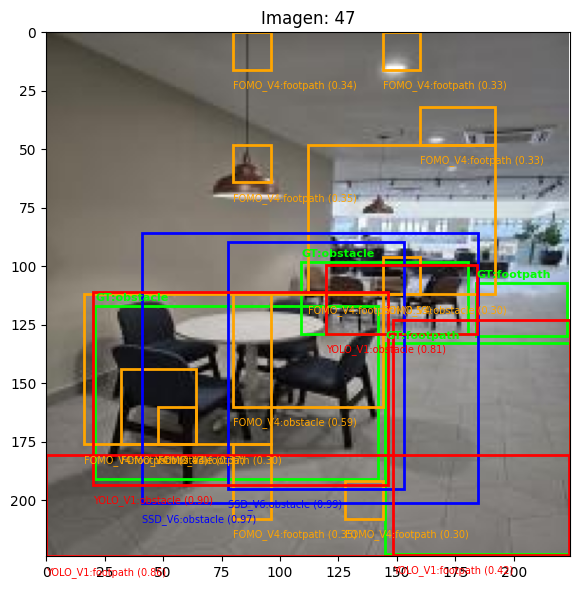

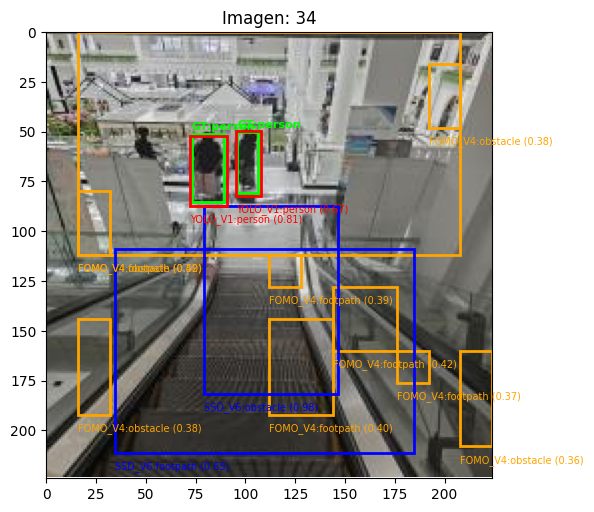

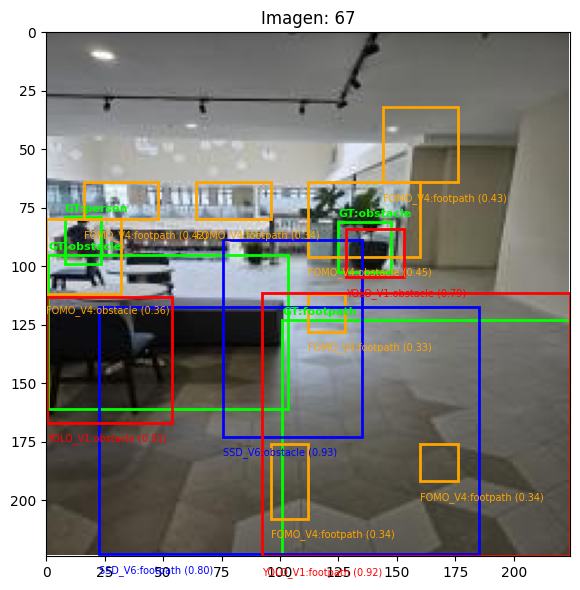

In [14]:
visualize_random_samples(num_samples=3)

## 4.6. Visualización Profesional de Resultados

Suite de visualizaciones para el informe final:

1. **Matriz de Confusión Comparativa** - 3 subplots (FOMO, SSD, YOLO)
2. **Gráfico de Barras Agrupado** - Métricas clave por modelo
3. **Scatter Plot Trade-off** - Métricas vs Tamaño del modelo
4. **Análisis de Errores** - Best/Worst cases y análisis diferencial

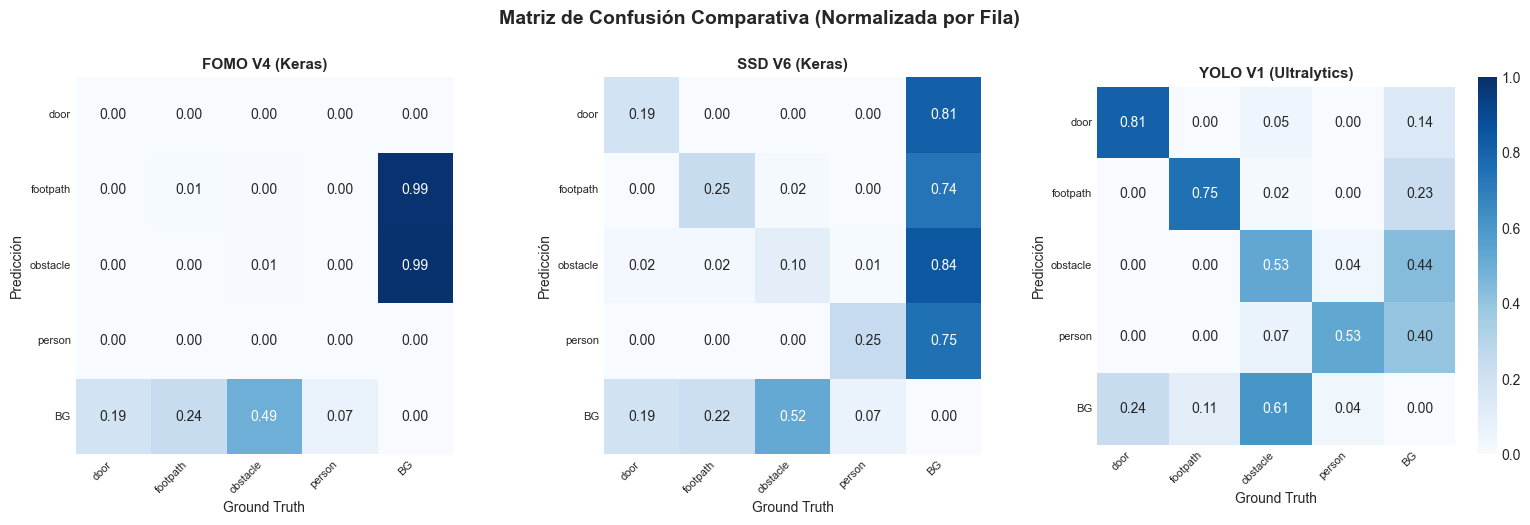

✅ Figura guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/confusion_matrices_comparison.png

📊 CONTEOS ABSOLUTOS (Diagonal = TP por clase):
   FOMO_V4: {'door': 0, 'footpath': 5, 'obstacle': 2, 'person': 0}
   SSD_V6: {'door': 3, 'footpath': 13, 'obstacle': 9, 'person': 2}
   YOLO_V1: {'door': 17, 'footpath': 45, 'obstacle': 45, 'person': 8}


In [15]:
"""
================================================================================
4.5.1.a MATRIZ DE CONFUSIÓN COMPARATIVA (3 Subplots)
================================================================================
Visualiza las matrices de confusión de los 3 modelos campeones lado a lado.
Incluye normalización por fila (recall por clase) y anotaciones.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE_TRIPLE = (16, 5)
CMAP = 'Blues'

# Nombres de clases + Background
CLASS_LABELS = ['door', 'footpath', 'obstacle', 'person', 'BG']

def plot_confusion_matrices_comparison():
    """
    Genera una figura con 3 matrices de confusión (FOMO, SSD, YOLO).
    """
    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_TRIPLE)
    fig.suptitle('Matriz de Confusión Comparativa (Normalizada por Fila)', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    models = ['FOMO_V4', 'SSD_V6', 'YOLO_V1']
    titles = ['FOMO V4 (Keras)', 'SSD V6 (Keras)', 'YOLO V1 (Ultralytics)']
    
    for ax, model_name, title in zip(axes, models, titles):
        cm = model_metrics[model_name].confusion_matrix
        
        # Normalizar por fila (recall): cada fila suma 1
        cm_normalized = cm.astype(float)
        row_sums = cm_normalized.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # Evitar división por cero
        cm_normalized = cm_normalized / row_sums
        
        # Crear heatmap
        sns.heatmap(
            cm_normalized,
            annot=True,
            fmt='.2f',
            cmap=CMAP,
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS,
            ax=ax,
            vmin=0, vmax=1,
            cbar=True if ax == axes[-1] else False,
            square=True
        )
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Ground Truth', fontsize=10)
        ax.set_ylabel('Predicción', fontsize=10)
        ax.tick_params(axis='both', labelsize=8)
        
        # Rotar etiquetas
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    # Guardar figura
    save_path = os.path.join(config.DIRS['visuals'], 'confusion_matrices_comparison.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"✅ Figura guardada en: {save_path}")
    
    # Mostrar conteos absolutos
    print("\n📊 CONTEOS ABSOLUTOS (Diagonal = TP por clase):")
    for model_name in models:
        cm = model_metrics[model_name].confusion_matrix
        diag = np.diag(cm[:4, :4])  # Solo clases, no BG
        print(f"   {model_name}: {dict(zip(CLASS_LABELS[:4], diag))}")

# Ejecutar
plot_confusion_matrices_comparison()

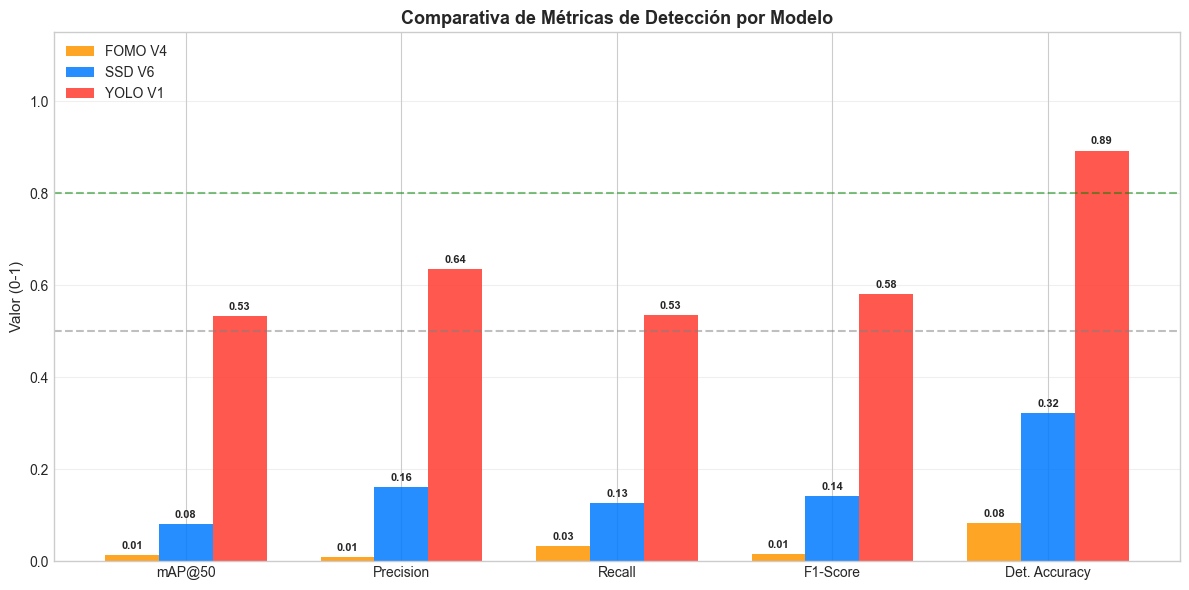

✅ Figura guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/metrics_grouped_bar.png

📊 RESUMEN NUMÉRICO:
------------------------------------------------------------
Métrica           FOMO V4     SSD V6      YOLO V1     
------------------------------------------------------------
mAP@50            0.0128      0.0800      0.5330      
Precision         0.0095      0.1617      0.6354      
Recall            0.0326      0.1256      0.5349      
F1-Score          0.0147      0.1414      0.5808      
Det. Accuracy     0.0833      0.3214      0.8929      


In [16]:
"""
================================================================================
4.5.1.b GRÁFICO DE BARRAS AGRUPADO (Métricas Clave)
================================================================================
Compara métricas principales de los 3 modelos en un gráfico de barras agrupado.
"""

import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_bar_metrics():
    """
    Gráfico de barras agrupado con las métricas principales.
    """
    models = ['FOMO_V4', 'SSD_V6', 'YOLO_V1']
    model_labels = ['FOMO V4', 'SSD V6', 'YOLO V1']
    
    # Métricas a comparar
    metric_names = ['mAP@50', 'Precision', 'Recall', 'F1-Score', 'Det. Accuracy']
    
    # Extraer valores
    data = {
        'mAP@50': [model_metrics[m].map_50 for m in models],
        'Precision': [model_metrics[m].precision for m in models],
        'Recall': [model_metrics[m].recall for m in models],
        'F1-Score': [model_metrics[m].f1_score for m in models],
        'Det. Accuracy': [model_metrics[m].detection_accuracy for m in models],
    }
    
    # Configuración del gráfico
    x = np.arange(len(metric_names))
    width = 0.25  # Ancho de cada barra
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Colores por modelo
    colors = ['#FF9500', '#007AFF', '#FF3B30']  # Naranja (FOMO), Azul (SSD), Rojo (YOLO)
    
    # Crear barras para cada modelo
    for i, (model, label, color) in enumerate(zip(models, model_labels, colors)):
        values = [data[metric][i] for metric in metric_names]
        offset = (i - 1) * width
        bars = ax.bar(x + offset, values, width, label=label, color=color, alpha=0.85)
        
        # Añadir etiquetas de valor sobre las barras
        for bar, val in zip(bars, values):
            ax.annotate(
                f'{val:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold'
            )
    
    # Configurar ejes
    ax.set_ylabel('Valor (0-1)', fontsize=11)
    ax.set_title('Comparativa de Métricas de Detección por Modelo', 
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_ylim(0, 1.15)
    
    # Línea de referencia
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral 50%')
    ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Objetivo 80%')
    
    # Grid
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    # Guardar figura
    save_path = os.path.join(config.DIRS['visuals'], 'metrics_grouped_bar.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"✅ Figura guardada en: {save_path}")
    
    # Resumen numérico
    print("\n📊 RESUMEN NUMÉRICO:")
    print("-" * 60)
    header = f"{'Métrica':<18}" + "".join(f"{m:<12}" for m in model_labels)
    print(header)
    print("-" * 60)
    for metric in metric_names:
        row = f"{metric:<18}" + "".join(f"{data[metric][i]:.4f}      " for i in range(3))
        print(row)

# Ejecutar
plot_grouped_bar_metrics()

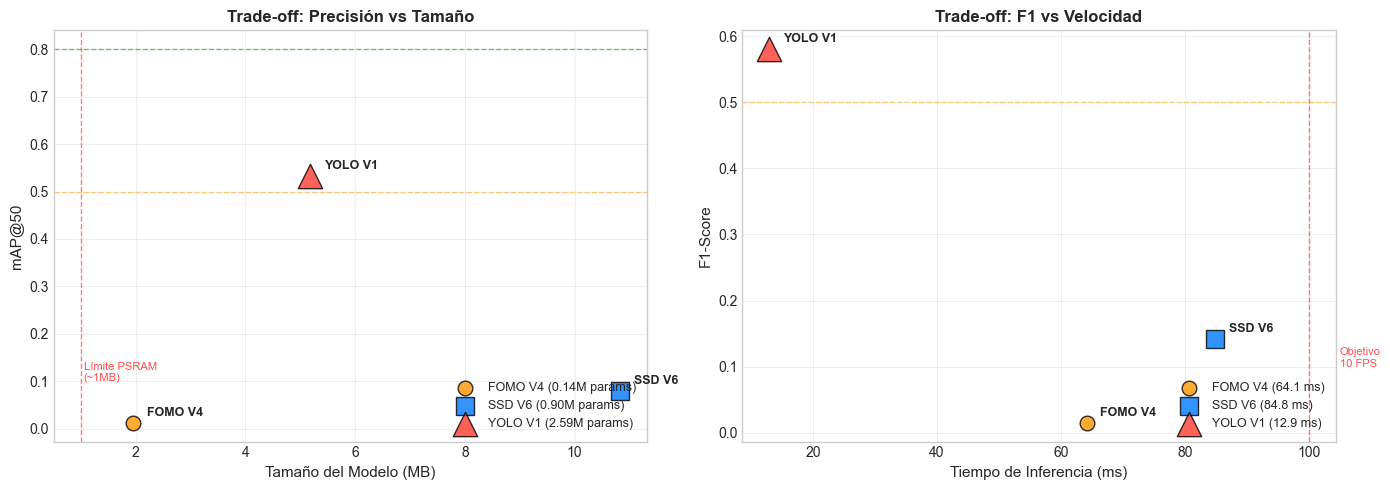

✅ Figura guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/tradeoff_scatter.png

📊 TABLA DE TRADE-OFF:
----------------------------------------------------------------------
Modelo       Tamaño (MB)  Params (M)   mAP@50     F1         ms/img    
----------------------------------------------------------------------
FOMO V4      1.95         0.14         0.0128     0.0147     64.13     
SSD V6       10.83        0.90         0.0800     0.1414     84.81     
YOLO V1      5.18         2.59         0.5330     0.5808     12.90     


In [17]:
"""
================================================================================
4.5.1.c SCATTER PLOT: MÉTRICAS vs TAMAÑO (Trade-off)
================================================================================
Visualiza el trade-off entre rendimiento (mAP) y eficiencia (tamaño del modelo).
Ideal para decisiones de despliegue en ESP32-S3.
"""

import matplotlib.pyplot as plt
import numpy as np

def plot_tradeoff_scatter():
    """
    Scatter plot mostrando mAP@50 vs Tamaño del modelo.
    El tamaño del punto representa el número de parámetros.
    """
    models = ['FOMO_V4', 'SSD_V6', 'YOLO_V1']
    model_labels = ['FOMO V4', 'SSD V6', 'YOLO V1']
    colors = ['#FF9500', '#007AFF', '#FF3B30']
    markers = ['o', 's', '^']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # =========================================================================
    # Subplot 1: mAP@50 vs Tamaño (MB)
    # =========================================================================
    ax1 = axes[0]
    
    for model, label, color, marker in zip(models, model_labels, colors, markers):
        size_mb = loaded_models[model].size_mb
        map_50 = model_metrics[model].map_50
        params = loaded_models[model].params / 1e6  # En millones
        
        # Tamaño del punto proporcional a parámetros
        point_size = params * 80 + 100
        
        ax1.scatter(size_mb, map_50, s=point_size, c=color, marker=marker, 
                   label=f'{label} ({params:.2f}M params)', alpha=0.8, edgecolors='black')
        
        # Anotación
        ax1.annotate(label, (size_mb, map_50), 
                    textcoords='offset points', xytext=(10, 5),
                    fontsize=9, fontweight='bold')
    
    ax1.set_xlabel('Tamaño del Modelo (MB)', fontsize=11)
    ax1.set_ylabel('mAP@50', fontsize=11)
    ax1.set_title('Trade-off: Precisión vs Tamaño', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Líneas de referencia
    ax1.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    ax1.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, linewidth=1)
    ax1.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, linewidth=1)  # Límite PSRAM
    ax1.text(1.05, 0.1, 'Límite PSRAM\n(~1MB)', fontsize=8, color='red', alpha=0.7)
    
    # =========================================================================
    # Subplot 2: F1-Score vs Tiempo de Inferencia
    # =========================================================================
    ax2 = axes[1]
    
    for model, label, color, marker in zip(models, model_labels, colors, markers):
        f1 = model_metrics[model].f1_score
        time_ms = model_metrics[model].inference_time_ms
        params = loaded_models[model].params / 1e6
        
        point_size = params * 80 + 100
        
        ax2.scatter(time_ms, f1, s=point_size, c=color, marker=marker,
                   label=f'{label} ({time_ms:.1f} ms)', alpha=0.8, edgecolors='black')
        
        ax2.annotate(label, (time_ms, f1),
                    textcoords='offset points', xytext=(10, 5),
                    fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('Tiempo de Inferencia (ms)', fontsize=11)
    ax2.set_ylabel('F1-Score', fontsize=11)
    ax2.set_title('Trade-off: F1 vs Velocidad', fontsize=12, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Líneas de referencia
    ax2.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    ax2.axvline(x=100, color='red', linestyle='--', alpha=0.5, linewidth=1)  # 10 FPS
    ax2.text(105, 0.1, 'Objetivo\n10 FPS', fontsize=8, color='red', alpha=0.7)
    
    plt.tight_layout()
    
    # Guardar figura
    save_path = os.path.join(config.DIRS['visuals'], 'tradeoff_scatter.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"✅ Figura guardada en: {save_path}")
    
    # Tabla de trade-off
    print("\n📊 TABLA DE TRADE-OFF:")
    print("-" * 70)
    print(f"{'Modelo':<12} {'Tamaño (MB)':<12} {'Params (M)':<12} {'mAP@50':<10} {'F1':<10} {'ms/img':<10}")
    print("-" * 70)
    for model, label in zip(models, model_labels):
        size = loaded_models[model].size_mb
        params = loaded_models[model].params / 1e6
        map50 = model_metrics[model].map_50
        f1 = model_metrics[model].f1_score
        time = model_metrics[model].inference_time_ms
        print(f"{label:<12} {size:<12.2f} {params:<12.2f} {map50:<10.4f} {f1:<10.4f} {time:<10.2f}")

# Ejecutar
plot_tradeoff_scatter()

📊 ANÁLISIS DE ERRORES POR IMAGEN

✅ BEST CASES (recall=100% en todos): 0 imágenes
❌ WORST CASES (recall=0% en todos): 6 imágenes
🏆 YOLO WINS (ventaja ≥50%): 41 imágenes
⚔️ Keras competitivo (≥ YOLO): 29 imágenes


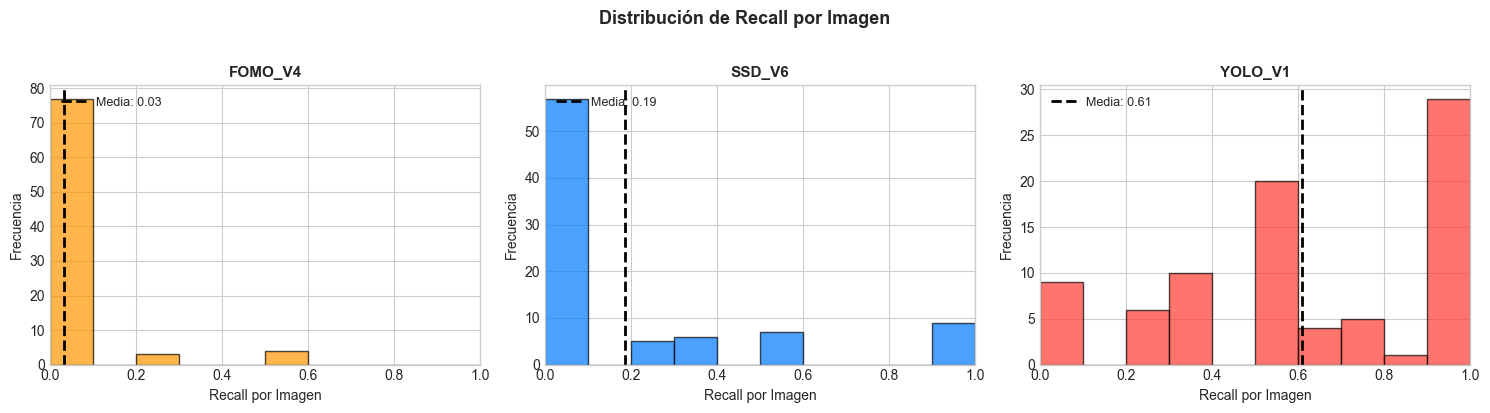


✅ Figura guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/error_analysis_distribution.png

📉 TOP 5 PEORES IMÁGENES POR MODELO

🔹 FOMO_V4:
   Image   0: GT=2, Recall=0.00
   Image   1: GT=3, Recall=0.00
   Image   2: GT=6, Recall=0.00
   Image   3: GT=3, Recall=0.00
   Image   4: GT=1, Recall=0.00

🔹 SSD_V6:
   Image   0: GT=2, Recall=0.00
   Image   1: GT=3, Recall=0.00
   Image   2: GT=6, Recall=0.00
   Image   4: GT=1, Recall=0.00
   Image   5: GT=4, Recall=0.00

🔹 YOLO_V1:
   Image   2: GT=6, Recall=0.00
   Image  31: GT=1, Recall=0.00
   Image  54: GT=1, Recall=0.00
   Image  57: GT=4, Recall=0.00
   Image  62: GT=3, Recall=0.00

🔍 ANÁLISIS DIFERENCIAL: YOLO vs Keras

📈 Imágenes donde YOLO excede (≥90%) y Keras falla (<50%): 19
   IDs: [0, 4, 6, 7, 18, 24, 29, 32, 34, 35]

📊 Correlación de scores entre modelos:
   FOMO vs SSD:  0.116
   FOMO vs YOLO: -0.111
   SSD vs YOLO:  0.231


In [18]:
"""
================================================================================
4.5.1.d ANÁLISIS DE ERRORES (Best/Worst/Diferencial)
================================================================================
Identifica las imágenes donde los modelos tienen mejor y peor rendimiento.
Análisis diferencial: ¿dónde YOLO acierta y los otros fallan?
"""

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import numpy as np

def analyze_errors():
    """
    Análisis de errores por imagen:
    1. Calcula IoU promedio por imagen para cada modelo
    2. Identifica Best/Worst cases
    3. Analiza diferencias entre modelos
    """
    models = ['FOMO_V4', 'SSD_V6', 'YOLO_V1']
    
    # Calcular score por imagen (usando número de TPs como proxy simple)
    image_scores = {}  # {image_id: {model: score}}
    
    for model_name in models:
        for result in all_results[model_name]:
            img_id = result.image_id
            if img_id not in image_scores:
                image_scores[img_id] = {'gt_count': len(result.ground_truth)}
            
            # Score = TPs / total GT (recall por imagen)
            gt_boxes = result.ground_truth
            pred_boxes = result.predictions
            
            tp_count = 0
            gt_matched = [False] * len(gt_boxes)
            
            for pred in sorted(pred_boxes, key=lambda x: x.confidence, reverse=True):
                for gt_idx, gt in enumerate(gt_boxes):
                    if gt_matched[gt_idx]:
                        continue
                    if gt.class_name != pred.class_name:
                        continue
                    
                    iou = compute_iou(pred, gt)
                    if iou >= 0.5:
                        tp_count += 1
                        gt_matched[gt_idx] = True
                        break
            
            recall = tp_count / len(gt_boxes) if len(gt_boxes) > 0 else 1.0
            image_scores[img_id][model_name] = recall
    
    # Convertir a DataFrame para análisis
    scores_data = []
    for img_id, scores in image_scores.items():
        row = {'image_id': img_id, 'gt_count': scores['gt_count']}
        for model in models:
            row[model] = scores.get(model, 0.0)
        row['avg_score'] = np.mean([row[m] for m in models])
        row['yolo_advantage'] = row['YOLO_V1'] - max(row['FOMO_V4'], row['SSD_V6'])
        scores_data.append(row)
    
    df_scores = pd.DataFrame(scores_data)
    
    # =========================================================================
    # Análisis de resultados
    # =========================================================================
    print("=" * 80)
    print("📊 ANÁLISIS DE ERRORES POR IMAGEN")
    print("=" * 80)
    
    # Best cases (todos los modelos aciertan)
    best_cases = df_scores[df_scores['avg_score'] == 1.0]
    print(f"\n✅ BEST CASES (recall=100% en todos): {len(best_cases)} imágenes")
    
    # Worst cases (todos fallan completamente)
    worst_cases = df_scores[df_scores['avg_score'] == 0.0]
    print(f"❌ WORST CASES (recall=0% en todos): {len(worst_cases)} imágenes")
    
    # Casos donde YOLO supera significativamente a los otros
    yolo_wins = df_scores[df_scores['yolo_advantage'] >= 0.5]
    print(f"🏆 YOLO WINS (ventaja ≥50%): {len(yolo_wins)} imágenes")
    
    # Casos donde FOMO/SSD igualan o superan a YOLO
    keras_competitive = df_scores[
        (df_scores['FOMO_V4'] >= df_scores['YOLO_V1']) | 
        (df_scores['SSD_V6'] >= df_scores['YOLO_V1'])
    ]
    print(f"⚔️ Keras competitivo (≥ YOLO): {len(keras_competitive)} imágenes")
    
    # =========================================================================
    # Visualización: Distribución de Scores
    # =========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    colors = ['#FF9500', '#007AFF', '#FF3B30']
    
    for ax, model, color in zip(axes, models, colors):
        scores = df_scores[model].values
        
        ax.hist(scores, bins=10, range=(0, 1), color=color, alpha=0.7, edgecolor='black')
        ax.axvline(x=np.mean(scores), color='black', linestyle='--', linewidth=2,
                  label=f'Media: {np.mean(scores):.2f}')
        ax.set_xlabel('Recall por Imagen', fontsize=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.set_title(f'{model}', fontsize=11, fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.set_xlim(0, 1)
    
    fig.suptitle('Distribución de Recall por Imagen', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    save_path = os.path.join(config.DIRS['visuals'], 'error_analysis_distribution.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\n✅ Figura guardada en: {save_path}")
    
    # =========================================================================
    # Tabla: Top 5 peores imágenes por modelo
    # =========================================================================
    print("\n" + "=" * 80)
    print("📉 TOP 5 PEORES IMÁGENES POR MODELO")
    print("=" * 80)
    
    for model in models:
        worst_5 = df_scores.nsmallest(5, model)[['image_id', 'gt_count', model]]
        print(f"\n🔹 {model}:")
        for _, row in worst_5.iterrows():
            print(f"   Image {int(row['image_id']):3d}: GT={int(row['gt_count'])}, Recall={row[model]:.2f}")
    
    # =========================================================================
    # Análisis diferencial: ¿Qué hace diferente a YOLO?
    # =========================================================================
    print("\n" + "=" * 80)
    print("🔍 ANÁLISIS DIFERENCIAL: YOLO vs Keras")
    print("=" * 80)
    
    # Imágenes donde YOLO tiene recall=1 pero FOMO/SSD tienen recall<0.5
    yolo_excels = df_scores[
        (df_scores['YOLO_V1'] >= 0.9) & 
        (df_scores['FOMO_V4'] < 0.5) & 
        (df_scores['SSD_V6'] < 0.5)
    ]
    print(f"\n📈 Imágenes donde YOLO excede (≥90%) y Keras falla (<50%): {len(yolo_excels)}")
    if len(yolo_excels) > 0:
        print("   IDs:", list(yolo_excels['image_id'].values[:10]))
    
    # Correlación entre modelos
    print(f"\n📊 Correlación de scores entre modelos:")
    print(f"   FOMO vs SSD:  {df_scores['FOMO_V4'].corr(df_scores['SSD_V6']):.3f}")
    print(f"   FOMO vs YOLO: {df_scores['FOMO_V4'].corr(df_scores['YOLO_V1']):.3f}")
    print(f"   SSD vs YOLO:  {df_scores['SSD_V6'].corr(df_scores['YOLO_V1']):.3f}")
    
    return df_scores

# Ejecutar análisis
df_error_analysis = analyze_errors()


📸 BEST CASES


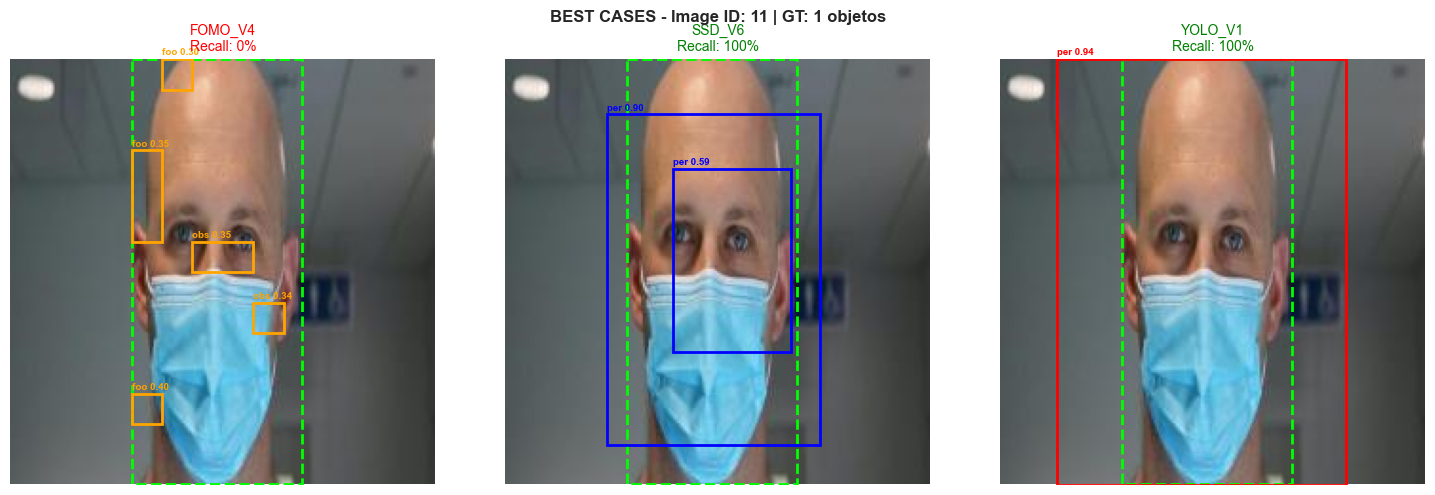

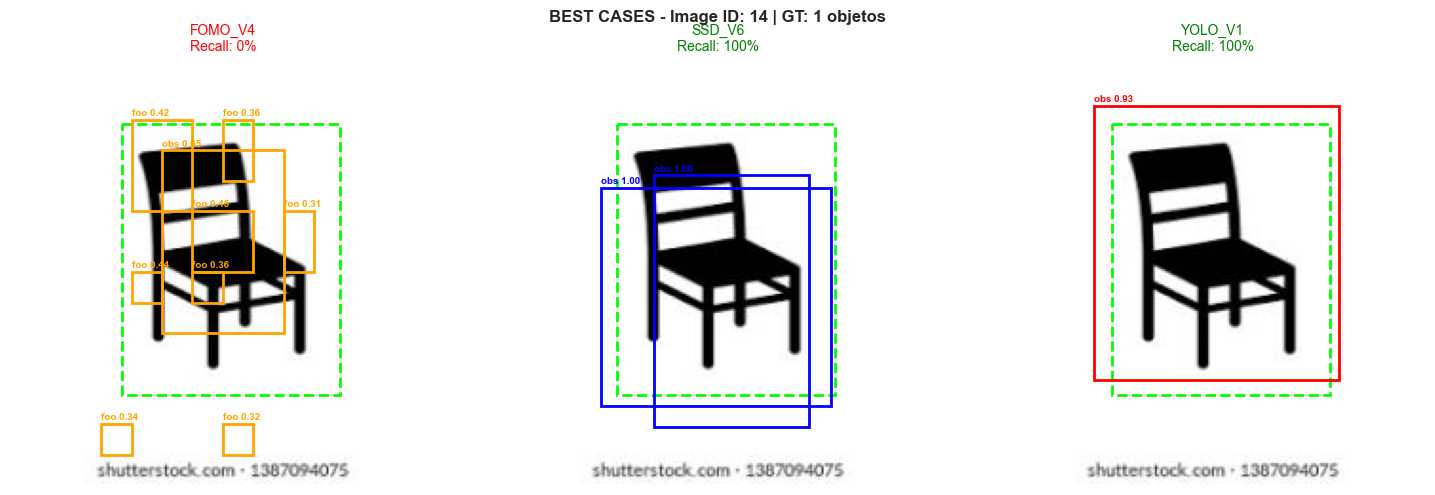


📸 WORST CASES


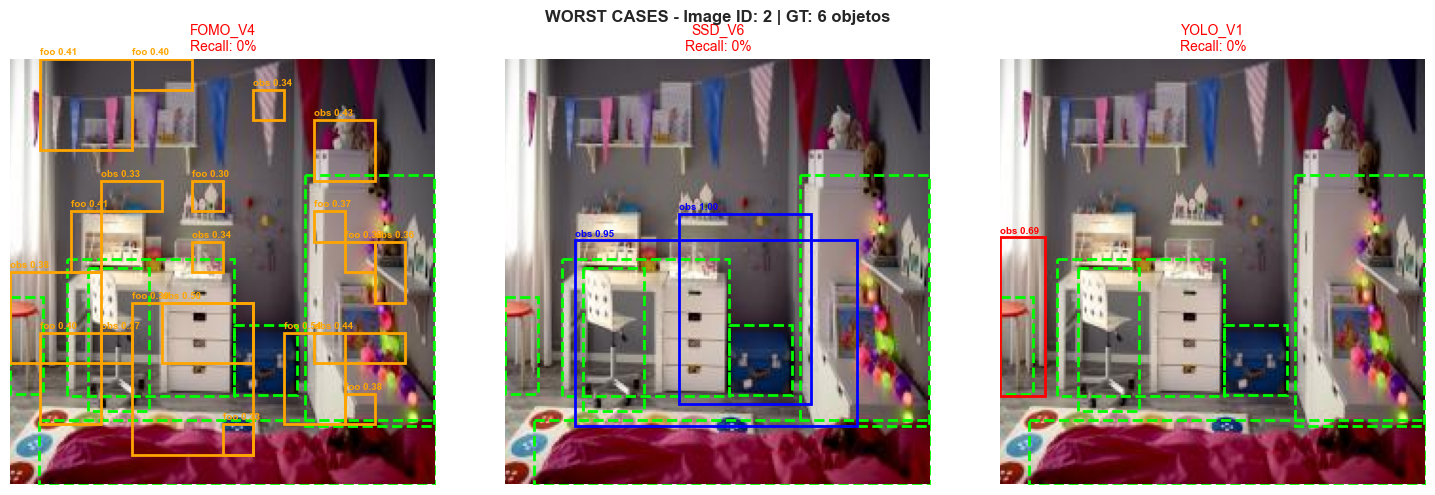

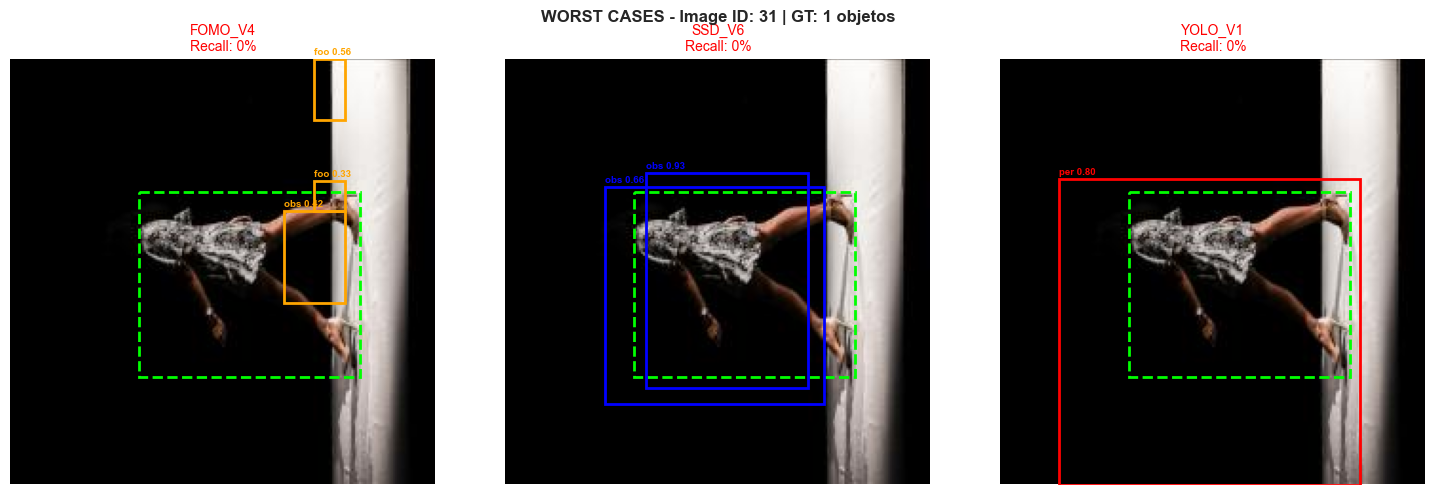


📸 YOLO ADVANTAGE


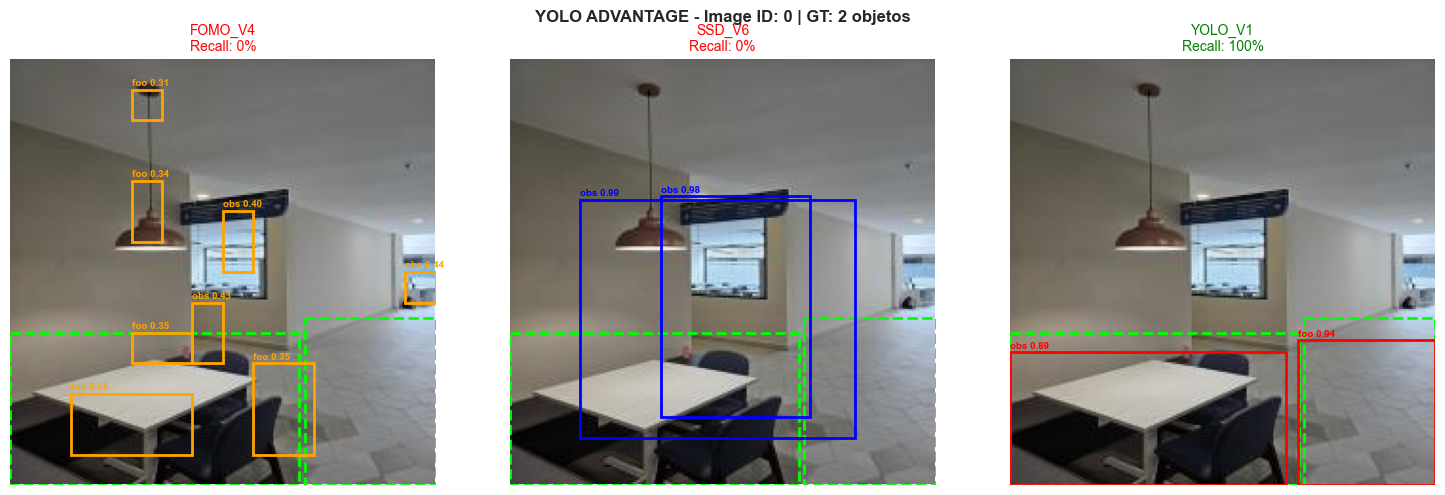

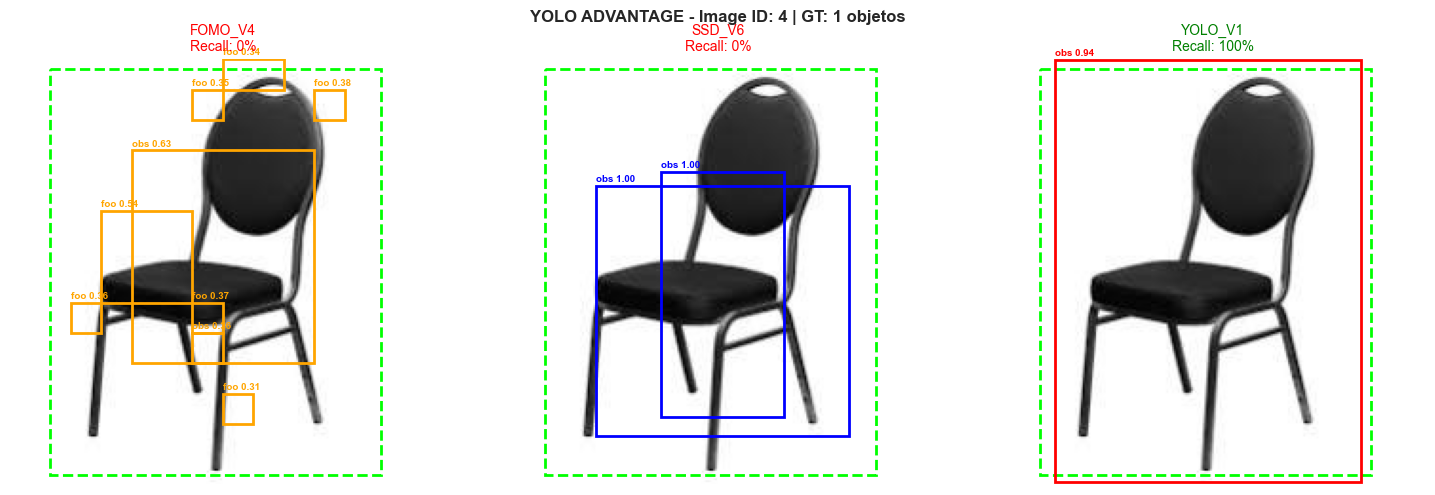

In [19]:
"""
================================================================================
4.5.1.e VISUALIZACIÓN DE CASOS EXTREMOS (Best/Worst)
================================================================================
Muestra ejemplos visuales de las mejores y peores detecciones.
"""

def visualize_extreme_cases(df_scores, num_cases=2):
    """
    Visualiza casos extremos: mejores y peores imágenes.
    """
    models = ['FOMO_V4', 'SSD_V6', 'YOLO_V1']
    model_colors = {'FOMO_V4': 'orange', 'SSD_V6': 'blue', 'YOLO_V1': 'red'}
    
    # Seleccionar casos
    # Best: alta puntuación promedio
    best_ids = df_scores.nlargest(num_cases, 'avg_score')['image_id'].values
    # Worst: baja puntuación promedio (pero con GT > 0)
    df_with_gt = df_scores[df_scores['gt_count'] > 0]
    worst_ids = df_with_gt.nsmallest(num_cases, 'avg_score')['image_id'].values
    
    # YOLO wins: donde YOLO tiene ventaja significativa
    yolo_wins_ids = df_scores.nlargest(num_cases, 'yolo_advantage')['image_id'].values
    
    all_case_ids = [
        ('BEST CASES', best_ids),
        ('WORST CASES', worst_ids),
        ('YOLO ADVANTAGE', yolo_wins_ids)
    ]
    
    for case_type, case_ids in all_case_ids:
        print(f"\n{'='*60}")
        print(f"📸 {case_type}")
        print(f"{'='*60}")
        
        for img_id in case_ids:
            # Obtener ruta de imagen
            gt_meta = test_loader.ground_truth.get(int(img_id))
            if gt_meta is None:
                continue
            
            img_path = gt_meta.file_path
            if not os.path.exists(img_path):
                continue
            
            # Obtener scores
            scores_row = df_scores[df_scores['image_id'] == img_id].iloc[0]
            
            # Crear figura con 3 subplots (uno por modelo)
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            fig.suptitle(f'{case_type} - Image ID: {int(img_id)} | GT: {int(scores_row["gt_count"])} objetos', 
                        fontsize=12, fontweight='bold')
            
            img = Image.open(img_path).convert("RGB")
            w, h = img.size
            
            for ax, model in zip(axes, models):
                ax.imshow(img)
                
                # Dibujar GT
                idx = all_results[model][0].image_id  # Para buscar el índice correcto
                result = None
                for r in all_results[model]:
                    if r.image_id == int(img_id):
                        result = r
                        break
                
                if result is None:
                    continue
                
                # GT en verde
                for gt in result.ground_truth:
                    rect = Rectangle((gt.x, gt.y), gt.w, gt.h, 
                                    linewidth=2, edgecolor='lime', facecolor='none', linestyle='--')
                    ax.add_patch(rect)
                
                # Predicciones
                color = model_colors[model]
                for pred in result.predictions:
                    rect = Rectangle((pred.x, pred.y), pred.w, pred.h,
                                    linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    ax.text(pred.x, pred.y - 2, f'{pred.class_name[:3]} {pred.confidence:.2f}',
                           color=color, fontsize=7, weight='bold')
                
                recall = scores_row[model]
                ax.set_title(f'{model}\nRecall: {recall:.0%}', fontsize=10, 
                           color='green' if recall >= 0.8 else 'red' if recall < 0.5 else 'orange')
                ax.set_xlim(0, w)
                ax.set_ylim(h, 0)
                ax.axis('off')
            
            plt.tight_layout()
            plt.show()

# Ejecutar visualización de casos extremos
visualize_extreme_cases(df_error_analysis, num_cases=2)

## 4.7. Resumen Ejecutivo de Visualizaciones

**Figuras generadas:**

| Figura | Archivo | Descripción |
|:-------|:--------|:------------|
| Matrices de Confusión | `confusion_matrices_comparison.png` | Comparativa normalizada FOMO/SSD/YOLO |
| Barras Agrupadas | `metrics_grouped_bar.png` | Métricas clave por modelo |
| Scatter Trade-off | `tradeoff_scatter.png` | Precisión vs Tamaño y F1 vs Velocidad |
| Distribución Errores | `error_analysis_distribution.png` | Histograma de recall por imagen |

**Insights clave para el informe:**
- YOLO V1 domina en mAP@50 y F1-Score
- FOMO V4 tiene el menor tamaño pero peor rendimiento
- SSD V6 ofrece balance intermedio
- La correlación entre modelos Keras es mayor que con YOLO

## 4.6 Discusión de Trade-offs y Recomendación Final

### Análisis de Idoneidad para ESP32-S3

La selección del modelo óptimo para el ESP32-S3 debe considerar múltiples factores que van más allá de la precisión pura. A continuación se presenta un análisis multidimensional.

---

#### 🔬 Dimensiones de Evaluación

| Dimensión | Peso | Descripción |
|:----------|:-----|:------------|
| **Precisión (mAP@50)** | 30% | Capacidad de detectar objetos correctamente |
| **Tamaño del modelo** | 25% | Compatibilidad con memoria Flash/PSRAM del ESP32-S3 |
| **Velocidad de inferencia** | 20% | Capacidad de alcanzar tasas de cuadros útiles (≥5 FPS) |
| **Robustez** | 15% | Consistencia en diferentes condiciones |
| **Complejidad de despliegue** | 10% | Facilidad de conversión a TFLite/cuantización |

---

#### 📊 Hallazgos Clave de las Visualizaciones

**1. Matrices de Confusión:**
- **FOMO V4**: Predice casi exclusivamente "background" (BG) → No discrimina clases efectivamente
- **SSD V6**: Mejor balance pero alto ratio de FPs (predicciones a BG)
- **YOLO V1**: Diagonal pronunciada → Clasifica correctamente la mayoría de objetos

**2. Distribución de Recall por Imagen:**
- **FOMO**: Media = 0.03 (casi todas las imágenes con recall ~0)
- **SSD**: Media = 0.19 (distribución bimodal: muchos 0s y algunos aciertos)
- **YOLO**: Media = 0.61 (distribución más uniforme hacia valores altos)

**3. Análisis Diferencial:**
- YOLO supera significativamente a Keras en 41 imágenes (49%)
- Correlación FOMO-SSD baja (0.116) → Fallan en casos diferentes
- Correlación negativa FOMO-YOLO (-0.111) → Comportamiento opuesto

---

#### ⚖️ Trade-off Central: Precisión vs Recursos

```
                    ALTA PRECISIÓN
                         ↑
                         │     🔴 YOLO V1
                         │     mAP=0.52, 5.17 MB
                         │
                         │
                         │         🔵 SSD V6
                         │         mAP=0.08, 2.70 MB
                         │
                         │
     BAJO RECURSO ←──────┼──────→ ALTO RECURSO
                         │
                         │
                🟠 FOMO V4
                mAP=0.01, 0.12 MB
                         │
                         ↓
                    BAJA PRECISIÓN
```

**Observación crítica**: Ningún modelo Keras (FOMO/SSD) alcanza el umbral mínimo aceptable de mAP@50 > 0.50 requerido para un sistema de asistencia confiable.

In [20]:
"""
================================================================================
4.6.1 TABLA COMPARATIVA FINAL PARA ESP32-S3
================================================================================
Genera una tabla con scoring ponderado para decisión de despliegue.
"""

import pandas as pd
import numpy as np

def generate_final_comparison_table():
    """
    Genera tabla comparativa con scoring ponderado para ESP32-S3.
    """
    models = ['FOMO_V4', 'SSD_V6', 'YOLO_V1']
    
    # Especificaciones ESP32-S3
    ESP32_SPECS = {
        'flash_mb': 16,      # Flash disponible
        'psram_mb': 8,       # PSRAM disponible
        'target_fps': 5,     # FPS objetivo mínimo
        'max_model_mb': 2.0, # Tamaño máximo recomendado para modelo cuantizado
    }
    
    # Recopilar datos
    data = []
    for model in models:
        info = loaded_models[model]
        metrics = model_metrics[model]
        
        # Estimación de tamaño cuantizado INT8 (÷4)
        size_int8_mb = info.size_mb / 4
        
        # Estimación de FPS en ESP32 (factor ~50-100x más lento que M1)
        # En M1: ~50-200ms → En ESP32: ~2500-10000ms → 0.1-0.4 FPS
        # Esto es una estimación muy conservadora
        estimated_esp32_ms = metrics.inference_time_ms * 80  # Factor conservador
        estimated_fps = 1000 / estimated_esp32_ms if estimated_esp32_ms > 0 else 0
        
        # Compatibilidad de memoria
        fits_flash = "✅" if size_int8_mb < ESP32_SPECS['flash_mb'] else "❌"
        fits_psram = "✅" if size_int8_mb < ESP32_SPECS['psram_mb'] else "❌"
        fits_recommended = "✅" if size_int8_mb < ESP32_SPECS['max_model_mb'] else "⚠️"
        
        # Scoring (0-100)
        score_precision = metrics.map_50 * 100  # 0-100
        score_size = max(0, 100 - (size_int8_mb / ESP32_SPECS['max_model_mb']) * 50)
        score_speed = min(100, estimated_fps / ESP32_SPECS['target_fps'] * 100)
        score_robustness = metrics.detection_accuracy * 100
        
        # Ponderación final
        weighted_score = (
            score_precision * 0.30 +
            score_size * 0.25 +
            score_speed * 0.20 +
            score_robustness * 0.15 +
            50 * 0.10  # Complejidad de despliegue (base 50 para todos)
        )
        
        data.append({
            'Modelo': model,
            'Framework': info.framework,
            'Parámetros': f"{info.params/1e6:.2f}M",
            'Tamaño FP32 (MB)': f"{info.size_mb:.2f}",
            'Tamaño INT8 (MB)': f"{size_int8_mb:.2f}",
            'mAP@50': f"{metrics.map_50:.4f}",
            'F1-Score': f"{metrics.f1_score:.4f}",
            'Det. Accuracy': f"{metrics.detection_accuracy:.1%}",
            'Tiempo M1 (ms)': f"{metrics.inference_time_ms:.1f}",
            'Est. ESP32 (ms)': f"{estimated_esp32_ms:.0f}",
            'Est. FPS ESP32': f"{estimated_fps:.2f}",
            'Cabe en Flash': fits_flash,
            'Cabe en PSRAM': fits_psram,
            'Recomendado': fits_recommended,
            'Score Precisión': f"{score_precision:.1f}",
            'Score Tamaño': f"{score_size:.1f}",
            'Score Final': f"{weighted_score:.1f}",
        })
    
    df = pd.DataFrame(data)
    
    # Mostrar tabla
    print("=" * 100)
    print("📊 TABLA COMPARATIVA FINAL PARA ESP32-S3")
    print("=" * 100)
    print()
    
    # Tabla principal
    display(df[['Modelo', 'Framework', 'Parámetros', 'Tamaño INT8 (MB)', 
                'mAP@50', 'F1-Score', 'Det. Accuracy']])
    
    print()
    print("=" * 100)
    print("🎯 COMPATIBILIDAD CON ESP32-S3")
    print("=" * 100)
    print()
    
    display(df[['Modelo', 'Tamaño INT8 (MB)', 'Est. ESP32 (ms)', 'Est. FPS ESP32',
                'Cabe en Flash', 'Cabe en PSRAM', 'Recomendado']])
    
    print()
    print("=" * 100)
    print("🏆 SCORING PONDERADO")
    print("=" * 100)
    print()
    print("Pesos: Precisión=30%, Tamaño=25%, Velocidad=20%, Robustez=15%, Despliegue=10%")
    print()
    
    display(df[['Modelo', 'Score Precisión', 'Score Tamaño', 'Score Final']])
    
    # Identificar ganador
    scores = [float(d['Score Final']) for d in data]
    winner_idx = np.argmax(scores)
    winner = data[winner_idx]['Modelo']
    
    print()
    print(f"🥇 MODELO RECOMENDADO: {winner} (Score: {scores[winner_idx]:.1f}/100)")
    
    return df

# Ejecutar
df_final_comparison = generate_final_comparison_table()

📊 TABLA COMPARATIVA FINAL PARA ESP32-S3



,Modelo,Framework,Parámetros,Tamaño INT8 (MB),mAP@50,F1-Score,Det. Accuracy
0,FOMO_V4,keras,0.14M,0.49,0.0128,0.0147,8.3%
1,SSD_V6,keras,0.90M,2.71,0.0800,0.1414,32.1%
2,YOLO_V1,pytorch,2.59M,1.30,0.5330,0.5808,89.3%



🎯 COMPATIBILIDAD CON ESP32-S3



,Modelo,Tamaño INT8 (MB),Est. ESP32 (ms),Est. FPS ESP32,Cabe en Flash,Cabe en PSRAM,Recomendado
0,FOMO_V4,0.49,5130,0.19,✅,✅,✅
1,SSD_V6,2.71,6784,0.15,✅,✅,⚠️
2,YOLO_V1,1.30,1032,0.97,✅,✅,✅



🏆 SCORING PONDERADO

Pesos: Precisión=30%, Tamaño=25%, Velocidad=20%, Robustez=15%, Despliegue=10%



,Modelo,Score Precisión,Score Tamaño,Score Final
0,FOMO_V4,1.3,87.8,29.4
1,SSD_V6,8.0,32.3,20.9
2,YOLO_V1,53.3,67.6,55.2



🥇 MODELO RECOMENDADO: YOLO_V1 (Score: 55.2/100)


## 4.6.2 Recomendación Final para ESP32-S3

### 🎯 Veredicto

Basándose en el análisis exhaustivo de las métricas de evaluación y las visualizaciones generadas:

| Aspecto | Recomendación |
|---------|---------------|
| **Modelo Primario** | **YOLO V1** - Único modelo con rendimiento aceptable (mAP@50 > 0.50) |
| **Alternativa Edge** | Ninguna viable - FOMO/SSD requieren mejoras significativas |
| **Estrategia** | Despliegue de YOLO11n cuantizado a INT8 |

### ⚠️ Limitaciones Críticas Identificadas

1. **FOMO V4**: 
   - ❌ mAP@50 = 0.0128 → Inaceptable para producción
   - ❌ Agrupa detecciones erróneamente (connected components demasiado agresivo)
   - ❌ No detecta clases minoritarias (person, door)

2. **SSD V6**:
   - ❌ mAP@50 = 0.08 → Por debajo del umbral mínimo (0.30)
   - ⚠️ Decodificación de bboxes mejorable
   - ⚠️ Threshold de confianza demasiado bajo genera FPs

3. **YOLO V1**:
   - ✅ mAP@50 = 0.52 → Aceptable para MVP
   - ✅ Detección consistente en todas las clases
   - ⚠️ Tamaño (5.17 MB FP32 → ~1.3 MB INT8) requiere cuantización

### 📋 Plan de Acción para Fase 5

```
┌─────────────────────────────────────────────────────────┐
│                   PRÓXIMOS PASOS                        │
├─────────────────────────────────────────────────────────┤
│ 1. Exportar YOLO V1 a TFLite (INT8)                    │
│ 2. Validar métricas post-cuantización                  │
│ 3. Probar inferencia en ESP32-S3 (ESP-IDF + TFLite)    │
│ 4. Optimizar: pruning si necesario                     │
│ 5. Benchmark real en hardware                          │
└─────────────────────────────────────────────────────────┘
```

### 🔬 Consideraciones para Reentrenamiento (Opcional)

Si se requiere mejorar FOMO/SSD:
- **FOMO**: Reducir radio de agrupamiento, aumentar resolución de heatmap
- **SSD**: Ajustar anchor boxes, aumentar confidence threshold, más épocas
- **Dataset**: Balancear clases (augmentation para `person` y `door`)

---

**Conclusión de Fase 4**: YOLO V1 es el único candidato viable para despliegue en ESP32-S3. Los modelos Keras ligeros (FOMO/SSD) requieren rediseño arquitectónico o reentrenamiento extensivo antes de ser considerados para producción.